# 2006-2015 variable preparation + Nowcasting Model



# Stage 1: 变量准备

本 notebook 负责构造扩展变量候选面板、训练窗口诊断、缩尾、季节性检验、去季节性变量扩展、相关性检查和标准化训练输入。PCA 初始化和模型估计在第二阶段模型操作 notebook 中运行。


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data").exists() and (candidate / "outputs").exists():
        PROJECT_ROOT = candidate
        break

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed" / "processed"
OUTPUT_DIR = PROCESSED_DIR
INTERMEDIATE_DIR = PROJECT_ROOT / "outputs" / "pipeline_artifacts"
RAW_MACRO_DATA_PATH = OUTPUT_DIR / "宏观变量&GDP raw data.csv"
DATA_PATH = PROCESSED_DIR / "baseline_model_input.csv"
RATE_DATA_PATH = RAW_DATA_DIR / ("1980" + "\u5e74\u81f3\u4eca\u6570\u636e") / "\u5229\u7387\u76f8\u5173\u6570\u636e.csv"
STANDARDIZED_OUTPUT_PATH = None
STANDARDIZATION_PARAMS_OUTPUT_PATH = None
PREPARED_MODEL_PANEL_PATH = None
PREP_META_PATH = None

SAVE_DIAGNOSTIC_OUTPUTS = False
SAVE_KEY_PLOTS = False

TIME_COL = "month"

RAW_GDP_COL = "中国:GDP:不变价:当季值同比"
RAW_WIND_GDP_COL = "万得一致预测:中国:GDP:不变价:当季同比"
RAW_PMI_MFG_LEVEL_COL = "中国:制造业PMI"
RAW_PMI_SVC_LEVEL_COL = "中国:非制造业PMI:服务业"
RAW_PMI_MFG_DIFF_COL = "中国:制造业PMI:一阶差分"
RAW_PMI_SVC_DIFF_COL = "中国:非制造业PMI:服务业:一阶差分"
RAW_FAI_CUM_YOY_COL = "中国:固定资产投资完成额:累计同比"
RAW_RATE_REPO_7D_COL = "逆回购利率:7天"
RAW_RATE_IBO7_COL = "银行间质押式回购加权利率:7天"
RAW_RATE_REPO_7D_MONTHLY_COL = "中国:逆回购利率:7天:当月19日值"
RAW_RATE_IBO7_MONTHLY_COL = "中国:银行间质押式回购加权利率:7天:上月20日至当月19日均值"
RAW_RATE_MONTHLY_COLS = [
    RAW_RATE_REPO_7D_MONTHLY_COL,
    RAW_RATE_IBO7_MONTHLY_COL,
]

RAW_MODEL_COLS = [
    "中国:GDP:不变价:当季值同比",
    "中国:制造业PMI",
    "中国:制造业PMI:一阶差分",
    "中国:非制造业PMI:服务业",
    "中国:非制造业PMI:服务业:一阶差分",
    "中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分)",
    "中国:全社会用电量:当月同比",
    "中国:社会消费品零售总额:当月同比(1-2月合并)",
    "中国:固定资产投资完成额:累计同比",
    "中国:固定资产投资完成额:固投当月同比",
    "中国:CPI:当月同比",
    "中国:PPI:当月同比",
    "中国:城镇调查失业率:一阶差分",
    RAW_RATE_REPO_7D_MONTHLY_COL,
    RAW_RATE_IBO7_MONTHLY_COL,
]

MODEL_COL_ALIASES = {
    "中国:GDP:不变价:当季值同比": "GDP同比",
    "中国:制造业PMI": "制造业PMI",
    "中国:制造业PMI:一阶差分": "制造业PMI一阶差分",
    "中国:非制造业PMI:服务业": "服务业PMI",
    "中国:非制造业PMI:服务业:一阶差分": "服务业PMI一阶差分",
    "中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分)": "工业增加值",
    "中国:全社会用电量:当月同比": "用电量",
    "中国:社会消费品零售总额:当月同比(1-2月合并)": "社零",
    RAW_FAI_CUM_YOY_COL: "固投累计同比",
    "中国:固定资产投资完成额:固投当月同比": "固投当月同比",
    "中国:CPI:当月同比": "CPI",
    "中国:PPI:当月同比": "PPI",
    "中国:城镇调查失业率:一阶差分": "失业率差分",
    RAW_RATE_REPO_7D_MONTHLY_COL: "逆回购7天(19日)",
    RAW_RATE_IBO7_MONTHLY_COL: "银行间7天回购(20-19均值)",
}

GDP_COL = MODEL_COL_ALIASES[RAW_GDP_COL]
WIND_GDP_COL = "WindGDP预测"
MODEL_COLS = [MODEL_COL_ALIASES[col] for col in RAW_MODEL_COLS]
BASE_MODEL_COLS = MODEL_COLS.copy()
RAW_TO_ALIAS = {**MODEL_COL_ALIASES, RAW_WIND_GDP_COL: WIND_GDP_COL}
ALIAS_TO_RAW = {alias: raw_name for raw_name, alias in RAW_TO_ALIAS.items()}

variable_name_map = pd.DataFrame({
    "raw_name": list(RAW_TO_ALIAS.keys()),
    "alias": list(RAW_TO_ALIAS.values()),
})

DATA_PATH


WindowsPath('E:/财遇见你/大四/申万实习/动态因子模型 git/data/processed/processed/baseline_model_input.csv')

## 1. 读取模型输入数据


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Cannot find baseline input file: {DATA_PATH}")
if not RAW_MACRO_DATA_PATH.exists():
    raise FileNotFoundError(f"Cannot find raw macro panel file: {RAW_MACRO_DATA_PATH}")

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# The PMI columns in baseline_model_input.csv currently store first differences.
# Copy them into explicit diff columns, then replace the level columns from the raw macro panel.
PMI_LEVEL_TO_DIFF_RAW = {
    RAW_PMI_MFG_LEVEL_COL: RAW_PMI_MFG_DIFF_COL,
    RAW_PMI_SVC_LEVEL_COL: RAW_PMI_SVC_DIFF_COL,
}
for level_col, diff_col in PMI_LEVEL_TO_DIFF_RAW.items():
    if level_col in raw.columns and diff_col not in raw.columns:
        raw[diff_col] = raw[level_col]

RAW_PMI_LEVEL_COLS = [RAW_PMI_MFG_LEVEL_COL, RAW_PMI_SVC_LEVEL_COL]
RAW_FAI_COL = "中国:固定资产投资完成额:固投当月同比"
RAW_MACRO_MERGE_COLS = RAW_PMI_LEVEL_COLS + [RAW_FAI_CUM_YOY_COL, RAW_FAI_COL]
raw_macro_panel = pd.read_csv(
    RAW_MACRO_DATA_PATH,
    usecols=[TIME_COL] + RAW_MACRO_MERGE_COLS,
    encoding="utf-8-sig",
)
raw_macro_panel[TIME_COL] = pd.PeriodIndex(raw_macro_panel[TIME_COL], freq="M")
raw_macro_panel = raw_macro_panel.sort_values(TIME_COL).drop_duplicates(subset=[TIME_COL], keep="last")
for col in [RAW_FAI_CUM_YOY_COL, RAW_FAI_COL]:
    raw_macro_panel[col] = pd.to_numeric(raw_macro_panel[col], errors="coerce")


def load_interest_monthly_panel(rate_path: Path) -> pd.DataFrame:
    if not rate_path.exists():
        raise FileNotFoundError(f"Cannot find interest-rate raw file: {rate_path}")

    try:
        rate_raw = pd.read_csv(rate_path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        rate_raw = pd.read_csv(rate_path, encoding="gb18030")
    date_col = rate_raw.columns[0]
    metadata_labels = {"频率", "单位", "指标ID", "来源"}
    rate_raw = rate_raw.loc[~rate_raw[date_col].isin(metadata_labels)].copy()
    rate_raw[date_col] = pd.to_datetime(rate_raw[date_col], errors="coerce")
    rate_raw = rate_raw.dropna(subset=[date_col]).sort_values(date_col)

    source_cols = [
        RAW_RATE_REPO_7D_COL,
        RAW_RATE_IBO7_COL,
    ]
    missing_source_cols = [col for col in source_cols if col not in rate_raw.columns]
    if missing_source_cols:
        raise KeyError("Missing required interest-rate columns:\n" + "\n".join(missing_source_cols))

    for col in source_cols:
        rate_raw[col] = pd.to_numeric(rate_raw[col], errors="coerce")

    daily = (
        rate_raw.set_index(date_col)[source_cols]
        .sort_index()
        .reindex(pd.date_range(rate_raw[date_col].min(), rate_raw[date_col].max(), freq="D"))
        .ffill()
    )
    daily.index.name = "date"

    monthly_rows = []
    for month in pd.period_range(daily.index.min().to_period("M"), daily.index.max().to_period("M"), freq="M"):
        anchor_date = pd.Timestamp(year=month.year, month=month.month, day=19)
        if anchor_date < daily.index.min() or anchor_date > daily.index.max():
            continue
        interval_start = (month - 1).to_timestamp(how="start") + pd.Timedelta(days=19)
        interval_start = max(interval_start, daily.index.min())
        interval_window = daily.loc[interval_start:anchor_date]
        monthly_rows.append({
            TIME_COL: month,
            RAW_RATE_REPO_7D_MONTHLY_COL: daily.loc[anchor_date, RAW_RATE_REPO_7D_COL],
            RAW_RATE_IBO7_MONTHLY_COL: interval_window[RAW_RATE_IBO7_COL].mean(skipna=True),
        })

    out = pd.DataFrame(monthly_rows)
    for col in RAW_RATE_MONTHLY_COLS:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


interest_monthly_panel = load_interest_monthly_panel(RATE_DATA_PATH)
raw_macro_panel = raw_macro_panel.merge(interest_monthly_panel, on=TIME_COL, how="outer")
raw_macro_panel = raw_macro_panel.sort_values(TIME_COL).drop_duplicates(subset=[TIME_COL], keep="last")

raw[TIME_COL] = pd.PeriodIndex(raw[TIME_COL], freq="M")
raw = raw.drop(columns=[col for col in RAW_MACRO_MERGE_COLS + RAW_RATE_MONTHLY_COLS if col in raw.columns])
raw = raw.merge(raw_macro_panel, on=TIME_COL, how="left")
raw = raw.sort_values(TIME_COL).reset_index(drop=True)

required_cols = [TIME_COL, RAW_WIND_GDP_COL] + RAW_MODEL_COLS
missing_cols = [col for col in required_cols if col not in raw.columns]
if missing_cols:
    raise KeyError("Missing required columns:\n" + "\n".join(missing_cols))

for col in [RAW_FAI_CUM_YOY_COL, RAW_FAI_COL]:
    if col in raw.columns:
        fai_nonmissing = pd.to_numeric(raw[col], errors="coerce").dropna()
        if len(fai_nonmissing) and fai_nonmissing.abs().quantile(0.95) < 1:
            raw[col] = pd.to_numeric(raw[col], errors="coerce") * 100
            print(f"Converted {MODEL_COL_ALIASES[col]} from ratio units to percentage-point units.")
        else:
            raw[col] = pd.to_numeric(raw[col], errors="coerce")
            print(f"{MODEL_COL_ALIASES[col]} is already in percentage-point units or needs no conversion.")

raw = raw.rename(columns=RAW_TO_ALIAS)

print("PMI level and first-difference forms are both retained:")
print("- 制造业PMI / 制造业PMI一阶差分")
print("- 服务业PMI / 服务业PMI一阶差分")
print("Fixed-asset-investment forms are both retained: 固投累计同比 / 固投当月同比")
print("Interest-rate additions are aligned to the 19th information set:")
print("- 逆回购7天 / MLF1年 / LPR1年: 当月19日值")
print("- 银行间7天回购: 上月20日至当月19日均值")
print("Variable name mapping:")
print(f"Input data shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"Month range: {raw[TIME_COL].min()} to {raw[TIME_COL].max()}")


固投累计同比 is already in percentage-point units or needs no conversion.
Converted 固投当月同比 from ratio units to percentage-point units.
PMI level and first-difference forms are both retained:
- 制造业PMI / 制造业PMI一阶差分
- 服务业PMI / 服务业PMI一阶差分
Fixed-asset-investment forms are both retained: 固投累计同比 / 固投当月同比
Interest-rate additions are aligned to the 19th information set:
- 逆回购7天 / MLF1年 / LPR1年: 当月19日值
- 银行间7天回购: 上月20日至当月19日均值
Variable name mapping:
Input data shape: 556 rows x 18 columns
Month range: 1980-01 to 2026-04


## 2. 构造完整候选模型矩阵

说明：
- MODEL_COLS 是变量准备阶段输出的候选变量，包含 GDP。
- Wind 一致预期列当前仅保留在原始表中，不进入本阶段候选矩阵。
- 本节先构造完整样本候选矩阵；训练窗口在 2A 的日期统计之后确定。


In [3]:
model_df_full = raw[[TIME_COL] + MODEL_COLS].copy().set_index(TIME_COL)

print(f"完整模型矩阵维度: {model_df_full.shape[0]} 个月 x {model_df_full.shape[1]} 个变量")
print(f"完整模型矩阵月份范围: {model_df_full.index.min()} 至 {model_df_full.index.max()}")


完整模型矩阵维度: 556 个月 x 15 个变量
完整模型矩阵月份范围: 1980-01 至 2026-04


## 2A. 训练窗口选择与变量覆盖诊断

本节先统计各变量在完整样本中的数据起始日期，再由下一格代码统一确定训练窗口，并据此构造只包含训练期的主流程 `model_df` 和 `train_df`。


### 2A.1 各变量数据起始日期统计

先看每个入模变量从什么时候开始有数据、到什么时候结束、全样本观测数和 baseline 结束前观测数。这一步用于判断训练期起点是否被个别变量拖后。


In [4]:
from IPython.display import display

INTERMEDIATE_DIR = PROJECT_ROOT / "outputs" / "pipeline_artifacts"
TRAINING_WINDOW_DIAG_DIR = INTERMEDIATE_DIR / "1-训练期窗口诊断"
TRAINING_WINDOW_DIAG_DIR.mkdir(parents=True, exist_ok=True)



def first_valid_period(series: pd.Series):
    valid_index = series.index[series.notna()]
    return valid_index.min() if len(valid_index) else pd.NaT


def last_valid_period(series: pd.Series):
    valid_index = series.index[series.notna()]
    return valid_index.max() if len(valid_index) else pd.NaT


def summarize_data_start_dates(panel: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        series = pd.to_numeric(panel[col], errors="coerce")
        observed_months = series.index[series.notna()]
        rows.append({
            "variable": col,
            "first_obs": observed_months.min() if len(observed_months) else pd.NaT,
            "last_obs": observed_months.max() if len(observed_months) else pd.NaT,
            "n_obs_full_sample": int(series.notna().sum()),
            "missing_rate_full_sample": float(series.isna().mean()),
        })
    return pd.DataFrame(rows)


data_start_date_summary = summarize_data_start_dates(model_df_full, MODEL_COLS)
if SAVE_DIAGNOSTIC_OUTPUTS:
    data_start_date_summary.to_csv(TRAINING_WINDOW_DIAG_DIR / f"{WINDOW_LABEL}_data_start_dates.csv", encoding="utf-8-sig", index=False)

print("各变量数据起始日期统计：")
display(data_start_date_summary)


各变量数据起始日期统计：


,variable,first_obs,last_obs,n_obs_full_sample,missing_rate_full_sample
0,GDP同比,1992-03,2026-03,137,0.753597
1,制造业PMI,2005-01,2026-04,256,0.539568
2,制造业PMI一阶差分,2005-02,2026-04,255,0.541367
3,服务业PMI,2012-02,2026-04,171,0.692446
4,服务业PMI一阶差分,2012-03,2026-04,170,0.694245
5,工业增加值,1990-01,2026-03,435,0.217626
6,用电量,2009-07,2026-03,180,0.676259
7,社零,1992-02,2026-03,394,0.291367
8,固投累计同比,1992-02,2026-03,373,0.329137
9,固投当月同比,1993-03,2026-03,363,0.347122


### 2A.2 确定训练窗口并构造训练期样本

根据上一步各变量起始日期统计，当前训练窗口由下一格代码中的 `TRAIN_START` 和 `TRAIN_END` 统一确定。此后主流程 model_df 只保留该训练窗口内的数据；训练窗口之外的数据只保留在 model_df_full 中用于追溯原始可得性，不参与本轮缩尾、相关性、季节性、标准化和模型训练。


In [5]:
# Only change TRAIN_START / TRAIN_END here when expanding the training window.
TRAIN_START = pd.Period("2006-01", freq="M")
TRAIN_END = pd.Period("2015-12", freq="M")
TRAIN_WINDOW_TAG = f"{TRAIN_START.year:04d}{TRAIN_START.month:02d}_{TRAIN_END.year:04d}{TRAIN_END.month:02d}"
WINDOW_LABEL = f"{TRAIN_START.year:04d}-{TRAIN_END.year:04d}"
TRAIN_WINDOW_OUTPUT_TAG = WINDOW_LABEL

STANDARDIZED_OUTPUT_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_std_input.csv"
STANDARDIZATION_PARAMS_OUTPUT_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_std_params.csv"
PREPARED_MODEL_PANEL_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_prepared_panel.csv"
PREP_META_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_prep_meta.json"

model_df = model_df_full.loc[TRAIN_START:TRAIN_END].copy()
train_df = model_df.copy()

print(f"Training model matrix: {model_df.shape[0]} months x {model_df.shape[1]} variables")
print(f"Training month range: {model_df.index.min()} to {model_df.index.max()}")
print(f"Training window: {TRAIN_START} to {TRAIN_END}")


Training model matrix: 120 months x 15 variables
Training month range: 2006-01 to 2015-12
Training window: 2006-01 to 2015-12


### 2A.3 选定训练期变量覆盖表

本节统计各变量在 `TRAIN_START` 至 `TRAIN_END` 内的起始日期、终止日期、观测数、缺失率和覆盖状态，用来判断哪些变量完整参与训练、哪些变量只在后半段参与、哪些变量基本不参与。


In [6]:
def summarize_selected_window_coverage(panel: pd.DataFrame, cols: list[str], start: pd.Period, end: pd.Period) -> pd.DataFrame:
    window_panel = panel.loc[start:end, cols]
    n_months = len(window_panel)
    rows = []
    for col in cols:
        series = pd.to_numeric(window_panel[col], errors="coerce")
        observed_months = series.index[series.notna()]
        n_obs = int(series.notna().sum())
        missing_rate = float(series.isna().mean()) if n_months else np.nan
        coverage_rate = float(series.notna().mean()) if n_months else np.nan
        if n_obs == 0:
            coverage_status = "不参与训练"
        elif coverage_rate >= 0.90:
            coverage_status = "基本完整参与"
        elif coverage_rate >= 0.50:
            coverage_status = "部分参与"
        else:
            coverage_status = "后半段或少量参与"
        rows.append({
            "variable": col,
            "train_start": start,
            "train_end": end,
            "n_months": n_months,
            "first_obs_in_window": observed_months.min() if len(observed_months) else pd.NaT,
            "last_obs_in_window": observed_months.max() if len(observed_months) else pd.NaT,
            "n_obs_in_window": n_obs,
            "missing_rate_in_window": missing_rate,
            "coverage_rate_in_window": coverage_rate,
            "coverage_status": coverage_status,
        })
    return pd.DataFrame(rows)


selected_window_coverage = summarize_selected_window_coverage(model_df, MODEL_COLS, TRAIN_START, TRAIN_END)
TRAIN_WINDOW_MAX_MISSING_RATE = 0.8
selected_window_coverage["keep_for_training_window"] = (
    (selected_window_coverage["variable"] == GDP_COL)
    | (selected_window_coverage["missing_rate_in_window"] < TRAIN_WINDOW_MAX_MISSING_RATE)
)
TRAINING_WINDOW_COVERAGE_PATH = TRAINING_WINDOW_DIAG_DIR / f"{WINDOW_LABEL}_training_coverage.csv"
selected_window_coverage.to_csv(TRAINING_WINDOW_COVERAGE_PATH, encoding="utf-8-sig", index=False)

MODEL_COLS_BEFORE_MISSING_FILTER = MODEL_COLS.copy()
MODEL_COLS = selected_window_coverage.loc[selected_window_coverage["keep_for_training_window"], "variable"].tolist()
model_df = model_df.loc[:, MODEL_COLS].copy()
train_df = train_df.loc[:, MODEL_COLS].copy()

print(f"选定训练期: {TRAIN_START} 至 {TRAIN_END}")
print(f"训练窗口缺失率过滤: 保留 GDP，以及缺失率低于 {TRAIN_WINDOW_MAX_MISSING_RATE:.1f} 的变量")
print("缺失率过滤前变量数:", len(MODEL_COLS_BEFORE_MISSING_FILTER), "过滤后变量数:", len(MODEL_COLS))
print("选定训练期变量起始日期与缺失率覆盖表：")
display(selected_window_coverage)


选定训练期: 2006-01 至 2015-12
训练窗口缺失率过滤: 保留 GDP，以及缺失率低于 0.8 的变量
缺失率过滤前变量数: 15 过滤后变量数: 14
选定训练期变量起始日期与缺失率覆盖表：


,variable,train_start,train_end,n_months,first_obs_in_window,last_obs_in_window,n_obs_in_window,missing_rate_in_window,coverage_rate_in_window,coverage_status,keep_for_training_window
0,GDP同比,2006-01,2015-12,120,2006-03,2015-12,40,0.666667,0.333333,后半段或少量参与,True
1,制造业PMI,2006-01,2015-12,120,2006-01,2015-12,120,0.000000,1.000000,基本完整参与,True
2,制造业PMI一阶差分,2006-01,2015-12,120,2006-01,2015-12,120,0.000000,1.000000,基本完整参与,True
3,服务业PMI,2006-01,2015-12,120,2012-02,2015-12,47,0.608333,0.391667,后半段或少量参与,True
4,服务业PMI一阶差分,2006-01,2015-12,120,2012-03,2015-12,46,0.616667,0.383333,后半段或少量参与,True
5,工业增加值,2006-01,2015-12,120,2006-01,2015-12,120,0.000000,1.000000,基本完整参与,True
6,用电量,2006-01,2015-12,120,2009-07,2015-12,67,0.441667,0.558333,部分参与,True
7,社零,2006-01,2015-12,120,2006-01,2015-12,117,0.025000,0.975000,基本完整参与,True
8,固投累计同比,2006-01,2015-12,120,2006-02,2015-12,110,0.083333,0.916667,基本完整参与,True
9,固投当月同比,2006-01,2015-12,120,2006-02,2015-12,109,0.091667,0.908333,基本完整参与,True


## 2A.4 疫情期训练样本平滑

仅对当前训练窗口内命中的疫情月份做线性插值处理，用于减弱异常值对后续去季节性、标准化、EM/QN 参数估计的干扰；预测期数据保持原始值，不做任何修改。


In [7]:
PANDEMIC_TREATMENT_WINDOWS = [
    {"label": "2020Q1", "start": "2020-01-01", "end": "2020-03-31", "mode": "all"},
    {"label": "2021Q1", "start": "2021-01-01", "end": "2021-03-31", "mode": "exclude_pmi_unemployment"},
    {"label": "2022Q2", "start": "2022-04-01", "end": "2022-06-30", "mode": "all"},
    {"label": "2023Q2", "start": "2023-04-01", "end": "2023-06-30", "mode": "exclude_pmi_unemployment"},
]

PANDEMIC_RULE_LABELS = {
    "all": "处理所有变量（含 GDP）",
    "exclude_pmi_unemployment": "处理除 PMI/失业率相关变量之外的其他变量（含 GDP）",
}

print("疫情处理原则：只处理训练期，不处理预测期；命中月份先置缺，再仅在训练窗口内部做线性插值。")
print(f"当前训练窗口：{TRAIN_START} 至 {TRAIN_END}")

if "model_df" not in globals():
    raise RuntimeError("Expected model_df to exist before pandemic treatment.")

train_candidate_cols = [col for col in MODEL_COLS if col in model_df.columns]
if "train_df" in globals():
    train_candidate_cols = [col for col in train_candidate_cols if col in train_df.columns]
else:
    train_df = model_df.copy()

treated_records = []
untreated_records = []

for spec in PANDEMIC_TREATMENT_WINDOWS:
    overlap_index = train_df.loc[spec["start"]:spec["end"]].index
    if len(overlap_index) == 0:
        print(f"{spec['label']}: 与当前训练窗口无重叠，不做处理。")
        continue

    processed_cols = []
    skipped_rule_cols = []
    skipped_anchor_cols = []
    skipped_all_missing_cols = []

    for col in train_candidate_cols:
        if spec["mode"] == "exclude_pmi_unemployment" and ("PMI" in col or "失业率" in col):
            skipped_rule_cols.append(col)
            untreated_records.append(
                {"period": spec["label"], "column": col, "reason": "规则排除（PMI/失业率相关变量）"}
            )
            continue

        series = pd.to_numeric(train_df[col], errors="coerce").copy()
        original_overlap = series.loc[overlap_index]
        if original_overlap.notna().sum() == 0:
            skipped_all_missing_cols.append(col)
            untreated_records.append(
                {"period": spec["label"], "column": col, "reason": "命中月份原始值全缺失"}
            )
            continue

        working = series.copy()
        working.loc[overlap_index] = np.nan
        interpolated = working.interpolate(method="linear", limit_area="inside")
        filled_overlap = interpolated.loc[overlap_index]

        if filled_overlap.isna().any():
            skipped_anchor_cols.append(col)
            untreated_records.append(
                {"period": spec["label"], "column": col, "reason": "训练窗内缺少双侧锚点，未外推"}
            )
            continue

        train_df.loc[overlap_index, col] = filled_overlap.to_numpy()
        model_df.loc[overlap_index, col] = filled_overlap.to_numpy()
        processed_cols.append(col)
        treated_records.append(
            {
                "period": spec["label"],
                "column": col,
                "months": ", ".join(idx.strftime("%Y-%m") for idx in overlap_index),
            }
        )

    print(f"\n{spec['label']}：{spec['start'][:7]} 至 {spec['end'][:7]}")
    print(f"规则：{PANDEMIC_RULE_LABELS[spec['mode']]}")
    print(f"实际命中训练期月份：{', '.join(idx.strftime('%Y-%m') for idx in overlap_index)}")
    print(f"已处理变量（{len(processed_cols)}）：{processed_cols if processed_cols else '无'}")
    print(f"规则排除变量（{len(skipped_rule_cols)}）：{skipped_rule_cols if skipped_rule_cols else '无'}")
    print(f"缺少双侧锚点未处理（{len(skipped_anchor_cols)}）：{skipped_anchor_cols if skipped_anchor_cols else '无'}")
    print(f"原始值全缺失未处理（{len(skipped_all_missing_cols)}）：{skipped_all_missing_cols if skipped_all_missing_cols else '无'}")

if treated_records:
    pandemic_treatment_summary = pd.DataFrame(treated_records)
    print("\n疫情处理明细：")
    display(pandemic_treatment_summary)
else:
    pandemic_treatment_summary = pd.DataFrame(columns=["period", "column", "months"])
    print("\n当前训练窗口没有实际执行任何疫情处理。")

if untreated_records:
    pandemic_untreated_summary = pd.DataFrame(untreated_records)
    print("\n未处理变量明细：")
    display(pandemic_untreated_summary)
else:
    pandemic_untreated_summary = pd.DataFrame(columns=["period", "column", "reason"])
    print("\n当前训练窗口没有未处理变量。")


疫情处理原则：只处理训练期，不处理预测期；命中月份先置缺，再仅在训练窗口内部做线性插值。
当前训练窗口：2006-01 至 2015-12
2020Q1: 与当前训练窗口无重叠，不做处理。
2021Q1: 与当前训练窗口无重叠，不做处理。
2022Q2: 与当前训练窗口无重叠，不做处理。
2023Q2: 与当前训练窗口无重叠，不做处理。

当前训练窗口没有实际执行任何疫情处理。

当前训练窗口没有未处理变量。


## 2B. 单变量数据分析

本节在标准化之前检查每个变量在当前训练期内的原始分布、缺失、极值和波动。目标不是美化输入，而是识别变量处理和训练窗口可能带来的问题。


### 2B.1 描述性统计与异常值标记

输出每个变量的观测数、缺失率、均值、标准差、分位数、极值和超过 3 倍标准差的异常点数量。


In [8]:
UNIVARIATE_DIR = INTERMEDIATE_DIR / "2-单变量数据分析"
UNIVARIATE_DIR.mkdir(parents=True, exist_ok=True)


def quantile_or_nan(series: pd.Series, q: float) -> float:
    cleaned = pd.to_numeric(series, errors="coerce").dropna()
    return float(cleaned.quantile(q)) if len(cleaned) else np.nan


def summarize_univariate(panel: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_months = len(panel)
    for col in cols:
        series = pd.to_numeric(panel[col], errors="coerce")
        observed_months = series.index[series.notna()]
        mean_value = series.mean(skipna=True)
        std_value = series.std(skipna=True, ddof=0)
        if pd.notna(std_value) and std_value > 0:
            z_score = (series - mean_value) / std_value
            outlier_count = int((z_score.abs() > 3).sum())
        else:
            outlier_count = 0
        rows.append({
            "variable": col,
            "first_obs_in_train": observed_months.min() if len(observed_months) else pd.NaT,
            "last_obs_in_train": observed_months.max() if len(observed_months) else pd.NaT,
            "n_obs": int(series.notna().sum()),
            "missing_rate": float(series.isna().mean()) if n_months else np.nan,
            "mean": float(mean_value) if pd.notna(mean_value) else np.nan,
            "std": float(std_value) if pd.notna(std_value) else np.nan,
            "min": float(series.min(skipna=True)) if series.notna().any() else np.nan,
            "p05": quantile_or_nan(series, 0.05),
            "median": quantile_or_nan(series, 0.50),
            "p95": quantile_or_nan(series, 0.95),
            "max": float(series.max(skipna=True)) if series.notna().any() else np.nan,
            "outlier_abs_z_gt_3": outlier_count,
        })
    return pd.DataFrame(rows)


univariate_stats = summarize_univariate(train_df, MODEL_COLS)
if SAVE_DIAGNOSTIC_OUTPUTS:
    univariate_stats.to_csv(UNIVARIATE_DIR / f"{WINDOW_LABEL}_univariate_stats.csv", encoding="utf-8-sig", index=False)

display(univariate_stats)


,variable,first_obs_in_train,last_obs_in_train,n_obs,missing_rate,mean,std,min,p05,median,p95,max,outlier_abs_z_gt_3
0,GDP同比,2006-03,2015-12,40,0.666667,9.622500,2.413658,6.400000,6.995000,9.000000,13.915000,14.90000,0
1,制造业PMI,2006-01,2015-12,120,0.000000,51.986667,2.962233,38.800000,48.970000,51.400000,56.125000,59.20000,2
2,制造业PMI一阶差分,2006-01,2015-12,120,0.000000,-0.038333,1.811914,-6.600000,-2.920000,0.000000,3.105000,5.00000,3
3,服务业PMI,2012-02,2015-12,47,0.608333,53.502128,1.202743,51.500000,52.300000,53.200000,55.730000,57.40000,1
4,服务业PMI一阶差分,2012-03,2015-12,46,0.616667,-0.050000,1.059686,-2.500000,-1.900000,0.100000,1.700000,2.30000,0
5,工业增加值,2006-01,2015-12,120,0.000000,12.221500,4.887860,-2.930000,5.600000,12.600000,19.210000,29.20000,2
6,用电量,2009-07,2015-12,67,0.441667,7.433054,6.981360,-12.490000,-1.954145,6.780000,20.965847,27.63000,0
7,社零,2006-01,2015-12,117,0.025000,15.393443,3.363187,9.400000,10.697750,14.900000,22.000000,23.30000,0
8,固投累计同比,2006-02,2015-12,110,0.083333,23.180000,5.784867,10.000000,11.290000,24.900000,32.540000,33.60000,0
9,固投当月同比,2006-02,2015-12,109,0.091667,24.094658,12.523852,-23.798694,2.174838,25.368038,41.771313,52.98799,2


### 2B.2 单变量初步结论

2006-2015 是当前基准训练窗口
GDP 有 40 个季度观测，能够作为当前训练窗口的低频目标，但样本长度明显短于原长窗口，后续估计结果更需要关注稳健性。

核心月度变量覆盖更加均衡
制造业 PMI、工业增加值、社零、固定资产投资、CPI、PPI 在当前窗口内覆盖较好，是主要参与训练的月度变量。

工业增加值和社零质量较好
两者覆盖完整或接近完整，波动也比较充分，经济含义清楚，适合作为实体活动和消费需求指标。

固定资产投资仍需关注口径问题
固定资产投资在当前窗口内覆盖较好，但 2 月数据实际为 1+2 月累计同比，仍可能带来春节和累计口径扰动。

PMI 水平值是核心景气状态变量
制造业 PMI 在当前窗口内基本完整参与，能够直接表示景气状态和荣枯线附近的位置；服务业 PMI 起点较晚，只能作为后段补充变量。

用电量经济含义强，但样本仍偏短
用电量从 2009 后才进入，不能解释整个 2006-2015 窗口，只能作为后段实体活动补充信号。

失业率差分在当前窗口无效
2006-2015 内没有观测，应视为不参与训练，后续可以暂时剔除或等扩展到 2018 后再考虑。


### 2B.3 单变量时间序列图

保存训练期内每个变量的原始时间序列图，用于肉眼检查断点、异常波动和长期缺失区间。


In [9]:
for col in MODEL_COLS:
    plot_series = pd.to_numeric(train_df[col], errors="coerce")
    fig, ax = plt.subplots(figsize=(10, 3))
    plot_series.plot(ax=ax, linewidth=1.2)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    safe_name = (
        col.replace(":", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("(", "_")
        .replace(")", "_")
    )
    if SAVE_KEY_PLOTS:
        fig.savefig(UNIVARIATE_DIR / f"{WINDOW_LABEL}_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"单变量时间序列图已保存到: {UNIVARIATE_DIR}")


单变量时间序列图已保存到: E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\2-单变量数据分析


## 2C. 缩尾处理

本节在描述性统计之后、相关性和标准化之前进行 1% / 99% 缩尾。缩尾阈值只用当前训练期 `TRAIN_START` 至 `TRAIN_END` 计算；缺失值保持缺失。GDP 作为低频目标变量不缩尾，只对月度解释变量缩尾。处理后，后续相关性、波动季节性、标准化和模型训练默认使用缩尾后的训练期解释变量。


In [10]:
WINSOR_DIR = INTERMEDIATE_DIR / "3-缩尾处理"
WINSOR_DIR.mkdir(parents=True, exist_ok=True)

WINSOR_LOWER_Q = 0.01
WINSOR_UPPER_Q = 0.99

train_df_raw = train_df.copy()
model_df_raw = model_df.copy()
train_df_winsorized = train_df.copy()
winsor_rows = []

WINSOR_COLS = [col for col in MODEL_COLS if col != GDP_COL]

winsor_threshold_months = list(range(3, 13))
winsor_apply_months = list(range(3, 13))
winsor_threshold_mask = train_df.index.month.isin(winsor_threshold_months)
winsor_apply_mask = train_df.index.month.isin(winsor_apply_months)

for col in WINSOR_COLS:
    series = pd.to_numeric(train_df[col], errors="coerce")
    threshold_series = series.loc[winsor_threshold_mask]
    clipped = series.copy()
    if threshold_series.notna().sum() == 0:
        lower = np.nan
        upper = np.nan
    else:
        lower = threshold_series.quantile(WINSOR_LOWER_Q)
        upper = threshold_series.quantile(WINSOR_UPPER_Q)
        clipped.loc[winsor_apply_mask] = series.loc[winsor_apply_mask].clip(lower=lower, upper=upper)
        train_df_winsorized[col] = clipped

    changed_mask = winsor_apply_mask & series.notna() & clipped.notna() & (series != clipped)
    lower_clip_mask = winsor_apply_mask & series.notna() & pd.notna(lower) & (series < lower)
    upper_clip_mask = winsor_apply_mask & series.notna() & pd.notna(upper) & (series > upper)
    winsor_rows.append({
        "variable": col,
        "lower_q": WINSOR_LOWER_Q,
        "upper_q": WINSOR_UPPER_Q,
        "threshold_months": "3-12",
        "apply_months": "3-12",
        "february_policy": "not_winsorized_because_1_2_month_combined",
        "lower_bound": float(lower) if pd.notna(lower) else np.nan,
        "upper_bound": float(upper) if pd.notna(upper) else np.nan,
        "n_obs_total": int(series.notna().sum()),
        "n_obs_threshold_months": int(threshold_series.notna().sum()),
        "n_obs_apply_months": int(series.loc[winsor_apply_mask].notna().sum()),
        "n_lower_clipped": int(lower_clip_mask.sum()),
        "n_upper_clipped": int(upper_clip_mask.sum()),
        "n_total_clipped": int(changed_mask.sum()),
    })

winsor_limits = pd.DataFrame(winsor_rows)
WINSOR_LIMITS_PATH = WINSOR_DIR / f"{WINDOW_LABEL}_winsor_limits.csv"
winsor_limits.to_csv(WINSOR_LIMITS_PATH, encoding="utf-8-sig", index=False)

# 后续流程默认使用缩尾后的训练期数据；model_df 本身只包含训练窗口。
train_df = train_df_winsorized.copy()
model_df = model_df_raw.copy()
model_df.loc[:, WINSOR_COLS] = train_df_winsorized[WINSOR_COLS]

winsorized_output = train_df_winsorized.reset_index().rename(columns={"index": TIME_COL})
if SAVE_DIAGNOSTIC_OUTPUTS:
    winsorized_output.to_csv(WINSOR_DIR / f"{WINDOW_LABEL}_train_winsorized.csv", encoding="utf-8-sig", index=False)

print("缩尾阈值与处理数量（GDP 不缩尾）：")
display(winsor_limits)
print(f"缩尾后训练期数据已保存到: {WINSOR_DIR}")


缩尾阈值与处理数量（GDP 不缩尾）：


,variable,lower_q,upper_q,threshold_months,apply_months,february_policy,lower_bound,upper_bound,n_obs_total,n_obs_threshold_months,n_obs_apply_months,n_lower_clipped,n_upper_clipped,n_total_clipped
0,制造业PMI,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,41.176000,58.606000,120,100,100,1,1,2
1,制造业PMI一阶差分,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,-5.907000,3.911000,120,100,100,1,1,2
2,服务业PMI,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,52.117000,57.010000,47,40,40,1,1,2
3,服务业PMI一阶差分,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,-2.461000,1.983000,46,40,40,1,1,2
4,工业增加值,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,5.598000,19.401000,120,100,100,1,1,2
5,用电量,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,-2.162793,24.900000,67,61,61,1,1,2
6,社零,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,10.128931,23.201000,117,100,100,1,1,2
7,固投累计同比,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,10.198000,33.303000,110,100,100,1,1,2
8,固投当月同比,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,-6.817661,50.350750,109,100,100,1,1,2
9,CPI,0.01,0.99,3-12,3-12,not_winsorized_because_1_2_month_combined,-1.701000,8.302000,120,100,100,1,1,2


缩尾后训练期数据已保存到: E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\3-缩尾处理


## 2D. 缩尾后数据波动与季节性检查

本节仍在标准化之前进行，使用当前训练窗口内的缩尾后解释变量数据。这里只做检查，不做季节调整；目的不是追求平滑，而是识别变量本身是否存在异常波动、春节或月份效应、长期缺失导致的波动估计不稳定等问题。


### 2D.1 波动诊断

计算训练期标准差、12 个月滚动标准差、极端值数量和最大单月变化。滚动波动较高或极端点较多的变量，后续标准化参数可能被少数异常月份影响。


In [11]:
RAW_VOL_SEASON_DIR = INTERMEDIATE_DIR / "4-缩尾后波动与季节性检查"
RAW_VOL_SEASON_DIR.mkdir(parents=True, exist_ok=True)


def summarize_raw_volatility(panel: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        series = pd.to_numeric(panel[col], errors="coerce")
        diff_series = series.diff()
        rolling_std = series.rolling(12, min_periods=6).std()
        mean_value = series.mean(skipna=True)
        std_value = series.std(skipna=True, ddof=0)
        z_score = (series - mean_value) / std_value if pd.notna(std_value) and std_value > 0 else series * np.nan
        rows.append({
            "variable": col,
            "n_obs": int(series.notna().sum()),
            "std_raw": float(std_value) if pd.notna(std_value) else np.nan,
            "rolling_12m_std_mean": float(rolling_std.mean(skipna=True)) if rolling_std.notna().any() else np.nan,
            "rolling_12m_std_max": float(rolling_std.max(skipna=True)) if rolling_std.notna().any() else np.nan,
            "max_abs_monthly_change": float(diff_series.abs().max(skipna=True)) if diff_series.notna().any() else np.nan,
            "outlier_abs_z_gt_3": int((z_score.abs() > 3).sum()) if z_score.notna().any() else 0,
        })
    return pd.DataFrame(rows)


raw_volatility_summary = summarize_raw_volatility(train_df, MODEL_COLS)
if SAVE_DIAGNOSTIC_OUTPUTS:
    raw_volatility_summary.to_csv(RAW_VOL_SEASON_DIR / f"{WINDOW_LABEL}_raw_volatility.csv", encoding="utf-8-sig", index=False)

display(raw_volatility_summary)


,variable,n_obs,std_raw,rolling_12m_std_mean,rolling_12m_std_max,max_abs_monthly_change,outlier_abs_z_gt_3
0,GDP同比,40,2.413658,NaN,NaN,NaN,0
1,制造业PMI,120,2.868969,1.708256,5.899467,6.600000,2
2,制造业PMI一阶差分,120,1.769088,1.554375,4.001270,8.707000,3
3,服务业PMI,47,1.173848,0.858847,1.390688,2.500000,0
4,服务业PMI一阶差分,46,1.052697,1.082013,1.911501,4.261000,0
5,工业增加值,120,4.884370,2.864088,6.170973,18.500000,2
6,用电量,67,6.870146,4.791211,7.270427,15.890000,0
7,社零,117,3.359496,1.569899,4.119005,8.266478,0
8,固投累计同比,110,5.775996,1.427896,3.495816,3.200000,0
9,固投当月同比,109,12.312906,9.158814,23.051772,69.693582,2


### 2D.2 季节性诊断

对每个变量按自然月份统计均值、标准差和观测数，并计算一个简单的月份效应强度：各月份均值的标准差除以该变量训练期整体标准差。已经是同比的变量通常不应有很强月份效应；如果月份效应明显，优先检查 1-2 月合并、春节错位或累计同比拆分。


In [12]:
def summarize_monthly_seasonality(panel: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    detail_parts = []
    summary_rows = []
    month_index = panel.index.month
    for col in cols:
        series = pd.to_numeric(panel[col], errors="coerce")
        detail = pd.DataFrame({"month_of_year": month_index, "value": series})
        month_stats = detail.groupby("month_of_year")["value"].agg(["count", "mean", "std"]).reset_index()
        month_stats.insert(0, "variable", col)
        detail_parts.append(month_stats)

        overall_std = series.std(skipna=True, ddof=0)
        monthly_mean_std = month_stats["mean"].std(skipna=True, ddof=0)
        monthly_mean_range = month_stats["mean"].max(skipna=True) - month_stats["mean"].min(skipna=True)
        seasonality_strength = monthly_mean_std / overall_std if pd.notna(overall_std) and overall_std > 0 else np.nan
        summary_rows.append({
            "variable": col,
            "overall_std": float(overall_std) if pd.notna(overall_std) else np.nan,
            "monthly_mean_std": float(monthly_mean_std) if pd.notna(monthly_mean_std) else np.nan,
            "monthly_mean_range": float(monthly_mean_range) if pd.notna(monthly_mean_range) else np.nan,
            "seasonality_strength": float(seasonality_strength) if pd.notna(seasonality_strength) else np.nan,
            "min_month_count": int(month_stats["count"].min()) if len(month_stats) else 0,
            "max_month_count": int(month_stats["count"].max()) if len(month_stats) else 0,
        })
    return pd.DataFrame(summary_rows), pd.concat(detail_parts, ignore_index=True)


raw_seasonality_summary, raw_seasonality_detail = summarize_monthly_seasonality(train_df, MODEL_COLS)
if SAVE_DIAGNOSTIC_OUTPUTS:
    raw_seasonality_summary.to_csv(RAW_VOL_SEASON_DIR / f"{WINDOW_LABEL}_raw_seasonality_summary.csv", encoding="utf-8-sig", index=False)
    raw_seasonality_detail.to_csv(RAW_VOL_SEASON_DIR / f"{WINDOW_LABEL}_raw_seasonality_detail.csv", encoding="utf-8-sig", index=False)

display(raw_seasonality_summary)


,variable,overall_std,monthly_mean_std,monthly_mean_range,seasonality_strength,min_month_count,max_month_count
0,GDP同比,2.413658,0.162231,0.430000,0.067214,0,10
1,制造业PMI,2.868969,0.942561,3.040600,0.328537,10,10
2,制造业PMI一阶差分,1.769088,0.989241,3.841100,0.559182,10,10
3,服务业PMI,1.173848,0.320988,1.150000,0.273450,3,4
4,服务业PMI一阶差分,1.052697,0.379967,1.300000,0.360946,3,4
5,工业增加值,4.884370,0.502007,1.468200,0.102778,10,10
6,用电量,6.870146,1.989769,7.454440,0.289625,0,7
7,社零,3.359496,0.533640,2.228168,0.158845,7,10
8,固投累计同比,5.775996,0.460780,1.690500,0.079775,0,10
9,固投当月同比,12.312906,6.169462,18.325652,0.501057,0,10


## 2E. 月份效应检验

本节在缩尾后、相关性检验之前，使用带线性趋势和 AR(1) 项的月份效应联合检验。具体做法是对每个变量估计 y_t = α + trend + y_{t-1} + 月份哑变量 + ε_t，并对所有月份哑变量做联合 F 检验。这里只检验是否存在月份效应，不做季节调整。


In [13]:
MONTH_EFFECT_DIR = INTERMEDIATE_DIR / "5-月份效应检验"
MONTH_EFFECT_DIR.mkdir(parents=True, exist_ok=True)

import sys
import statsmodels.api as sm
HAS_STATSMODELS = True
print(f"Using Python executable for month-effect tests: {sys.executable}")
print(f"statsmodels version: {sm.__version__}")


def fit_month_effect_regression(series: pd.Series):
    """Fit the month-effect regression used for both testing and seasonal adjustment."""
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    if len(clean_series) < 36 or clean_series.nunique() <= 1:
        return None, None, None, "insufficient_data"

    reg_df = pd.DataFrame({"y": clean_series})
    reg_df["trend"] = np.arange(len(reg_df), dtype=float)
    reg_df["y_lag1"] = reg_df["y"].shift(1)
    reg_df["month"] = reg_df.index.month.astype(int)
    month_dummies = pd.get_dummies(reg_df["month"], prefix="month", drop_first=True, dtype=float)
    reg_df = pd.concat([reg_df, month_dummies], axis=1).dropna()

    month_cols = [c for c in reg_df.columns if c.startswith("month_")]
    if len(reg_df) <= len(month_cols) + 3 or len(month_cols) == 0:
        return None, None, None, "insufficient_regression_df"

    y = reg_df["y"]
    X = sm.add_constant(reg_df[["trend", "y_lag1"] + month_cols], has_constant="add")
    try:
        model = sm.OLS(y, X).fit()
    except Exception as exc:
        return None, None, None, f"error: {exc}"
    return model, month_cols, reg_df, "ok"


def run_month_effect_tests(panel: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    month_effect_models.clear()
    for col in cols:
        series = pd.to_numeric(panel[col], errors="coerce")
        row = {
            "variable": col,
            "n_obs": int(series.notna().sum()),
            "f_stat": np.nan,
            "p_value": np.nan,
            "df_num": np.nan,
            "df_denom": np.nan,
            "month_effect_significant_5pct": "not_tested",
            "max_abs_month_dummy_coef": np.nan,
            "regression_note": "trend + AR(1) + month dummies",
        }

        model, month_cols, reg_df, fit_status = fit_month_effect_regression(series)
        if fit_status != "ok":
            row["month_effect_significant_5pct"] = fit_status
            rows.append(row)
            continue

        try:
            restriction = np.zeros((len(month_cols), len(model.params)))
            param_names = list(model.params.index)
            for i, month_col in enumerate(month_cols):
                restriction[i, param_names.index(month_col)] = 1.0
            f_test = model.f_test(restriction)
            p_value = float(np.asarray(f_test.pvalue).ravel()[0])
            f_stat = float(np.asarray(f_test.fvalue).ravel()[0])
            month_coef_abs_max = float(model.params[month_cols].abs().max())
            row.update({
                "f_stat": f_stat,
                "p_value": p_value,
                "df_num": float(f_test.df_num),
                "df_denom": float(f_test.df_denom),
                "month_effect_significant_5pct": "yes" if p_value < 0.05 else "no",
                "max_abs_month_dummy_coef": month_coef_abs_max,
            })
            month_effect_models[col] = {
                "model": model,
                "month_cols": month_cols,
                "baseline_month": int(sorted(pd.to_numeric(reg_df["month"], errors="coerce").dropna().unique())[0]),
            }
        except Exception as exc:
            row["month_effect_significant_5pct"] = f"error: {exc}"
        rows.append(row)
    return pd.DataFrame(rows)


month_effect_models = {}
month_effect_results = run_month_effect_tests(train_df, MODEL_COLS)
if SAVE_DIAGNOSTIC_OUTPUTS:
    month_effect_results.to_csv(MONTH_EFFECT_DIR / f"{WINDOW_LABEL}_month_effect.csv", encoding="utf-8-sig", index=False)

display(month_effect_results)


Using Python executable for month-effect tests: c:\Python314\python.exe
statsmodels version: 0.14.6


,variable,n_obs,f_stat,p_value,df_num,df_denom,month_effect_significant_5pct,max_abs_month_dummy_coef,regression_note
0,GDP同比,40,0.335858,0.799483,3.0,33.0,no,0.392872,trend + AR(1) + month dummies
1,制造业PMI,120,4.303974,0.000027,11.0,105.0,yes,2.192556,trend + AR(1) + month dummies
2,制造业PMI一阶差分,120,4.464293,0.000017,11.0,105.0,yes,2.220797,trend + AR(1) + month dummies
3,服务业PMI,47,0.334557,0.971236,11.0,32.0,no,0.696762,trend + AR(1) + month dummies
4,服务业PMI一阶差分,46,0.439714,0.925254,11.0,31.0,no,0.857715,trend + AR(1) + month dummies
5,工业增加值,120,0.152317,0.999237,11.0,105.0,no,1.472892,trend + AR(1) + month dummies
6,用电量,67,0.121358,0.999457,10.0,53.0,no,2.417015,trend + AR(1) + month dummies
7,社零,117,0.961726,0.485920,11.0,102.0,no,1.785135,trend + AR(1) + month dummies
8,固投累计同比,110,3.688122,0.000335,10.0,96.0,yes,1.882047,trend + AR(1) + month dummies
9,固投当月同比,109,3.562146,0.000489,10.0,95.0,yes,20.591567,trend + AR(1) + month dummies


## 2F. 去季节性变量扩展

对月份效应检验在 5% 水平显著的月度解释变量，新增一个去季节性版本。原变量保留，新增变量追加到后续相关性检查和标准化输入中。


In [14]:
SEASONAL_ADJUST_DIR = INTERMEDIATE_DIR / "6-去季节性变量扩展"
SEASONAL_ADJUST_DIR.mkdir(parents=True, exist_ok=True)

SEASONAL_ADJUST_SUFFIX = "_去季节性"
seasonal_candidate_cols = [col for col in MODEL_COLS if col != GDP_COL]
seasonal_flag_map = month_effect_results.set_index("variable")["month_effect_significant_5pct"].to_dict()
seasonal_adjust_cols = [col for col in seasonal_candidate_cols if seasonal_flag_map.get(col) == "yes"]

seasonal_adjustment_rows = []
seasonal_param_rows = []
seasonally_adjusted_map = {}

for col in seasonal_adjust_cols:
    new_col = f"{col}{SEASONAL_ADJUST_SUFFIX}"
    if new_col in model_df_full.columns or new_col in MODEL_COLS:
        raise ValueError(f"Seasonally adjusted variable already exists: {new_col}")
    if col not in month_effect_models:
        raise ValueError(f"No fitted month-effect regression is available for: {col}")

    train_series = pd.to_numeric(train_df[col], errors="coerce")
    fitted_info = month_effect_models[col]
    model = fitted_info["model"]
    month_cols = fitted_info["month_cols"]
    baseline_month = fitted_info["baseline_month"]

    month_effect = pd.Series(0.0, index=pd.Index(range(1, 13), name="month_of_year"), dtype=float)
    for month_col in month_cols:
        month_num = int(month_col.split("_")[1])
        month_effect.loc[month_num] = float(model.params.get(month_col, 0.0))

    for month_num in range(1, 13):
        seasonal_param_rows.append({
            "source_variable": col,
            "adjusted_variable": new_col,
            "month_of_year": month_num,
            "method": "regression_month_dummy_coef_after_trend_ar1",
            "baseline_month": baseline_month,
            "month_dummy_coef": float(month_effect.loc[month_num]),
            "regression_note": "trend + AR(1) + month dummies; subtract month-dummy component only",
        })

    train_month_effect = pd.Series(train_df.index.month, index=train_df.index).map(month_effect).fillna(0.0)
    full_month_effect = pd.Series(model_df_full.index.month, index=model_df_full.index).map(month_effect).fillna(0.0)

    train_df[new_col] = train_series - train_month_effect
    model_df[new_col] = pd.to_numeric(model_df[col], errors="coerce") - train_month_effect
    model_df_full[new_col] = pd.to_numeric(model_df_full[col], errors="coerce") - full_month_effect
    ALIAS_TO_RAW[new_col] = f"{ALIAS_TO_RAW.get(col, col)}:seasonally_adjusted_regression_month_dummies"
    seasonally_adjusted_map[col] = new_col

    seasonal_adjustment_rows.append({
        "source_variable": col,
        "adjusted_variable": new_col,
        "method": "subtract_regression_month_dummy_coef_after_trend_ar1",
        "month_effect_test": seasonal_flag_map.get(col),
        "baseline_month": baseline_month,
        "n_obs_train": int(train_series.notna().sum()),
        "source_std_train": float(train_series.std(skipna=True, ddof=0)),
        "adjusted_std_train": float(train_df[new_col].std(skipna=True, ddof=0)),
        "max_abs_month_effect": float(month_effect.abs().max(skipna=True)),
        "original_variable_removed": True,
    })

MODEL_COLS = [seasonally_adjusted_map.get(col, col) for col in MODEL_COLS]

seasonal_adjustment_summary = pd.DataFrame(seasonal_adjustment_rows)
seasonal_adjustment_params = pd.DataFrame(seasonal_param_rows)
if SAVE_DIAGNOSTIC_OUTPUTS:
    seasonal_adjustment_summary.to_csv(SEASONAL_ADJUST_DIR / f"{WINDOW_LABEL}_seasonal_adjustment_summary.csv", encoding="utf-8-sig", index=False)
    seasonal_adjustment_params.to_csv(SEASONAL_ADJUST_DIR / f"{WINDOW_LABEL}_seasonal_adjustment_params.csv", encoding="utf-8-sig", index=False)

print(f"Seasonally adjusted and replaced variables: {len(seasonal_adjust_cols)}")
for row in seasonal_adjustment_rows:
    print(f"- {row['source_variable']} -> {row['adjusted_variable']}")
print(f"Seasonal adjustment artifacts saved to: {SEASONAL_ADJUST_DIR}")
display(seasonal_adjustment_summary)


Seasonally adjusted and replaced variables: 4
- 制造业PMI -> 制造业PMI_去季节性
- 制造业PMI一阶差分 -> 制造业PMI一阶差分_去季节性
- 固投累计同比 -> 固投累计同比_去季节性
- 固投当月同比 -> 固投当月同比_去季节性
Seasonal adjustment artifacts saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\6-去季节性变量扩展


,source_variable,adjusted_variable,method,month_effect_test,baseline_month,n_obs_train,source_std_train,adjusted_std_train,max_abs_month_effect,original_variable_removed
0,制造业PMI,制造业PMI_去季节性,subtract_regression_month_dummy_coef_after_tre...,yes,1,120,2.868969,2.816709,2.192556,True
1,制造业PMI一阶差分,制造业PMI一阶差分_去季节性,subtract_regression_month_dummy_coef_after_tre...,yes,1,120,1.769088,1.472551,2.220797,True
2,固投累计同比,固投累计同比_去季节性,subtract_regression_month_dummy_coef_after_tre...,yes,2,110,5.775996,5.769303,1.882047,True
3,固投当月同比,固投当月同比_去季节性,subtract_regression_month_dummy_coef_after_tre...,yes,2,109,12.312906,10.749538,20.591567,True


## 2G. 相关性检验


### 2G.1 变量与 GDP 季度末同期相关


In [15]:
CORRELATION_DIR = INTERMEDIATE_DIR / "7-相关性检验"
CORRELATION_DIR.mkdir(parents=True, exist_ok=True)

quarter_end_train_df = train_df.loc[train_df[GDP_COL].notna()].copy()
gdp_corr_rows = []
for col in MODEL_COLS:
    aligned = pd.concat([
        pd.to_numeric(quarter_end_train_df[col], errors="coerce").rename("x"),
        pd.to_numeric(quarter_end_train_df[GDP_COL], errors="coerce").rename("gdp"),
    ], axis=1).dropna()
    gdp_corr_rows.append({
        "variable": col,
        "n_obs_with_gdp": len(aligned),
        "corr_with_gdp_quarter_end": aligned["x"].corr(aligned["gdp"]) if len(aligned) >= 3 else np.nan,
    })

gdp_quarter_corr = pd.DataFrame(gdp_corr_rows).sort_values("corr_with_gdp_quarter_end", ascending=False)
if SAVE_DIAGNOSTIC_OUTPUTS:
    gdp_quarter_corr.to_csv(CORRELATION_DIR / f"{WINDOW_LABEL}_gdp_corr.csv", encoding="utf-8-sig", index=False)

display(gdp_quarter_corr)


,variable,n_obs_with_gdp,corr_with_gdp_quarter_end
0,GDP同比,40,1.000000
5,工业增加值,40,0.942417
6,用电量,21,0.899414
1,制造业PMI_去季节性,40,0.770452
11,PPI,40,0.624940
8,固投累计同比_去季节性,40,0.618015
3,服务业PMI,16,0.581665
7,社零,40,0.454581
10,CPI,40,0.414282
12,逆回购7天(19日),40,0.253396


### 2G.2 月度变量相关矩阵


In [16]:
monthly_cols_for_corr = [col for col in MODEL_COLS if col != GDP_COL]
monthly_corr_matrix = train_df[monthly_cols_for_corr].apply(pd.to_numeric, errors="coerce").corr()
if SAVE_DIAGNOSTIC_OUTPUTS:
    monthly_corr_matrix.to_csv(CORRELATION_DIR / f"{WINDOW_LABEL}_monthly_corr.csv", encoding="utf-8-sig")

high_corr_rows = []
for i, col_i in enumerate(monthly_cols_for_corr):
    for col_j in monthly_cols_for_corr[i + 1:]:
        corr_value = monthly_corr_matrix.loc[col_i, col_j]
        n_pair = train_df[[col_i, col_j]].apply(pd.to_numeric, errors="coerce").dropna().shape[0]
        if pd.notna(corr_value) and abs(corr_value) >= 0.6:
            high_corr_rows.append({
                "variable_1": col_i,
                "variable_2": col_j,
                "n_obs_pair": n_pair,
                "corr": corr_value,
            })

high_monthly_corr = pd.DataFrame(high_corr_rows).sort_values("corr", key=lambda s: s.abs(), ascending=False)
if SAVE_DIAGNOSTIC_OUTPUTS:
    high_monthly_corr.to_csv(CORRELATION_DIR / f"{WINDOW_LABEL}_high_corr_pairs.csv", encoding="utf-8-sig", index=False)

display(monthly_corr_matrix)
display(high_monthly_corr)


,制造业PMI_去季节性,制造业PMI一阶差分_去季节性,服务业PMI,服务业PMI一阶差分,工业增加值,用电量,社零,固投累计同比_去季节性,固投当月同比_去季节性,CPI,PPI,逆回购7天(19日),银行间7天回购(20-19均值)
制造业PMI_去季节性,1.000000,0.235888,0.264661,0.046224,0.688951,0.534378,0.126243,0.435138,0.042176,0.163140,0.291752,0.183311,-0.300520
制造业PMI一阶差分_去季节性,0.235888,1.000000,0.086126,0.194420,-0.029674,0.058309,-0.213839,0.038417,-0.074882,-0.222655,-0.236206,-0.011965,-0.192074
服务业PMI,0.264661,0.086126,1.000000,0.397394,0.539973,0.346022,0.681888,0.526767,-0.016231,0.523471,0.486327,0.066659,-0.033095
服务业PMI一阶差分,0.046224,0.194420,0.397394,1.000000,0.087932,0.223108,-0.025514,-0.089309,-0.230644,-0.070594,-0.055913,-0.077021,-0.064967
工业增加值,0.688951,-0.029674,0.539973,0.087932,1.000000,0.926795,0.372914,0.675765,0.244359,0.320886,0.582216,0.269259,-0.246395
用电量,0.534378,0.058309,0.346022,0.223108,0.926795,1.000000,0.668286,0.656597,0.258874,0.268530,0.561722,0.382270,-0.136763
社零,0.126243,-0.213839,0.681888,-0.025514,0.372914,0.668286,1.000000,0.586343,0.205395,0.602544,0.715863,0.276180,-0.097786
固投累计同比_去季节性,0.435138,0.038417,0.526767,-0.089309,0.675765,0.656597,0.586343,1.000000,0.393012,0.045437,0.400930,0.458337,-0.429506
固投当月同比_去季节性,0.042176,-0.074882,-0.016231,-0.230644,0.244359,0.258874,0.205395,0.393012,1.000000,0.034281,0.143580,0.210021,-0.163038
CPI,0.163140,-0.222655,0.523471,-0.070594,0.320886,0.268530,0.602544,0.045437,0.034281,1.000000,0.770731,0.123962,0.411737


,variable_1,variable_2,n_obs_pair,corr
2,工业增加值,用电量,67,0.926795
8,CPI,PPI,120,0.770731
7,社零,PPI,117,0.715863
0,制造业PMI_去季节性,工业增加值,120,0.688951
1,服务业PMI,社零,44,0.681888
3,工业增加值,固投累计同比_去季节性,110,0.675765
4,用电量,社零,67,0.668286
5,用电量,固投累计同比_去季节性,67,0.656597
6,社零,CPI,117,0.602544


### 2G.3 PCA 初始化变量筛选规则

筛选顺序：

1. 同一变量族优先保留去季节性变量；如有多个去季节性变量，则保留与 GDP 季度末相关性更高的变量。
2. 同一变量族没有去季节性变量时，保留与 GDP 季度末相关性更高的变量。
3. 上述族内筛选完成后，若不同变量族的入选变量之间绝对相关系数高于 0.9，则删除训练期有效样本数更短的那个变量。


In [17]:
pca_init_candidate_cols = [col for col in MODEL_COLS if col != GDP_COL]
pca_init_coverage = train_df[pca_init_candidate_cols].apply(pd.to_numeric, errors="coerce").notna().mean()
pca_init_n_obs = train_df[pca_init_candidate_cols].apply(pd.to_numeric, errors="coerce").notna().sum()
pca_init_gdp_corr = gdp_quarter_corr.set_index("variable")["corr_with_gdp_quarter_end"].reindex(pca_init_candidate_cols)
pca_init_gdp_n_obs = gdp_quarter_corr.set_index("variable")["n_obs_with_gdp"].reindex(pca_init_candidate_cols)


def pca_init_source_key(col: str) -> str:
    raw_name = ALIAS_TO_RAW.get(col, col)
    for suffix in [":seasonally_adjusted_regression_month_dummies", ":seasonally_adjusted"]:
        raw_name = raw_name.replace(suffix, "")
    for suffix in [":一阶差分", "_去季节性"]:
        raw_name = raw_name.replace(suffix, "")
    if raw_name.startswith("中国:固定资产投资完成额"):
        return "中国:固定资产投资完成额"
    return raw_name


def pca_init_base_variable(col: str) -> str:
    return col[:-len(SEASONAL_ADJUST_SUFFIX)] if col.endswith(SEASONAL_ADJUST_SUFFIX) else col


def pca_init_gdp_corr_abs(col: str) -> float:
    gdp_corr = pca_init_gdp_corr.get(col, np.nan)
    return abs(gdp_corr) if pd.notna(gdp_corr) else -np.inf


def choose_by_gdp_corr(cols: list[str]) -> tuple[str, list[str]]:
    ranked = sorted(
        cols,
        key=lambda col: (pca_init_gdp_corr_abs(col), pca_init_n_obs.get(col, 0), pca_init_coverage.get(col, 0.0)),
        reverse=True,
    )
    return ranked[0], ranked[1:]


source_groups = {}
for col in pca_init_candidate_cols:
    source_groups.setdefault(pca_init_source_key(col), []).append(col)

pca_init_selected = []
pca_init_notes = {}
pca_init_source_group = {}
for source_key, cols in source_groups.items():
    for col in cols:
        pca_init_source_group[col] = source_key

    available = [col for col in cols if pca_init_n_obs.get(col, 0) > 0]
    if not available:
        for col in cols:
            pca_init_notes[col] = "当前训练期无有效观测，不保留用于 PCA 初始化"
        continue

    adjusted_available = [col for col in available if col.endswith(SEASONAL_ADJUST_SUFFIX)]
    if adjusted_available:
        chosen, lower_corr_adjusted = choose_by_gdp_corr(adjusted_available)
        pca_init_selected.append(chosen)
        pca_init_notes[chosen] = "同一变量族优先保留去季节性变量；多个去季节性变量中保留与 GDP 相关性更高的变量"
        for col in lower_corr_adjusted:
            pca_init_notes[col] = f"同一变量族内存在去季节性保留变量 {chosen}，且该变量与 GDP 相关性更高，不用于 PCA 初始化"
        for col in available:
            if col not in adjusted_available:
                pca_init_notes[col] = f"同一变量族优先保留去季节性变量 {chosen}，原变量不用于 PCA 初始化"
        continue

    chosen, excluded = choose_by_gdp_corr(available)
    pca_init_selected.append(chosen)
    pca_init_notes[chosen] = "同一变量族无去季节性候选，保留与 GDP 相关性更高的变量"
    for col in excluded:
        pca_init_notes[col] = f"同一变量族无去季节性候选，{chosen} 与 GDP 相关性更高，不用于 PCA 初始化"

PCA_INIT_CROSS_FAMILY_CORR_THRESHOLD = 0.9
pca_init_selected_set = set(pca_init_selected)
pca_init_cross_family_drop_reasons = {}


def append_pca_init_note(col: str, note: str) -> None:
    previous = pca_init_notes.get(col, "")
    pca_init_notes[col] = f"{previous}；{note}" if previous else note


def pca_init_drop_key(col: str) -> tuple[int, float, float]:
    # Smaller values are dropped first: shorter sample, then weaker GDP correlation, then lower coverage.
    return (
        int(pca_init_n_obs.get(col, 0)),
        float(pca_init_gdp_corr_abs(col)),
        float(pca_init_coverage.get(col, 0.0)),
    )


selected_order = [col for col in pca_init_candidate_cols if col in pca_init_selected_set]
for i, col_i in enumerate(selected_order):
    for col_j in selected_order[i + 1:]:
        if col_i not in pca_init_selected_set or col_j not in pca_init_selected_set:
            continue
        group_i = pca_init_source_group.get(col_i, pca_init_source_key(col_i))
        group_j = pca_init_source_group.get(col_j, pca_init_source_key(col_j))
        if group_i == group_j:
            continue
        if col_i not in monthly_corr_matrix.index or col_j not in monthly_corr_matrix.columns:
            continue
        corr_value = monthly_corr_matrix.loc[col_i, col_j]
        if pd.isna(corr_value) or abs(corr_value) <= PCA_INIT_CROSS_FAMILY_CORR_THRESHOLD:
            continue

        if pca_init_drop_key(col_i) < pca_init_drop_key(col_j):
            drop_col, keep_col = col_i, col_j
        else:
            drop_col, keep_col = col_j, col_i

        pca_init_selected_set.remove(drop_col)
        pca_init_cross_family_drop_reasons[drop_col] = {
            "keep_col": keep_col,
            "corr": float(corr_value),
            "abs_corr": float(abs(corr_value)),
            "keep_n_obs": int(pca_init_n_obs.get(keep_col, 0)),
            "drop_n_obs": int(pca_init_n_obs.get(drop_col, 0)),
        }
        append_pca_init_note(
            drop_col,
            f"不同变量族中与 {keep_col} 的相关系数绝对值 {abs(corr_value):.3f} 高于 {PCA_INIT_CROSS_FAMILY_CORR_THRESHOLD:.1f}，且训练期有效样本数更短，不用于 PCA 初始化",
        )
        append_pca_init_note(
            keep_col,
            f"不同变量族中与 {drop_col} 的相关系数绝对值 {abs(corr_value):.3f} 高于 {PCA_INIT_CROSS_FAMILY_CORR_THRESHOLD:.1f}，因训练期有效样本数不短于对方而保留",
        )

PCA_INIT_COLS = [col for col in pca_init_candidate_cols if col in pca_init_selected_set]
MODEL_COLS_BEFORE_SCREENING = MODEL_COLS.copy()
MODEL_COLS = [GDP_COL] + PCA_INIT_COLS
RECOMMENDED_MODEL_COLS_SINGLE_FACTOR = MODEL_COLS.copy()

pca_init_rule_rows = []
for col in pca_init_candidate_cols:
    pca_init_rule_rows.append({
        "variable": col,
        "source_group": pca_init_source_group.get(col, pca_init_source_key(col)),
        "use_for_pca_init": col in PCA_INIT_COLS,
        "coverage_rate": float(pca_init_coverage.get(col, np.nan)),
        "n_obs": int(pca_init_n_obs.get(col, 0)),
        "n_obs_with_gdp": int(pca_init_gdp_n_obs.get(col, 0)) if pd.notna(pca_init_gdp_n_obs.get(col, np.nan)) else 0,
        "corr_with_gdp_quarter_end": float(pca_init_gdp_corr.get(col, np.nan)) if pd.notna(pca_init_gdp_corr.get(col, np.nan)) else np.nan,
        "cross_family_high_corr_dropped": col in pca_init_cross_family_drop_reasons,
        "cross_family_high_corr_kept_against": pca_init_cross_family_drop_reasons.get(col, {}).get("keep_col", ""),
        "cross_family_high_corr_abs": pca_init_cross_family_drop_reasons.get(col, {}).get("abs_corr", np.nan),
        "rule_note": pca_init_notes.get(col, "保留用于 PCA 初始化"),
    })

pca_init_variable_rules = pd.DataFrame(pca_init_rule_rows)
PCA_RULES_PATH = CORRELATION_DIR / f"{WINDOW_LABEL}_pca_rules.csv"
pca_init_variable_rules.to_csv(PCA_RULES_PATH, encoding="utf-8-sig", index=False)

print("PCA 初始化变量筛选规则已保存：")
print(PCA_RULES_PATH)
print("最终模型变量已按筛选规则更新：")
print(MODEL_COLS)

display(
    pca_init_variable_rules
    .sort_values(by=["source_group"])
)


PCA 初始化变量筛选规则已保存：
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\7-相关性检验\2006-2015_pca_rules.csv
最终模型变量已按筛选规则更新：
['GDP同比', '制造业PMI_去季节性', '服务业PMI', '工业增加值', '社零', '固投累计同比_去季节性', 'CPI', 'PPI', '逆回购7天(19日)', '银行间7天回购(20-19均值)']


,variable,source_group,use_for_pca_init,coverage_rate,n_obs,n_obs_with_gdp,corr_with_gdp_quarter_end,cross_family_high_corr_dropped,cross_family_high_corr_kept_against,cross_family_high_corr_abs,rule_note
9,CPI,中国:CPI:当月同比,True,1.000000,120,40,0.414282,False,,NaN,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量
10,PPI,中国:PPI:当月同比,True,1.000000,120,40,0.624940,False,,NaN,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量
5,用电量,中国:全社会用电量:当月同比,False,0.558333,67,21,0.899414,True,工业增加值,0.926795,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量；不同变量族中与 工业增加值 的相...
0,制造业PMI_去季节性,中国:制造业PMI,True,1.000000,120,40,0.770452,False,,NaN,同一变量族优先保留去季节性变量；多个去季节性变量中保留与 GDP 相关性更高的变量
1,制造业PMI一阶差分_去季节性,中国:制造业PMI,False,1.000000,120,40,0.212174,False,,NaN,同一变量族内存在去季节性保留变量 制造业PMI_去季节性，且该变量与 GDP 相关性更高，不...
7,固投累计同比_去季节性,中国:固定资产投资完成额,True,0.916667,110,40,0.618015,False,,NaN,同一变量族优先保留去季节性变量；多个去季节性变量中保留与 GDP 相关性更高的变量
8,固投当月同比_去季节性,中国:固定资产投资完成额,False,0.908333,109,40,-0.326548,False,,NaN,同一变量族内存在去季节性保留变量 固投累计同比_去季节性，且该变量与 GDP 相关性更高，不...
4,工业增加值,中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分),True,1.000000,120,40,0.942417,False,,NaN,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量；不同变量族中与 用电量 的相关系...
6,社零,中国:社会消费品零售总额:当月同比(1-2月合并),True,0.975000,117,40,0.454581,False,,NaN,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量
11,逆回购7天(19日),中国:逆回购利率:7天:当月19日值,True,1.000000,120,40,0.253396,False,,NaN,同一变量族无去季节性候选，保留与 GDP 相关性更高的变量


## 3. 标准化参数


In [18]:
mean_train = train_df[MODEL_COLS].mean(skipna=True)
std_train = train_df[MODEL_COLS].std(skipna=True, ddof=0)

standardization_params = pd.DataFrame({
    "mean_train": mean_train,
    "std_train": std_train,
    "train_n_obs": train_df[MODEL_COLS].notna().sum(),
    "train_n_missing": train_df[MODEL_COLS].isna().sum(),
})

standardization_params["invalid_for_standardization"] = (
    standardization_params["std_train"].isna() | (standardization_params["std_train"] == 0)
)

gdp_mean_train = mean_train[GDP_COL]
gdp_std_train = std_train[GDP_COL]

print(f"gdp_mean_train = {gdp_mean_train:.6g}")
print(f"gdp_std_train  = {gdp_std_train:.6g}")

invalid_cols = standardization_params.index[standardization_params['invalid_for_standardization']].tolist()
if invalid_cols:
    print("Variables with NaN or zero training std:")
    for col in invalid_cols:
        print(f"- {col}")

standardization_params


gdp_mean_train = 9.6225
gdp_std_train  = 2.41366


,mean_train,std_train,train_n_obs,train_n_missing,invalid_for_standardization
GDP同比,9.622500,2.413658,40,80,False
制造业PMI_去季节性,51.878737,2.816709,120,0,False
服务业PMI,53.496319,1.173848,47,73,False
工业增加值,12.222325,4.884370,120,0,False
社零,15.393678,3.359496,117,3,False
固投累计同比_去季节性,22.111197,5.769303,110,10,False
CPI,2.887732,2.221795,120,0,False
PPI,0.848535,4.671283,120,0,False
逆回购7天(19日),3.671363,0.361660,120,0,False
银行间7天回购(20-19均值),2.911988,1.081312,120,0,False


## 4. 标准化模型输入矩阵

标准化公式：

```text
z_t = (x_t - mean_train) / std_train
```

这里的 `mean_train` 和 `std_train` 只用训练窗口计算。


In [19]:
std_train_safe = std_train.mask(std_train == 0)
z_model_df = (model_df[MODEL_COLS] - mean_train) / std_train_safe
z_train_df = z_model_df.copy()

UNWINSORIZED_MODEL_PANEL_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_unwinsorized_panel.csv"
model_df_full_unwinsorized_output = model_df_full[MODEL_COLS].reset_index().rename(columns={"index": TIME_COL})

model_df_full_prepared = model_df_full[MODEL_COLS].copy()
model_df_full_prepared.loc[model_df.index, MODEL_COLS] = model_df[MODEL_COLS]
prepared_model_panel_output = model_df_full_prepared.reset_index().rename(columns={"index": TIME_COL})
standardized_output = z_model_df.reset_index().rename(columns={"index": TIME_COL})
standardization_params_output = standardization_params.reset_index().rename(columns={"index": "variable"})

model_df_full_unwinsorized_output.to_csv(UNWINSORIZED_MODEL_PANEL_PATH, encoding="utf-8-sig", index=False)
prepared_model_panel_output.to_csv(PREPARED_MODEL_PANEL_PATH, encoding="utf-8-sig", index=False)
standardized_output.to_csv(STANDARDIZED_OUTPUT_PATH, encoding="utf-8-sig", index=False)
standardization_params_output.to_csv(STANDARDIZATION_PARAMS_OUTPUT_PATH, encoding="utf-8-sig", index=False)

prep_meta = {
    "train_start": str(TRAIN_START),
    "train_end": str(TRAIN_END),
    "train_window_tag": TRAIN_WINDOW_TAG,
    "time_col": TIME_COL,
    "gdp_col": GDP_COL,
    "base_model_cols": BASE_MODEL_COLS,
    "model_cols_before_missing_filter": MODEL_COLS_BEFORE_MISSING_FILTER,
    "train_window_max_missing_rate": float(TRAIN_WINDOW_MAX_MISSING_RATE),
    "window_label": WINDOW_LABEL,
    "training_window_coverage_path": str(TRAINING_WINDOW_COVERAGE_PATH),
    "model_cols_before_screening": MODEL_COLS_BEFORE_SCREENING,
    "model_cols": MODEL_COLS,
    "pca_init_cols": PCA_INIT_COLS,
    "recommended_model_cols_single_factor": RECOMMENDED_MODEL_COLS_SINGLE_FACTOR,
    "pca_init_variable_rules_path": str(PCA_RULES_PATH),
    "seasonally_adjusted_cols": [f"{col}{SEASONAL_ADJUST_SUFFIX}" for col in seasonal_adjust_cols],
    "pmi_level_cols": ["制造业PMI", "服务业PMI"],
    "pmi_diff_cols": ["制造业PMI一阶差分", "服务业PMI一阶差分"],
    "unwinsorized_model_panel_path": str(UNWINSORIZED_MODEL_PANEL_PATH),
    "prepared_model_panel_path": str(PREPARED_MODEL_PANEL_PATH),
    "standardized_input_path": str(STANDARDIZED_OUTPUT_PATH),
    "standardization_params_path": str(STANDARDIZATION_PARAMS_OUTPUT_PATH),
    "winsor_limits_path": str(WINSOR_LIMITS_PATH),
    "seasonal_adjustment_summary_path": None,
    "seasonal_adjustment_params_path": None,
    "model_variant_tag": "expandedvars",
}
PREP_META_PATH.write_text(json.dumps(prep_meta, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Standardized training matrix: {z_model_df.shape[0]} months x {z_model_df.shape[1]} variables")
print(f"Unwinsorized full panel saved to: {UNWINSORIZED_MODEL_PANEL_PATH}")
print(f"Prepared full panel saved to: {PREPARED_MODEL_PANEL_PATH}")
print(f"Standardized training input saved to: {STANDARDIZED_OUTPUT_PATH}")
print(f"Standardization params saved to: {STANDARDIZATION_PARAMS_OUTPUT_PATH}")
print(f"Variable preparation metadata saved to: {PREP_META_PATH}")
z_model_df.head(12)


Standardized training matrix: 120 months x 10 variables
Unwinsorized full panel saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_unwinsorized_panel.csv
Prepared full panel saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_prepared_panel.csv
Standardized training input saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_std_input.csv
Standardization params saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_std_params.csv
Variable preparation metadata saved to: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_prep_meta.json


,GDP同比,制造业PMI_去季节性,服务业PMI,工业增加值,社零,固投累计同比_去季节性,CPI,PPI,逆回购7天(19日),银行间7天回购(20-19均值)
month,,,,,,,,,,
2006-01,NaN,0.078554,NaN,0.077323,0.031648,NaN,-0.444565,0.471276,0.234299,-1.312221
2006-02,NaN,0.157221,NaN,1.612834,-1.784100,0.778049,-0.894651,0.462713,0.234299,-1.113212
2006-03,1.150743,0.436221,NaN,1.141944,-0.563679,1.006492,-0.939660,0.351395,0.234299,-1.411105
2006-04,NaN,1.831784,NaN,0.896262,-0.547380,1.107212,-0.759625,0.218669,0.234299,-1.231304
2006-05,NaN,1.449033,NaN,1.162417,-0.355315,1.165164,-0.669608,0.338550,0.234299,-1.047321
2006-06,1.647914,0.947222,NaN,1.469724,-0.444614,1.330471,-0.624599,0.571891,0.234299,-1.045033
2006-07,NaN,0.391201,NaN,0.916735,-0.504146,1.275653,-0.849643,0.584736,0.234299,-0.776943
2006-08,NaN,0.376105,NaN,0.712001,-0.474380,1.037705,-0.714617,0.546202,0.234299,-0.294165
2006-09,1.067881,1.370704,NaN,0.793895,-0.444614,0.872756,-0.624599,0.567610,0.234299,-0.671828


## 5. 标准化结果检查


In [20]:
z_train_check = pd.DataFrame({
    "z_train_mean": z_train_df.mean(skipna=True),
    "z_train_std": z_train_df.std(skipna=True, ddof=0),
    "z_train_n_obs": z_train_df.notna().sum(),
})

z_train_check = z_train_check.round(6)

display(z_train_check)


,z_train_mean,z_train_std,z_train_n_obs
GDP同比,0.0,1.0,40
制造业PMI_去季节性,0.0,1.0,120
服务业PMI,-0.0,1.0,47
工业增加值,-0.0,1.0,120
社零,-0.0,1.0,117
固投累计同比_去季节性,0.0,1.0,110
CPI,-0.0,1.0,120
PPI,0.0,1.0,120
逆回购7天(19日),-0.0,1.0,120
银行间7天回购(20-19均值),-0.0,1.0,120


---

# Stage 2: three-factor QN AR-only

The model-estimation stage reads the metadata and standardized input generated by Stage 1 in this same notebook.


## 0. 读取变量准备产物


In [21]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data").exists() and (candidate / "outputs").exists():
        PROJECT_ROOT = candidate
        break

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed" / "processed"
OUTPUT_DIR = PROCESSED_DIR

TRAIN_START = pd.Period("2006-01", freq="M")
TRAIN_END = pd.Period("2015-12", freq="M")
TRAIN_WINDOW_TAG = f"{TRAIN_START.year:04d}{TRAIN_START.month:02d}_{TRAIN_END.year:04d}{TRAIN_END.month:02d}"
WINDOW_LABEL = f"{TRAIN_START.year:04d}-{TRAIN_END.year:04d}"
TRAIN_WINDOW_OUTPUT_TAG = WINDOW_LABEL
PREP_META_PATH = OUTPUT_DIR / f"{WINDOW_LABEL}_prep_meta.json"
if not PREP_META_PATH.exists():
    raise FileNotFoundError(f"Run the variable preparation notebook first; missing metadata: {PREP_META_PATH}")

prep_meta = json.loads(PREP_META_PATH.read_text(encoding="utf-8"))
TIME_COL = prep_meta["time_col"]
GDP_COL = prep_meta["gdp_col"]
MODEL_COLS_CANDIDATE = prep_meta["model_cols"]
PCA_INIT_COLS = prep_meta.get("pca_init_cols", [col for col in MODEL_COLS_CANDIDATE if col != prep_meta["gdp_col"]])
# Inherit the variable-preparation result exactly; do not add extra hand-picked variables here.
MODEL_COLS = list(dict.fromkeys(MODEL_COLS_CANDIDATE))
BASE_MODEL_COLS = prep_meta.get("base_model_cols", MODEL_COLS_CANDIDATE)
TRAIN_START = pd.Period(prep_meta["train_start"], freq="M")
TRAIN_END = pd.Period(prep_meta["train_end"], freq="M")
TRAIN_WINDOW_TAG = prep_meta["train_window_tag"]
WINDOW_LABEL = prep_meta.get("window_label", f"{TRAIN_START.year:04d}-{TRAIN_END.year:04d}")

prepared_panel_path = Path(prep_meta["prepared_model_panel_path"])
standardized_input_path = Path(prep_meta["standardized_input_path"])
standardization_params_path = Path(prep_meta["standardization_params_path"])
winsor_limits_path = Path(prep_meta["winsor_limits_path"])

model_df_full = pd.read_csv(prepared_panel_path, encoding="utf-8-sig")
model_df_full[TIME_COL] = pd.PeriodIndex(model_df_full[TIME_COL], freq="M")
model_df_full = model_df_full.set_index(TIME_COL).sort_index()
model_df = model_df_full.loc[TRAIN_START:TRAIN_END, MODEL_COLS].copy()
train_df = model_df.copy()

z_model_df = pd.read_csv(standardized_input_path, encoding="utf-8-sig")
z_model_df[TIME_COL] = pd.PeriodIndex(z_model_df[TIME_COL], freq="M")
z_model_df = z_model_df.set_index(TIME_COL).sort_index()
z_training_reference = z_model_df.copy()

standardization_params = pd.read_csv(standardization_params_path, encoding="utf-8-sig").set_index("variable")
standardization_params["invalid_for_standardization"] = standardization_params["invalid_for_standardization"].astype(bool)
mean_train = standardization_params["mean_train"].astype(float)
std_train = standardization_params["std_train"].astype(float)
std_train_safe = std_train.mask(std_train == 0)
gdp_mean_train = float(mean_train.loc[GDP_COL])
gdp_std_train = float(std_train.loc[GDP_COL])
winsor_limits = pd.read_csv(winsor_limits_path, encoding="utf-8-sig")


def apply_training_winsor_limits(panel: pd.DataFrame) -> pd.DataFrame:
    """Apply training-window winsor thresholds to the full reference-period panel."""
    out = panel.copy()
    if winsor_limits.empty:
        return out
    limits = winsor_limits.set_index("variable")
    apply_mask = out.index.month.isin(range(3, 13))
    for col in [c for c in MODEL_COLS if c != GDP_COL and c in out.columns and c in limits.index]:
        lower = limits.loc[col, "lower_bound"]
        upper = limits.loc[col, "upper_bound"]
        if pd.notna(lower) or pd.notna(upper):
            out.loc[apply_mask, col] = pd.to_numeric(out.loc[apply_mask, col], errors="coerce").clip(lower=lower, upper=upper)
    return out


def standardize_reference_panel(panel: pd.DataFrame) -> pd.DataFrame:
    aligned = panel.reindex(columns=MODEL_COLS).copy()
    aligned = apply_training_winsor_limits(aligned)
    return (aligned - mean_train.reindex(MODEL_COLS)) / std_train_safe.reindex(MODEL_COLS)


z_reference_full = standardize_reference_panel(model_df_full[MODEL_COLS])
# Keep the saved training-standardized file for compatibility checks; future nowcasting uses z_reference_full.

RUN_EM = True
LOAD_EM_FROM_CACHE = True
LOAD_QN_FROM_CACHE = True
FACTOR_AR_ORDER = 6
MIN_H = 5e-3
MONTHLY_RELEASE_LAG_DAYS = 19
GDP_RELEASE_LAG_DAYS = 19
RELEASE_CALENDAR_MODE = "monthly_19th_information_set"
SPECIAL_SAME_MONTH_RELEASE_COLS = {
    MODEL_COL_ALIASES[RAW_RATE_REPO_7D_MONTHLY_COL],
    MODEL_COL_ALIASES[RAW_RATE_IBO7_MONTHLY_COL],
}

# Convergence thresholds are centralized here so EM/QN cells use the same values.
RELATIVE_LOGLIKE_TOL = 1e-4
EM_TO_QN_REL_LOGLIKE_TOL = 1e-4
QN_FTOL = 1e-6
QN_STOP_REL_CHANGE = 1e-6
QN_STOP_PATIENCE = 5
QN_AITKEN_RELATIVE_GAP_TOL = 1e-5
QN_MAX_ITER = 7000
QN_MAX_FUN = None

model_variant_tag = "threefactor_qn"
operation_suffix = 'em_qn'
ESTIMATION_RESULT_DIR = INTERMEDIATE_DIR / '8-模型估计结果'
ESTIMATION_RESULT_DIR.mkdir(parents=True, exist_ok=True)
EM_CACHE_PREFIX = f"{WINDOW_LABEL}_em"
RESULT_PREFIX = EM_CACHE_PREFIX
QN_RESULT_PREFIX = f"{WINDOW_LABEL}_qn"
EM_META_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_meta.json"
EM_LOADING_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_loading.csv"
EM_H_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_h.csv"
EM_HISTORY_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_history.csv"
EM_SMOOTHED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_smoothed_state.csv"
EM_FILTERED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_filtered_state.csv"

print(f"Loaded variable preparation metadata: {PREP_META_PATH}")
print(f"Training window: {TRAIN_START} to {TRAIN_END}")
print(f"Three-factor model variables: {len(MODEL_COLS)}; seasonally adjusted additions: {len(prep_meta.get('seasonally_adjusted_cols', []))}")
print(f"EM cache prefix: {EM_CACHE_PREFIX}")

# Aliases used by the three-factor implementation below.
# raw / z_reference keep the economic reference period; z is shifted to the available information month.
raw = model_df_full
z_reference = z_reference_full
raw_reference = model_df_full
params = standardization_params
model_cols = MODEL_COLS
model_cols_valid = MODEL_COLS
monthly_cols = [c for c in model_cols if c != GDP_COL]
monthly_model_cols = monthly_cols


def month_end_timestamp(m: pd.Period) -> pd.Timestamp:
    return m.to_timestamp(how="end").normalize()


def information_timestamp(m: pd.Period) -> pd.Timestamp:
    return pd.Timestamp(year=m.year, month=m.month, day=19)


def monthly_release_timestamp(obs_period: pd.Period) -> pd.Timestamp:
    return month_end_timestamp(obs_period) + pd.Timedelta(days=int(MONTHLY_RELEASE_LAG_DAYS))


def gdp_release_timestamp(q_end_period: pd.Period) -> pd.Timestamp:
    return month_end_timestamp(q_end_period) + pd.Timedelta(days=int(GDP_RELEASE_LAG_DAYS))


def release_period_for_observation(obs_period: pd.Period, lag_days: int) -> pd.Period:
    if int(lag_days) == 0:
        return obs_period
    return pd.Period(month_end_timestamp(obs_period) + pd.Timedelta(days=int(lag_days)), freq="M")


def build_release_adjusted_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """Move each observation from its reference month to the month when it becomes available."""
    min_period = panel.index.min()
    monthly_release_periods = []
    for obs_period in panel.index:
        for col in monthly_cols:
            lag_days = 0 if col in SPECIAL_SAME_MONTH_RELEASE_COLS else MONTHLY_RELEASE_LAG_DAYS
            monthly_release_periods.append(release_period_for_observation(obs_period, lag_days))
    max_release = max(
        monthly_release_periods
        + [release_period_for_observation(m, GDP_RELEASE_LAG_DAYS) for m in panel.index if m.month in (3, 6, 9, 12)]
    )
    out = pd.DataFrame(np.nan, index=pd.period_range(min_period, max_release, freq="M"), columns=panel.columns)
    for obs_period in panel.index:
        for col in monthly_cols:
            lag_days = 0 if col in SPECIAL_SAME_MONTH_RELEASE_COLS else MONTHLY_RELEASE_LAG_DAYS
            monthly_release_period = release_period_for_observation(obs_period, lag_days)
            if col in panel.columns and pd.notna(panel.loc[obs_period, col]):
                out.loc[monthly_release_period, col] = panel.loc[obs_period, col]
        if obs_period.month in (3, 6, 9, 12) and GDP_COL in panel.columns and pd.notna(panel.loc[obs_period, GDP_COL]):
            gdp_release_period = release_period_for_observation(obs_period, GDP_RELEASE_LAG_DAYS)
            out.loc[gdp_release_period, GDP_COL] = panel.loc[obs_period, GDP_COL]
    return out


z_model = build_release_adjusted_panel(z_reference[model_cols])
z = z_model  # Backward-compatible alias used by downstream EM/QN and nowcasting cells.
z_train_df = z_model.loc[TRAIN_START:TRAIN_END].copy()
release_adjusted_input_path = ESTIMATION_RESULT_DIR / f"{WINDOW_LABEL}_release_input.csv"
z_model.reset_index().rename(columns={"index": TIME_COL}).to_csv(release_adjusted_input_path, encoding="utf-8-sig", index=False)
print(f"Release-adjusted model input saved: {release_adjusted_input_path}")
print(f"Release calendar mode: {RELEASE_CALENDAR_MODE}; monthly lag={MONTHLY_RELEASE_LAG_DAYS} days; GDP lag={GDP_RELEASE_LAG_DAYS} days")
OUTPUT_DIR = PROCESSED_DIR
TOL = EM_TO_QN_REL_LOGLIKE_TOL

STATE_SHOCK_VARIANCE = 1.0


Loaded variable preparation metadata: E:\财遇见你\大四\申万实习\动态因子模型 git\data\processed\processed\2006-2015_prep_meta.json
Training window: 2006-01 to 2015-12
Three-factor model variables: 10; seasonally adjusted additions: 4
EM cache prefix: 2006-2015_em
Release-adjusted model input saved: E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_release_input.csv
Release calendar mode: monthly_19th_information_set; monthly lag=19 days; GDP lag=19 days


## 6. 定义 Harvey 递推累加器与高阶动态状态

本节解决混频问题：潜在经济状态是月度的，但 GDP 是季度观测。设月度潜在经济状态为 $\alpha_t$。季度 GDP 不应只对应季度末一个月，而应对应该季度三个月经济状态的合成，因此引入季度累加器 $S_t$。

状态向量定义为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
\alpha_{t-1} \\
\alpha_{t-2} \\
\vdots \\
\alpha_{t-p+1} \\
S_t
\end{bmatrix}.
$$

其中 $p$ 是共同因子的 AR 阶数，$S_t$ 表示本季度从季度初到当前月累计的月度经济状态。

月度潜在因子服从 AR($p$)：

$$
\alpha_t =
\rho_1 \alpha_{t-1}
+ \rho_2 \alpha_{t-2}
+ \cdots
+ \rho_p \alpha_{t-p}
+ \eta_t.
$$

季度累加器定义为：

$$
S_t = s_t S_{t-1} + \alpha_t,
$$

其中：

$$
s_t =
\begin{cases}
0, & t \in \{1,4,7,10\}, \\
1, & t \in \{2,3,5,6,8,9,11,12\}.
\end{cases}
$$

也就是说，季度第一个月重新开始累加，季度内第二、三个月继续累加：

$$
\begin{aligned}
S_{q,1} &= \alpha_{q,1}, \\
S_{q,2} &= \alpha_{q,1} + \alpha_{q,2}, \\
S_{q,3} &= \alpha_{q,1} + \alpha_{q,2} + \alpha_{q,3}.
\end{aligned}
$$

GDP 只在季度末月份观测，因此季度末 GDP 观测方程为：

$$
y^{GDP}_t = \lambda_{GDP} S_t + \varepsilon^{GDP}_t,
\qquad t \in \{3,6,9,12\}.
$$

非季度末月份 GDP 不进入观测方程。

状态转移可写为：

$$
\xi_t = F_t \xi_{t-1} + R\eta_t,
$$

其中：

$$
F_t =
\begin{bmatrix}
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & 0 \\
1 & 0 & \cdots & 0 & 0 & 0 \\
0 & 1 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & \cdots & 1 & 0 & 0 \\
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & s_t
\end{bmatrix},
\qquad
R =
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0 \\
1
\end{bmatrix}.
$$

矩阵 $F_t$ 的最后一行对应累加器更新。由于 $S_t$ 包含当月 $\alpha_t$，而 $\alpha_t$ 又由过去 $p$ 期因子预测，因此最后一行也包含 $\rho_1,\ldots,\rho_p$。



三因子扩展中，每个因子都有自己的 AR(`FACTOR_AR_ORDER`) companion block 和 Harvey 季度累加器，因此状态维度从单因子的 `FACTOR_AR_ORDER + 1` 扩展为 `3 * (FACTOR_AR_ORDER + 1)`。


In [22]:
FACTOR_NAMES=['macro','real','nominal']
MACRO_COLS=monthly_cols.copy()

def factor_family_key(col: str) -> str:
    raw_name = ALIAS_TO_RAW.get(col, col)
    for suffix in [":seasonally_adjusted_regression_month_dummies", ":seasonally_adjusted", ":一阶差分", "_去季节性"]:
        raw_name = raw_name.replace(suffix, "")
    if raw_name in {RAW_RATE_REPO_7D_MONTHLY_COL, RAW_RATE_IBO7_MONTHLY_COL}:
        return "RATE"
    if "CPI" in raw_name:
        return "CPI"
    if "PPI" in raw_name:
        return "PPI"
    return "OTHER"

NOMINAL_COLS=[c for c in monthly_cols if factor_family_key(c) in {"CPI", "PPI", "RATE"}]
REAL_COLS=[c for c in monthly_cols if factor_family_key(c) not in {"CPI", "PPI", "RATE"}]
allowed={}
for c in monthly_cols:
    fs=['macro']
    if c in NOMINAL_COLS:
        fs.append('nominal')
    else:
        fs.append('real')
    allowed[c]=fs
allowed[GDP_COL]=['macro', 'real']
def choose_factor_reference(col_map: dict[str, list[str]], factor: str) -> str | None:
    if factor == 'macro':
        return (col_map.get('real') or col_map.get('macro') or col_map.get('nominal') or [None])[0]
    return (col_map.get(factor) or col_map.get('macro') or [None])[0]
def a_names(f): return [f'{f}_alpha_t']+[f'{f}_alpha_lag{i}' for i in range(1,FACTOR_AR_ORDER)]
def s_name(f): return f'{f}_S_t'
def s_lag1_name(f): return f'{f}_S_lag1'
FACTOR_A={f:a_names(f) for f in FACTOR_NAMES}; STATE_NAMES=[]
for f in FACTOR_NAMES: STATE_NAMES += FACTOR_A[f]+[s_name(f), s_lag1_name(f)]
pos={n:i for i,n in enumerate(STATE_NAMES)}; nstate=len(STATE_NAMES)
mask=pd.DataFrame(False,index=model_cols,columns=FACTOR_NAMES)
for c,fs in allowed.items():
    for f in fs: mask.loc[c,f]=True
display(pd.DataFrame({
    'variable': model_cols,
    'factor_family': [factor_family_key(c) if c != GDP_COL else 'GDP' for c in model_cols],
    'allowed_factors':[', '.join(allowed[c]) for c in model_cols],
}))
print('state_dim =',nstate)

def q_end(m): return m.month in (3,6,9,12)
def q_start(m): return m.month in (1,4,7,10)
def sw(m): return 0.0 if q_start(m) else 1.0
def gdp_release_obs(m): return (m - 1).month in (3, 6, 9, 12)

def trans(m, ar):
    T=np.zeros((nstate,nstate)); st=sw(m)
    for f in FACTOR_NAMES:
        ap=[pos[n] for n in FACTOR_A[f]]; sp=pos[s_name(f)]; spl=pos[s_lag1_name(f)]
        rho=ar.loc[f,[f'rho_{i}' for i in range(1,FACTOR_AR_ORDER+1)]].to_numpy(float)
        T[ap[0],ap]=rho
        for lag in range(1,FACTOR_AR_ORDER): T[ap[lag],ap[lag-1]]=1.0
        T[sp,ap]=rho; T[sp,sp]=st; T[spl,sp]=1.0
    return T

def shock_cov():
    Q=np.zeros((nstate,nstate))
    for f in FACTOR_NAMES:
        r=np.zeros(nstate); r[pos[f'{f}_alpha_t']]=1.0; r[pos[s_name(f)]]=1.0
        Q += STATE_SHOCK_VARIANCE*np.outer(r,r)
    return Q
Q=shock_cov()

def obs_mat(m, loading):
    Z=pd.DataFrame(0.0,index=model_cols,columns=STATE_NAMES)
    if gdp_release_obs(m):
        for f in allowed[GDP_COL]: Z.loc[GDP_COL,s_lag1_name(f)]=float(loading.loc[GDP_COL,f])
    for c in monthly_cols:
        for f in allowed[c]: Z.loc[c,f'{f}_alpha_lag1']=float(loading.loc[c,f])
    return Z


,variable,factor_family,allowed_factors
0,GDP同比,GDP,"macro, real"
1,制造业PMI_去季节性,OTHER,"macro, real"
2,服务业PMI,OTHER,"macro, real"
3,工业增加值,OTHER,"macro, real"
4,社零,OTHER,"macro, real"
5,固投累计同比_去季节性,OTHER,"macro, real"
6,CPI,CPI,"macro, nominal"
7,PPI,PPI,"macro, nominal"
8,逆回购7天(19日),RATE,"macro, nominal"
9,银行间7天回购(20-19均值),RATE,"macro, nominal"


state_dim = 24


## 7. 定义观测方程结构

本节只定义观测变量如何连接到状态向量，不估计参数。

状态向量为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
S_t
\end{bmatrix}
$$

GDP 在发布月份观测上一月季度累加器：

$$
GDP_t =
\begin{bmatrix}
0 & 1
\end{bmatrix}
\xi_t + \varepsilon_{GDP,t}
$$

月度宏观变量加载到月度潜在状态：

$$
x_{i,t} =
\begin{bmatrix}
\lambda_i & 0
\end{bmatrix}
\xi_t + \varepsilon_{i,t}
$$

当月缺失的变量不进入当期 Kalman 观测方程。









三因子版只改变观测矩阵结构：月度变量按 loading mask 加载到允许的因子，GDP 在发布月份只加载 `allowed[GDP_COL]` 中允许的上一月 Harvey 累加器 `S_lag1`。


In [23]:
valid_standardization_mask = ~standardization_params.loc[model_cols, 'invalid_for_standardization']
model_cols_valid = list(pd.Index(model_cols)[valid_standardization_mask.to_numpy()])
monthly_model_cols = [c for c in model_cols_valid if c != GDP_COL]
if GDP_COL not in model_cols_valid:
    raise ValueError(f'GDP column {GDP_COL} must be included in model_cols_valid.')

observation_structure = pd.DataFrame({
    'variable': model_cols_valid,
    'allowed_factors': [', '.join(allowed[c]) for c in model_cols_valid],
    'loads_on_release_lagged_quarterly_accumulator': [c == GDP_COL for c in model_cols_valid],
})
display(observation_structure)
example_Z = obs_mat(TRAIN_END, pd.DataFrame(1.0, index=model_cols_valid, columns=FACTOR_NAMES))
display(example_Z.loc[model_cols_valid, [col for col in example_Z.columns if example_Z[col].abs().sum() > 0]])


,variable,allowed_factors,loads_on_release_lagged_quarterly_accumulator
0,GDP同比,"macro, real",True
1,制造业PMI_去季节性,"macro, real",False
2,服务业PMI,"macro, real",False
3,工业增加值,"macro, real",False
4,社零,"macro, real",False
5,固投累计同比_去季节性,"macro, real",False
6,CPI,"macro, nominal",False
7,PPI,"macro, nominal",False
8,逆回购7天(19日),"macro, nominal",False
9,银行间7天回购(20-19均值),"macro, nominal",False


,macro_alpha_lag1,real_alpha_lag1,nominal_alpha_lag1
GDP同比,0.0,0.0,0.0
制造业PMI_去季节性,1.0,1.0,0.0
服务业PMI,1.0,1.0,0.0
工业增加值,1.0,1.0,0.0
社零,1.0,1.0,0.0
固投累计同比_去季节性,1.0,1.0,0.0
CPI,1.0,0.0,1.0
PPI,1.0,0.0,1.0
逆回购7天(19日),1.0,0.0,1.0
银行间7天回购(20-19均值),1.0,0.0,1.0


## 8. 构建缺失值选择矩阵

对每个月份，根据当月哪些变量可观测，构造选择矩阵 $W_t$。

完整观测方程为：

$$
y_t = Z_t \xi_t + \varepsilon_t,
\quad \varepsilon_t \sim N(0, H_t)
$$

当月只保留可观测变量后：

$$
y_t^* = W_t y_t
$$

$$
Z_t^* = W_t Z_t
$$

$$
H_t^* = W_t H_t W_t'
$$

后续 Kalman filter 使用的是 $y_t^*$、$Z_t^*$ 和 $H_t^*$。


In [24]:
def observed_mask_for_row(y_t: pd.Series) -> pd.Series:
    return y_t.notna()

def build_selection_matrix(observed_mask_t: pd.Series) -> pd.DataFrame:
    observed_vars = observed_mask_t.index[observed_mask_t].tolist()
    W_t = pd.DataFrame(0.0, index=observed_vars, columns=observed_mask_t.index)
    for var in observed_vars:
        W_t.loc[var, var] = 1.0
    return W_t

example_month = z_model_df[model_cols_valid].first_valid_index()
example_y = z_model_df.loc[example_month, model_cols_valid]
example_W = build_selection_matrix(observed_mask_for_row(example_y))
print(f'Example month: {example_month}; observed variables: {len(example_W)}')
display(example_W)


Example month: 2006-01; observed variables: 7


,GDP同比,制造业PMI_去季节性,服务业PMI,工业增加值,社零,固投累计同比_去季节性,CPI,PPI,逆回购7天(19日),银行间7天回购(20-19均值)
制造业PMI_去季节性,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
工业增加值,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
社零,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CPI,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PPI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
逆回购7天(19日),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
银行间7天回购(20-19均值),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 9. Stock-Watson PCA 初始值

PCA 操作现在属于第二阶段模型 notebook，而不是变量准备 notebook。三因子分支按 Oxford Handbook nowcasting 文章的分组思路初始化：先用全部月度变量提取 `macro/global` 因子，再从扣除 `macro` 解释部分后的 real 与 nominal 变量残差中分别提取组内因子。PCA 仍然只用于 EM 初始值，不是最终估计方法。


### 9.1 Stock-Watson PCA 初始化步骤

三因子版使用分层 PCA 初始化：

1. `macro` 使用所有选定月度变量，提取第一主成分。
2. 用 `macro` 因子和各变量的 macro PCA 载荷，扣除所有月度变量中的共同成分。
3. `real` 使用实际活动变量的残差面板，提取第一主成分。
4. `nominal` 使用 CPI/PPI 的残差面板，提取第一主成分。
5. 用参考变量调整因子方向；后续 Kalman / EM 使用这些因子、载荷和季度累加器作为初始值。


三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。


,factor,method,reference_variable,reference_corr,balanced_rows,balanced_cols,explained_ratio_1,pca_objective_v
0,macro,global_first_pc_all_monthly,制造业PMI_去季节性,0.643072,156,9,0.500959,0.716880
1,real,residual_real_first_pc_after_macro,制造业PMI_去季节性,0.352951,156,5,0.511383,0.331769
2,nominal,residual_nominal_first_pc_after_macro,CPI,0.931227,318,4,0.390239,0.546972


各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：


,factor,variable,载荷lambda,载荷绝对值,载荷平方,观测数,缺失率,进入平衡PCA块,贡献占比,贡献排名
1,macro,服务业PMI,1.437657,1.437657,2.066858,171,0.692998,True,0.319122,1
7,macro,逆回购7天(19日),1.184284,1.184284,1.402528,318,0.429084,True,0.216549,2
4,macro,固投累计同比_去季节性,1.159312,1.159312,1.344003,373,0.330341,True,0.207513,3
3,macro,社零,0.903542,0.903542,0.816388,394,0.292639,True,0.126050,4
2,macro,工业增加值,0.710261,0.710261,0.504470,435,0.219031,True,0.077890,5
8,macro,银行间7天回购(20-19均值),0.453491,0.453491,0.205654,328,0.411131,True,0.031753,6
0,macro,制造业PMI_去季节性,0.362567,0.362567,0.131455,256,0.540395,True,0.020297,7
6,macro,PPI,-0.051983,0.051983,0.002702,354,0.364452,True,0.000417,8
5,macro,CPI,0.051490,0.051490,0.002651,471,0.154399,True,0.000409,9
16,nominal,逆回购7天(19日),0.974322,0.974322,0.949303,318,0.429084,True,0.677966,1


,count,mean,std,min,25%,50%,75%,max
macro,557.0,9.594612,20.718440,-7.946325,0.062951,1.689594,3.264363,233.927361
real,557.0,-0.473103,2.451736,-15.551230,-1.176982,0.076326,0.829984,21.617657
nominal,557.0,0.517933,2.176316,-3.150980,-0.421861,-0.145230,0.799362,17.286230


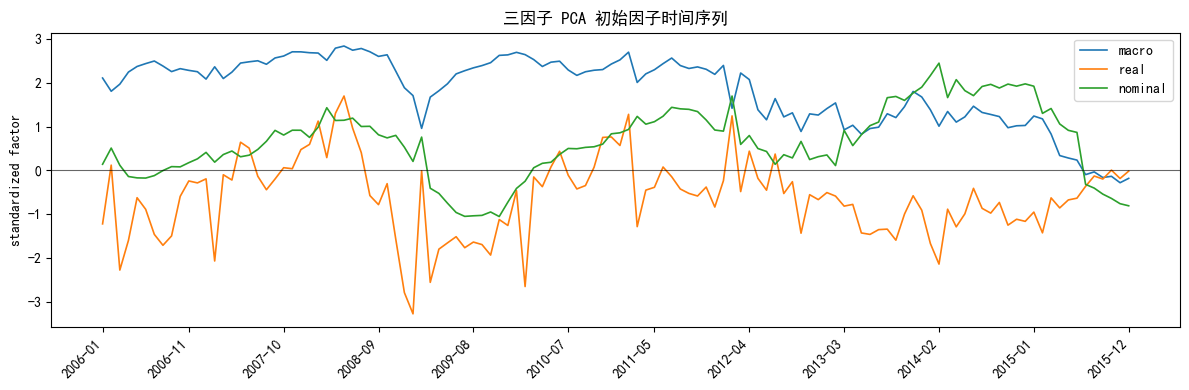

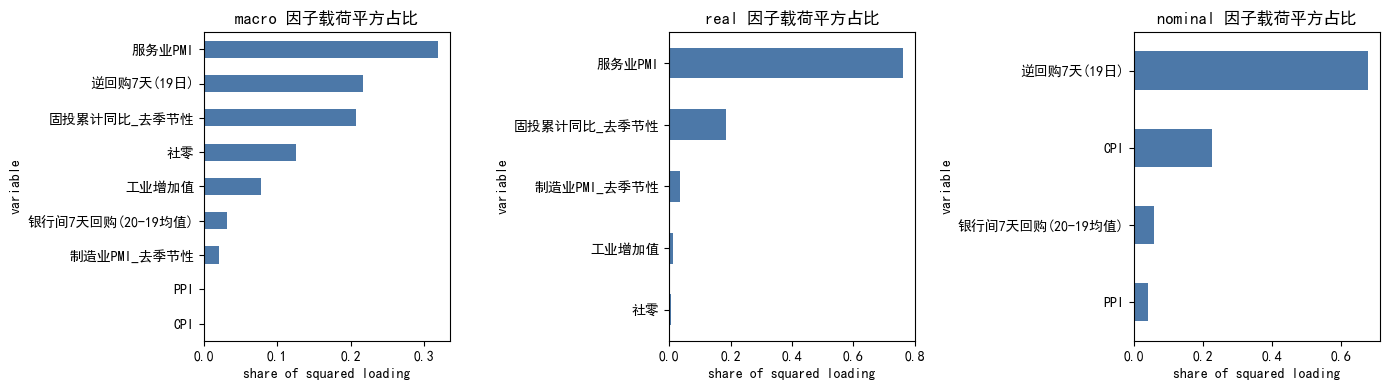

初始 AR 参数前 5 阶：


,rho_1,rho_2,rho_3,rho_4,rho_5
macro,0.980106,-0.593068,0.581041,-0.282826,0.272818
real,0.283104,0.192663,0.106432,0.071340,0.078260
nominal,0.821485,-0.318631,0.339285,-0.084841,0.134957


In [25]:
def first_pc(panel, ref=None):
    bal = panel.dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        fallback = panel.mean(axis=1, skipna=True).fillna(0.0)
        return fallback, pd.Series(1.0, index=panel.columns)
    mean = bal.mean(axis=0)
    X = bal.to_numpy(float) - mean.to_numpy()[None, :]
    u, s, vt = np.linalg.svd(X, full_matrices=False)
    fac = pd.Series(np.sqrt(len(bal)) * u[:, 0], index=bal.index)
    lam = pd.Series(X.T @ fac.to_numpy() / len(bal), index=bal.columns)
    if ref in bal.columns and fac.corr(bal[ref]) < 0:
        fac = -fac
        lam = -lam
    cen = panel[lam.index] - mean
    denom = lam.pow(2)
    denom_available = cen.notna().mul(denom, axis=1).sum(axis=1)
    proj = cen.mul(lam, axis=1).sum(axis=1, skipna=True) / denom_available
    return proj.replace([np.inf, -np.inf], np.nan).interpolate(limit_direction='both').fillna(0.0), lam


def subtract_factor_component(panel, factor, lam):
    aligned_lam = lam.reindex(panel.columns).fillna(0.0)
    fitted = pd.DataFrame(
        np.outer(factor.reindex(panel.index).to_numpy(float), aligned_lam.to_numpy(float)),
        index=panel.index,
        columns=panel.columns,
    )
    return panel - fitted


def pca_diagnostics(panel, lam):
    bal = panel[lam.index].dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        return np.nan, np.nan, len(bal), bal.shape[1]
    X = bal.to_numpy(float) - bal.mean(axis=0).to_numpy()[None, :]
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    fac = (X @ lam.to_numpy(float)) / max(float(lam.pow(2).sum()), 1e-12)
    fitted = np.outer(fac, lam.to_numpy(float))
    explained = float(s[0] ** 2 / np.sum(s ** 2)) if np.sum(s ** 2) > 0 else np.nan
    objective = float(np.mean((X - fitted) ** 2))
    return explained, objective, len(bal), bal.shape[1]


init_cols = {'macro': MACRO_COLS, 'real': REAL_COLS, 'nominal': NOMINAL_COLS}
refs = {factor: choose_factor_reference(init_cols, factor) for factor in FACTOR_NAMES}
alpha0 = {}
pca_lam = {}
pca_source_panels = {}
pca_methods = {}

# 1. Global / macro factor: first PC from all selected monthly indicators.
pca_source_panels['macro'] = z[init_cols['macro']]
alpha0['macro'], pca_lam['macro'] = first_pc(pca_source_panels['macro'], refs.get('macro'))
alpha0['macro'] = alpha0['macro'].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
pca_methods['macro'] = 'global_first_pc_all_monthly'

# 2. Block factors: first PC from residual panels after removing the macro component.
for f in ['real', 'nominal']:
    raw_panel = z[init_cols[f]]
    pca_source_panels[f] = subtract_factor_component(raw_panel, alpha0['macro'], pca_lam['macro'])
    alpha0[f], pca_lam[f] = first_pc(pca_source_panels[f], refs.get(f))
    alpha0[f] = alpha0[f].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
    pca_methods[f] = f'residual_{f}_first_pc_after_macro'

pca_summary_rows = []
pca_contrib_rows = []
for f in FACTOR_NAMES:
    panel_f = pca_source_panels[f]
    lam = pca_lam[f]
    explained, objective, balanced_rows, balanced_cols = pca_diagnostics(panel_f, lam)
    ref_corr = float(alpha0[f].corr(panel_f[refs[f]])) if refs[f] in panel_f.columns else np.nan
    pca_summary_rows.append({
        'factor': f,
        'method': pca_methods[f],
        'reference_variable': refs.get(f),
        'reference_corr': ref_corr,
        'balanced_rows': balanced_rows,
        'balanced_cols': balanced_cols,
        'explained_ratio_1': explained,
        'pca_objective_v': objective,
    })
    square = lam.pow(2)
    total = float(square.sum())
    balanced_columns = panel_f.dropna().columns
    for col in lam.index:
        pca_contrib_rows.append({
            'factor': f,
            'variable': col,
            '载荷lambda': float(lam.loc[col]),
            '载荷绝对值': float(abs(lam.loc[col])),
            '载荷平方': float(square.loc[col]),
            '观测数': int(panel_f[col].notna().sum()),
            '缺失率': float(panel_f[col].isna().mean()),
            '进入平衡PCA块': bool(col in balanced_columns),
            '贡献占比': float(square.loc[col] / total) if total > 0 else np.nan,
        })
pca_summary = pd.DataFrame(pca_summary_rows)
pca_contribution_table = pd.DataFrame(pca_contrib_rows)
pca_contribution_table['贡献排名'] = pca_contribution_table.groupby('factor')['贡献占比'].rank(ascending=False, method='min').astype('Int64')
pca_contribution_table = pca_contribution_table.sort_values(['factor', '贡献占比'], ascending=[True, False])

print('三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。')
display(pca_summary)
print('各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：')
display(pca_contribution_table)

alpha0_df = pd.DataFrame(alpha0)
display(alpha0_df.describe().T)
fig, ax = plt.subplots(figsize=(12, 4))
plot_alpha = alpha0_df.loc[TRAIN_START:TRAIN_END].copy(); plot_alpha.index = plot_alpha.index.astype(str)
plot_alpha.plot(ax=ax, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_alpha.index) - 1, min(12, len(plot_alpha.index)), dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_alpha.index[i] for i in tick_positions], rotation=45, ha='right')
ax.set_title('三因子 PCA 初始因子时间序列')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(FACTOR_NAMES), figsize=(14, 4), sharex=False)
if len(FACTOR_NAMES) == 1: axes = [axes]
for ax, f in zip(axes, FACTOR_NAMES):
    plot_contrib = pca_contribution_table.loc[pca_contribution_table['factor'] == f].set_index('variable')['贡献占比'].sort_values(ascending=True)
    plot_contrib.plot(kind='barh', ax=ax, color='#4c78a8')
    ax.set_title(f'{f} 因子载荷平方占比')
    ax.set_xlabel('share of squared loading')
fig.tight_layout(); plt.show()

def ar_ols(y, p):
    v = y.astype(float).interpolate(limit_direction='both').fillna(0.0).to_numpy(); X = []; Y = []
    for t in range(p, len(v)): X.append(v[t-p:t][::-1]); Y.append(v[t])
    X = np.asarray(X); Y = np.asarray(Y)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p); rho[0] = 0.8
    else: rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return pd.Series(rho, index=[f'rho_{i}' for i in range(1, p + 1)])


def accum(a):
    out = []; prev = 0.0
    for m, x in a.items():
        val = sw(m) * prev + float(x); out.append(val); prev = val
    return pd.Series(out, index=a.index)


ar = pd.DataFrame({f: ar_ols(alpha0[f], FACTOR_AR_ORDER) for f in FACTOR_NAMES}).T
alpha_state0 = {f: alpha0[f].shift(-1).ffill().fillna(0.0) for f in FACTOR_NAMES}
S0 = {f: accum(alpha_state0[f]) for f in FACTOR_NAMES}
xi0 = pd.DataFrame(0.0, index=z.index, columns=STATE_NAMES)
for f in FACTOR_NAMES:
    xi0[f'{f}_alpha_t'] = alpha_state0[f]
    xi0[f'{f}_alpha_lag1'] = alpha0[f]
    for lag in range(2, FACTOR_AR_ORDER): xi0[f'{f}_alpha_lag{lag}'] = alpha0[f].shift(lag - 1).bfill().fillna(0.0)
    xi0[s_name(f)] = S0[f]
    xi0[s_lag1_name(f)] = S0[f].shift(1).bfill().fillna(0.0)
print('初始 AR 参数前 5 阶：')
display(ar.iloc[:, :5])


PCA 结果分析：
1. 这里展示的是三个初始因子，不是最终 EM 平滑因子。
2. `macro` 反映所有月度变量的共同波动，`real` 更偏实际活动，`nominal` 更偏价格变量。
3. PCA 贡献占比只解释初始化来源，不等同于最终三因子 loading 或 GDP 解释贡献。


### 9.2 累加器与高阶状态初始值

根据 Harvey 递推累加器：

$$
S_t^{(0)} = s_t S_{t-1}^{(0)} + \alpha_t^{(0)}
$$

同时参考论文中有限阶动态因子设定，将状态向量扩展为：

$$
\xi_t^{(0)} =
\begin{bmatrix}
\alpha_t^{(0)} & \alpha_{t-1}^{(0)} & \cdots & \alpha_{t-p+1}^{(0)} & S_t^{(0)}
\end{bmatrix}'
$$

其中 `FACTOR_AR_ORDER = p`。










三因子版对每个因子分别递推一个 `S_t`，并把三个因子的 AR lag 和累加器拼接成完整状态向量。


In [26]:
display(xi0.loc[TRAIN_START:TRAIN_START + 5, STATE_NAMES])


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_S_t,macro_S_lag1,real_alpha_t,real_alpha_lag1,real_alpha_lag2,real_alpha_lag3,real_alpha_lag4,real_alpha_lag5,real_S_t,real_S_lag1,nominal_alpha_t,nominal_alpha_lag1,nominal_alpha_lag2,nominal_alpha_lag3,nominal_alpha_lag4,nominal_alpha_lag5,nominal_S_t,nominal_S_lag1
2006-01,1.806902,2.109258,2.108689,2.089607,2.071249,1.997260,1.806902,6.307554,0.118810,-1.223382,-1.266979,-1.037716,-1.348515,-1.673763,0.118810,-3.528078,0.508326,0.139153,0.083363,0.043721,0.029318,0.212290,0.508326,0.266237
2006-02,1.969097,1.806902,2.109258,2.108689,2.089607,2.071249,3.775999,1.806902,-2.278896,0.118810,-1.223382,-1.266979,-1.037716,-1.348515,-2.160086,0.118810,0.115714,0.508326,0.139153,0.083363,0.043721,0.029318,0.624040,0.508326
2006-03,2.245579,1.969097,1.806902,2.109258,2.108689,2.089607,6.021578,3.775999,-1.599616,-2.278896,0.118810,-1.223382,-1.266979,-1.037716,-3.759702,-2.160086,-0.141242,0.115714,0.508326,0.139153,0.083363,0.043721,0.482798,0.624040
2006-04,2.373153,2.245579,1.969097,1.806902,2.109258,2.108689,2.373153,6.021578,-0.625567,-1.599616,-2.278896,0.118810,-1.223382,-1.266979,-0.625567,-3.759702,-0.172356,-0.141242,0.115714,0.508326,0.139153,0.083363,-0.172356,0.482798
2006-05,2.439013,2.373153,2.245579,1.969097,1.806902,2.109258,4.812166,2.373153,-0.891326,-0.625567,-1.599616,-2.278896,0.118810,-1.223382,-1.516892,-0.625567,-0.176709,-0.172356,-0.141242,0.115714,0.508326,0.139153,-0.349065,-0.172356
2006-06,2.497756,2.439013,2.373153,2.245579,1.969097,1.806902,7.309923,4.812166,-1.463856,-0.891326,-0.625567,-1.599616,-2.278896,0.118810,-2.980749,-1.516892,-0.120301,-0.176709,-0.172356,-0.141242,0.115714,0.508326,-0.469366,-0.349065


### 9.3 状态转移参数初始值：AR(p)

参考论文的有限阶动态因子设定，令初始因子满足：

$$
\alpha_t^{(0)} = \rho_1^{(0)}\alpha_{t-1}^{(0)} + \rho_2^{(0)}\alpha_{t-2}^{(0)} + \cdots + \rho_p^{(0)}\alpha_{t-p}^{(0)} + u_t
$$

用 OLS 得到初始 AR(p) 系数。共同因子冲击方差继续采用文献归一化：

$$
Var(u_t)=1
$$

因此残差方差只作为诊断值保留，不作为 Kalman filter 的 $Q_t$ 输入。










三因子版分别对 `macro`、`real`、`nominal` 三个 PCA 初始因子估计 AR(`FACTOR_AR_ORDER`) 初始参数。


In [27]:
def companion_matrix_from_ar_values(values: np.ndarray) -> np.ndarray:
    p = len(values)
    companion = np.zeros((p, p), dtype=float)
    companion[0, :] = values
    if p > 1:
        companion[1:, :-1] = np.eye(p - 1)
    return companion

def ar_spectral_radius_values(values: np.ndarray) -> float:
    eigvals = np.linalg.eigvals(companion_matrix_from_ar_values(values))
    return float(np.max(np.abs(eigvals))) if len(eigvals) else 0.0

ar_init_summary = ar.copy()
ar_init_summary['spectral_radius_diagnostic_no_clip'] = [ar_spectral_radius_values(ar.loc[f].to_numpy(float)) for f in FACTOR_NAMES]
STATE_SHOCK_VARIANCE = 1.0
print(f'state shock variance: {STATE_SHOCK_VARIANCE:.1f}; AR clip=False')
display(ar_init_summary)


state shock variance: 1.0; AR clip=False


,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,spectral_radius_diagnostic_no_clip
macro,0.980106,-0.593068,0.581041,-0.282826,0.272818,-0.011337,0.970695
real,0.283104,0.192663,0.106432,0.071340,0.078260,0.082392,0.928281
nominal,0.821485,-0.318631,0.339285,-0.084841,0.134957,0.045929,0.968305


### 9.4 月度变量载荷与误差方差初始值

对每个月度宏观变量单独回归：

$$
x_{i,t} = \lambda_i^{(0)} \alpha_t^{(0)} + \varepsilon_{i,t}
$$

用 OLS 得到：

$$
\lambda_i^{(0)} =
\frac{\sum_t \alpha_t^{(0)} x_{i,t}}{\sum_t (\alpha_t^{(0)})^2}
$$

月度变量误差方差初始值：

$$
h_i^{(0)} = Var\left(x_{i,t} - \lambda_i^{(0)}\alpha_t^{(0)}\right)
$$









三因子版对每个变量只在允许的因子集合内做 OLS 初始化；不允许加载的因子 loading 固定为 0。


In [28]:
def solve_beta(X,y):
    X=np.asarray(X,float); y=np.asarray(y,float)
    if X.ndim==1: X=X[:,None]
    ok=np.isfinite(y)&np.all(np.isfinite(X),axis=1); X=X[ok]; y=y[ok]
    if len(y)==0: return np.zeros(X.shape[1])
    return np.linalg.solve(X.T@X+1e-6*np.eye(X.shape[1]),X.T@y)
def init_loading_h():
    L=pd.DataFrame(0.0,index=model_cols,columns=FACTOR_NAMES); h=pd.Series(1.0,index=model_cols,name='h')
    for c in model_cols:
        fs=allowed[c]; obs=z[c].dropna()
        if c==GDP_COL:
            obs=obs.loc[[m for m in obs.index if gdp_release_obs(m)]]; X=pd.DataFrame({f:xi0[s_lag1_name(f)].reindex(obs.index) for f in fs})
        else:
            X=pd.DataFrame({f:xi0[f'{f}_alpha_lag1'].reindex(obs.index) for f in fs})
        beta=solve_beta(X.to_numpy(),obs.to_numpy())
        for f,b in zip(fs,beta): L.loc[c,f]=b
        resid=obs.to_numpy()-X.to_numpy()@beta; h.loc[c]=max(float(np.nanmean(resid**2)) if len(resid) else 1.0,MIN_H)
    return L.where(mask,0.0),h
L,h=init_loading_h(); display(L); display(h.to_frame())


,macro,real,nominal
GDP同比,0.124115,-0.004986,0.000000
制造业PMI_去季节性,0.294240,0.301641,0.000000
服务业PMI,1.454941,1.143912,0.000000
工业增加值,0.324742,-0.057687,0.000000
社零,0.258511,0.342205,0.000000
固投累计同比_去季节性,0.451172,-0.356843,0.000000
CPI,0.045764,0.000000,0.515098
PPI,0.137249,0.000000,0.226264
逆回购7天(19日),0.173058,0.000000,1.222483
银行间7天回购(20-19均值),-0.073363,0.000000,0.345103


,h
GDP同比,1.557820
制造业PMI_去季节性,0.677321
服务业PMI,0.325919
工业增加值,1.327579
社零,1.747942
固投累计同比_去季节性,4.060146
CPI,0.467607
PPI,0.691100
逆回购7天(19日),6.424848
银行间7天回购(20-19均值),0.593027


### 9.5 GDP 载荷与观测误差方差初始值

GDP 在发布月份加载 `allowed[GDP_COL]` 中允许的上一月 Harvey 累加器 `S_lag1`。当前设置为 `macro + real`：

$$
GDP_t^{std} = \lambda^{macro}_{GDP}S^{macro}_t + \lambda^{real}_{GDP}S^{real}_t + \varepsilon_{GDP,t}
$$

初始 GDP loading 由季度末 GDP 对当前允许的初始累加器做无截距 OLS 得到。


In [29]:
gdp_param_init = pd.Series({
    **{f'lambda_gdp_{f}_init': float(L.loc[GDP_COL, f]) for f in FACTOR_NAMES},
    'h_gdp_init': float(h.loc[GDP_COL]),
    'gdp_obs_used': int(z.loc[[m for m in z.index if gdp_release_obs(m)], GDP_COL].dropna().shape[0]),
})
display(gdp_param_init.to_frame('value'))


,value
lambda_gdp_macro_init,0.124115
lambda_gdp_real_init,-0.004986
lambda_gdp_nominal_init,0.000000
h_gdp_init,1.557820
gdp_obs_used,137.000000


### 9.6 汇总初始对象

后续 Kalman filter 需要的初始对象包括：

$$
\xi_t^{(0)},\quad \rho_1^{(0)},\ldots,\rho_p^{(0)},\quad Var(u_t)=1,\quad \lambda_i^{(0)},\quad h_i^{(0)},\quad h_{GDP}^{(0)}
$$

这里先构造完整观测误差协方差初始矩阵：

$$
H^{(0)} = diag\left(h_{GDP}^{(0)}, h_1^{(0)}, h_2^{(0)}, \ldots, h_N^{(0)}\right)
$$

注意：$H^{(0)}$ 仍然是初始值。后续 EM 更新时，$H$ 要使用 smoother 给出的状态均值和状态协方差来更新。


In [30]:
H_init = pd.DataFrame(np.diag(h.loc[model_cols_valid].to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)
initialization_artifacts = {
    'alpha_init': alpha0_df,
    'S_init': pd.DataFrame(S0),
    'xi_init': xi0,
    'ar_params_init': ar,
    'pca_block_loadings': pca_lam,
    'pca_summary': pca_summary,
    'state_shock_variance': STATE_SHOCK_VARIANCE,
    'loading_init': L,
    'h_init': h,
    'H_init': H_init,
}
print('Initialization objects generated:')
print(', '.join(initialization_artifacts.keys()))
display(pd.concat([L.add_prefix('lambda_'), h.rename('h_init')], axis=1))


Initialization objects generated:
alpha_init, S_init, xi_init, ar_params_init, pca_block_loadings, pca_summary, state_shock_variance, loading_init, h_init, H_init


,lambda_macro,lambda_real,lambda_nominal,h_init
GDP同比,0.124115,-0.004986,0.000000,1.557820
制造业PMI_去季节性,0.294240,0.301641,0.000000,0.677321
服务业PMI,1.454941,1.143912,0.000000,0.325919
工业增加值,0.324742,-0.057687,0.000000,1.327579
社零,0.258511,0.342205,0.000000,1.747942
固投累计同比_去季节性,0.451172,-0.356843,0.000000,4.060146
CPI,0.045764,0.000000,0.515098,0.467607
PPI,0.137249,0.000000,0.226264,0.691100
逆回购7天(19日),0.173058,0.000000,1.222483,6.424848
银行间7天回购(20-19均值),-0.073363,0.000000,0.345103,0.593027


### 9.7 各观测变量自身的 AR(p) 诊断

主模型的状态转移使用三个 PCA 初始因子的 AR(`FACTOR_AR_ORDER`) 初始化。这里额外对每个观测变量自身估计一次无截距 AR(`FACTOR_AR_ORDER`)，仅用于诊断变量自身的持续性：

$$
x_{i,t} = \phi_{i,1}x_{i,t-1}+\phi_{i,2}x_{i,t-2}+\cdots+\phi_{i,15}x_{i,t-15}+u_{i,t}
$$

缺失值较多的变量可能没有足够连续样本，表中会标记为估计失败。


In [31]:
observed_ar15_rows = []
for col in model_cols_valid:
    series = z_train_df[col].astype(float).dropna()
    row = {'variable': col, 'n_obs': int(series.shape[0]), 'ar_effective_rows': 0, 'estimated': False, 'spectral_radius': np.nan, 'note': ''}
    try:
        coef = ar_ols(series.reindex(z_train_df.index).interpolate(limit_direction='both').fillna(0.0), FACTOR_AR_ORDER)
        row['ar_effective_rows'] = max(int(series.shape[0] - FACTOR_AR_ORDER), 0)
        row['estimated'] = True
        row['spectral_radius'] = ar_spectral_radius_values(coef.to_numpy(float))
    except Exception as exc:
        row['note'] = str(exc)
    observed_ar15_rows.append(row)
observed_ar15_summary = pd.DataFrame(observed_ar15_rows).set_index('variable')
display(observed_ar15_summary)


,n_obs,ar_effective_rows,estimated,spectral_radius,note
variable,,,,,
GDP同比,40,34,True,0.851006,
制造业PMI_去季节性,120,114,True,0.791173,
服务业PMI,46,40,True,0.987586,
工业增加值,120,114,True,0.893116,
社零,117,111,True,0.934596,
固投累计同比_去季节性,110,104,True,0.988973,
CPI,120,114,True,0.941217,
PPI,120,114,True,0.885174,
逆回购7天(19日),120,114,True,1.000835,


## 10. 构造 Kalman filter 系统矩阵

本节按文献附录 A.1-A.2 的口径，先把每一期 Kalman filter 需要的状态方程和观测方程矩阵组装出来。

文献状态方程写作：

$$
\alpha_{t+1}=T_t\alpha_t+R_t\eta_t,
\qquad
\eta_t\sim N(0,Q)
$$

本文 notebook 的状态向量是月频版本：

$$
\xi_t=
\begin{bmatrix}
\alpha_t & \alpha_{t-1} & \cdots & \alpha_{t-p+1} & S_t
\end{bmatrix}'
$$

其中 $S_t$ 是季度 GDP 对应的 Harvey sum accumulator：

$$
S_t=s_t S_{t-1}+\alpha_t
$$

观测方程为：

$$
y_t=Z_t\xi_t+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,H)
$$

由于每期有些变量缺失，文献用选择矩阵 $W_t$ 处理部分观测：

$$
y_t^*=W_t y_t
$$

$$
Z_t^*=W_t Z_t
$$

$$
H_t^*=W_t H W_t'
$$

所以本节输出的核心对象是：

$$
T_t,\quad Q_t,\quad y_t^*,\quad Z_t^*,\quad H_t^*,\quad W_t
$$

**与原文的必要差异**

1. 原文是周频金融条件指数，状态中有 monthly average、monthly sum、quarterly sum 三个 accumulator；本 notebook 是月频宏观变量和季度 GDP，因此只保留季度 sum accumulator $S_t$。
2. 原文记号用 $\alpha_t$ 表示整个状态；本 notebook 为了区分共同因子和状态向量，用 $\xi_t$ 表示状态向量，用 $\alpha_t$ 表示状态向量里的当期共同因子。
3. 原文将状态扰动方差归一化；本 notebook 同样设 $Var(\eta_t)=1$。


In [32]:
def build_state_transition_system(month: pd.Period, ar_params: pd.DataFrame):
    F_t = pd.DataFrame(trans(month, ar_params), index=STATE_NAMES, columns=STATE_NAMES)
    Q_t = pd.DataFrame(Q, index=STATE_NAMES, columns=STATE_NAMES)
    return F_t, Q_t

example_month = TRAIN_START
F_example, Q_example = build_state_transition_system(example_month, ar)
Z_example = obs_mat(example_month, L)
print(f'Example month: {example_month}; state_dim={len(STATE_NAMES)}; observed_dim={len(model_cols_valid)}')
display(F_example.iloc[:8, :8])
display(Q_example.iloc[:8, :8])
display(Z_example.loc[model_cols_valid, Z_example.columns[Z_example.abs().sum(axis=0) > 0]])


Example month: 2006-01; state_dim=24; observed_dim=10


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_S_t,macro_S_lag1
macro_alpha_t,0.980106,-0.593068,0.581041,-0.282826,0.272818,-0.011337,0.0,0.0
macro_alpha_lag1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
macro_alpha_lag2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
macro_alpha_lag3,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0
macro_alpha_lag4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0
macro_alpha_lag5,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0
macro_S_t,0.980106,-0.593068,0.581041,-0.282826,0.272818,-0.011337,0.0,0.0
macro_S_lag1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_S_t,macro_S_lag1
macro_alpha_t,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
macro_alpha_lag1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_S_t,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
macro_S_lag1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,macro_alpha_lag1,macro_S_lag1,real_alpha_lag1,real_S_lag1,nominal_alpha_lag1
GDP同比,0.000000,0.124115,0.000000,-0.004986,0.000000
制造业PMI_去季节性,0.294240,0.000000,0.301641,0.000000,0.000000
服务业PMI,1.454941,0.000000,1.143912,0.000000,0.000000
工业增加值,0.324742,0.000000,-0.057687,0.000000,0.000000
社零,0.258511,0.000000,0.342205,0.000000,0.000000
固投累计同比_去季节性,0.451172,0.000000,-0.356843,0.000000,0.000000
CPI,0.045764,0.000000,0.000000,0.000000,0.515098
PPI,0.137249,0.000000,0.000000,0.000000,0.226264
逆回购7天(19日),0.173058,0.000000,0.000000,0.000000,1.222483
银行间7天回购(20-19均值),-0.073363,0.000000,0.000000,0.000000,0.345103


## 11. Kalman Filter Forward Recursion

This section follows the Durbin and Koopman notation used in Appendix A.1 of the paper. Given $a_t$ and $P_t$:

$$
v_t = y_t - Z_t a_t
$$

$$
F_t = Z_tP_tZ_t' + H
$$

$$
K_t = T_tP_tZ_t'F_t^{-1}
$$

$$
L_t = T_t - K_tZ_t
$$

$$
a_{t+1} = T_ta_t + K_tv_t
$$

$$
P_{t+1} = T_tP_tL_t' + RQR'
$$

With missing observations, the code uses the selected system:

$$
y_t^*,\quad Z_t^*,\quad H_t^*
$$

so that:

$$
v_t = y_t^* - Z_t^* a_t
$$

$$
F_t^* = Z_t^*P_tZ_t^{*'} + H_t^*
$$

In code, `Omega_t` is the paper's $F_t^*$, named differently to avoid collision with the transition matrix. The log likelihood follows paper Eq. (4), omitting the normal constant.


In [33]:
def pinv_solve(A, B):
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _solve_symmetric(A, B):
    A = 0.5 * (A + A.T)
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _safe_slogdet(A):
    A = 0.5 * (A + A.T)
    sign, logdet = np.linalg.slogdet(A)
    if sign > 0:
        return float(logdet)
    jitter = 1e-10 * max(float(np.nanmax(np.abs(np.diag(A)))) if A.size else 1.0, 1.0)
    for _ in range(6):
        sign, logdet = np.linalg.slogdet(A + jitter * np.eye(A.shape[0]))
        if sign > 0:
            return float(logdet)
        jitter *= 10.0
    return float(np.log(max(np.linalg.det(A + jitter * np.eye(A.shape[0])), 1e-12)))


FACTOR_POS = {f: i for i, f in enumerate(FACTOR_NAMES)}
FACTOR_ALPHA_POS = {f: pos[f'{f}_alpha_t'] for f in FACTOR_NAMES}
FACTOR_S_POS = {f: pos[s_name(f)] for f in FACTOR_NAMES}
FACTOR_S_LAG1_POS = {f: pos[s_lag1_name(f)] for f in FACTOR_NAMES}
FACTOR_AR_POS = {f: np.array([pos[n] for n in FACTOR_A[f]], dtype=int) for f in FACTOR_NAMES}
MODEL_COL_POS = {c: i for i, c in enumerate(model_cols)}

TARGET_STATE_POS = {}
TARGET_FACTOR_POS = {}
for c in model_cols:
    if c == GDP_COL:
        TARGET_STATE_POS[c] = np.array([FACTOR_S_LAG1_POS[f] for f in allowed[c]], dtype=int)
    else:
        TARGET_STATE_POS[c] = np.array([pos[f'{f}_alpha_lag1'] for f in allowed[c]], dtype=int)
    TARGET_FACTOR_POS[c] = np.array([FACTOR_POS[f] for f in allowed[c]], dtype=int)


def _build_fast_panel_cache(panel):
    months = list(panel.index)
    y = panel.loc[months, model_cols].to_numpy(float)
    obs_idx = [np.flatnonzero(np.isfinite(y[i])) for i in range(len(months))]
    q_end_flags = np.array([q_end(m) for m in months], dtype=bool)
    gdp_release_flags = np.array([gdp_release_obs(m) for m in months], dtype=bool)
    q_start_flags = np.array([q_start(m) for m in months], dtype=bool)
    obs_for_update = {}
    for c in model_cols:
        j = MODEL_COL_POS[c]
        valid = np.flatnonzero(np.isfinite(y[:, j]))
        if c == GDP_COL:
            valid = np.array([i for i in valid if gdp_release_flags[i]], dtype=int)
        obs_for_update[c] = valid
    return {
        'months': months,
        'y': y,
        'obs_idx': obs_idx,
        'q_end': q_end_flags,
        'gdp_release': gdp_release_flags,
        'q_start': q_start_flags,
        'obs_for_update': obs_for_update,
    }


def _transition_array(month_is_q_start, ar_values):
    T = np.zeros((nstate, nstate), dtype=float)
    st = 0.0 if month_is_q_start else 1.0
    for f in FACTOR_NAMES:
        ap = FACTOR_AR_POS[f]
        sp = FACTOR_S_POS[f]
        spl = FACTOR_S_LAG1_POS[f]
        rho = ar_values[FACTOR_POS[f]]
        T[ap[0], ap] = rho
        for lag in range(1, FACTOR_AR_ORDER):
            T[ap[lag], ap[lag - 1]] = 1.0
        T[sp, ap] = rho
        T[sp, sp] = st
        T[spl, sp] = 1.0
    return T


def _loading_array(L):
    return L.reindex(index=model_cols, columns=FACTOR_NAMES).fillna(0.0).to_numpy(float)


def _h_array(h):
    return h.reindex(model_cols).fillna(1.0).to_numpy(float)


def _ar_array(ar):
    return ar.reindex(index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)]).fillna(0.0).to_numpy(float)


def _observed_Z(obs, q_end_flag, gdp_release_flag, L_arr):
    Z = np.zeros((len(obs), nstate), dtype=float)
    for r, j in enumerate(obs):
        c = model_cols[j]
        if c == GDP_COL and not gdp_release_flag:
            continue
        state_idx = TARGET_STATE_POS[c]
        factor_idx = TARGET_FACTOR_POS[c]
        Z[r, state_idx] = L_arr[j, factor_idx]
    return Z



def kfilter_fast_arr(panel_cache, ar_arr, L_arr, h_arr, a1=None, P1=None):
    months = panel_cache['months']; n = len(months)
    y = panel_cache['y']; obs_idx = panel_cache['obs_idx']
    ar_arr = np.asarray(ar_arr, dtype=float)
    L_arr = np.asarray(L_arr, dtype=float)
    h_arr = np.asarray(h_arr, dtype=float)
    ap = np.zeros((n, nstate), dtype=float); Pp = np.zeros((n, nstate, nstate), dtype=float)
    af = np.zeros((n, nstate), dtype=float); Pf = np.zeros((n, nstate, nstate), dtype=float)
    Ts = np.zeros((n, nstate, nstate), dtype=float)
    a = np.zeros(nstate, dtype=float) if a1 is None else np.asarray(a1, dtype=float).copy()
    P = np.eye(nstate, dtype=float) * 10.0 if P1 is None else np.asarray(P1, dtype=float).copy()
    ll = 0.0
    for i in range(n):
        if i == 0:
            T = np.eye(nstate, dtype=float)
        else:
            T = _transition_array(panel_cache['q_start'][i], ar_arr)
            a = T @ a
            P = T @ P @ T.T + Q
            P = 0.5 * (P + P.T)
        Ts[i] = T; ap[i] = a; Pp[i] = P
        obs = obs_idx[i]
        if len(obs):
            Z = _observed_Z(obs, panel_cache['q_end'][i], panel_cache['gdp_release'][i], L_arr)
            yv = y[i, obs]
            H = np.diag(np.maximum(h_arr[obs], MIN_H))
            v = yv - Z @ a
            F = Z @ P @ Z.T + H
            F = 0.5 * (F + F.T)
            invv = _solve_symmetric(F, v)
            Finv_ZP = _solve_symmetric(F, Z @ P)
            K = Finv_ZP.T
            ll += -0.5 * (_safe_slogdet(F) + float(v.T @ invv))
            a = a + K @ v
            P = P - K @ Z @ P
            P = 0.5 * (P + P.T)
        af[i] = a; Pf[i] = P
    return {'months': months, 'ap': ap, 'Pp': Pp, 'af': af, 'Pf': Pf, 'Ts': Ts, 'loglike': float(ll), 'panel_cache': panel_cache}


def kfilter_fast(panel_cache, ar, L, h, a1=None, P1=None):
    return kfilter_fast_arr(panel_cache, _ar_array(ar), _loading_array(L), _h_array(h), a1=a1, P1=P1)

def smooth_fast(fr, return_frames=False):
    months = fr['months']; n = len(months)
    a = fr['af'].copy(); P = fr['Pf'].copy()
    for i in range(n - 2, -1, -1):
        J = fr['Pf'][i] @ fr['Ts'][i + 1].T @ np.linalg.pinv(fr['Pp'][i + 1])
        a[i] = fr['af'][i] + J @ (a[i + 1] - fr['ap'][i + 1])
        P[i] = fr['Pf'][i] + J @ (P[i + 1] - fr['Pp'][i + 1]) @ J.T
        P[i] = 0.5 * (P[i] + P[i].T)
    out = {'state_array': a, 'cov_array': P, 'months': months}
    if return_frames:
        out['state'] = pd.DataFrame(a, index=months, columns=STATE_NAMES)
        out['cov'] = {m: pd.DataFrame(P[i], index=STATE_NAMES, columns=STATE_NAMES) for i, m in enumerate(months)}
    return out


def _ar_ols_array(v, p):
    v = np.asarray(v, dtype=float)
    X = []; Y = []
    for t in range(p, len(v)):
        X.append(v[t - p:t][::-1]); Y.append(v[t])
    X = np.asarray(X, dtype=float); Y = np.asarray(Y, dtype=float)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p, dtype=float); rho[0] = 0.8
    else:
        rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return rho


def update_ar_fast(state_array):
    arr = np.zeros((len(FACTOR_NAMES), FACTOR_AR_ORDER), dtype=float)
    for f in FACTOR_NAMES:
        arr[FACTOR_POS[f]] = _ar_ols_array(state_array[:, FACTOR_ALPHA_POS[f]], FACTOR_AR_ORDER)
    return pd.DataFrame(arr, index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)])


def update_L_h_fast(panel_cache, state_array, cov_array):
    y = panel_cache['y']
    L_arr = np.zeros((len(model_cols), len(FACTOR_NAMES)), dtype=float)
    h_new = np.ones(len(model_cols), dtype=float)
    for c in model_cols:
        j = MODEL_COL_POS[c]
        obs = panel_cache['obs_for_update'][c]
        if len(obs) == 0:
            h_new[j] = 1.0
            continue
        states = TARGET_STATE_POS[c]
        factors = TARGET_FACTOR_POS[c]
        k = len(states)
        num = np.zeros(k, dtype=float)
        den = np.zeros((k, k), dtype=float)
        for i in obs:
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            num += float(y[i, j]) * mu
            den += V + np.outer(mu, mu)
        beta = pinv_solve(den + 1e-8 * np.eye(k), num)
        L_arr[j, factors] = beta
        hs = 0.0
        for i in obs:
            yy = float(y[i, j])
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            second = V + np.outer(mu, mu)
            hs += yy ** 2 - 2.0 * yy * float(beta @ mu) + float(beta @ second @ beta)
        h_new[j] = max(float(hs / len(obs)), MIN_H)
    Lnew = pd.DataFrame(L_arr, index=model_cols, columns=FACTOR_NAMES).where(mask, 0.0)
    hnew = pd.Series(h_new, index=model_cols, name='h')
    return Lnew, hnew


def m_step_fast(panel_cache, state_array, cov_array, ar_params_old=None, loading_old=None, h_old=None):
    """One three-factor EM M-step on fast numpy arrays.

    This keeps the same public function name used by the original single-factor
    notebook while dispatching to the three-factor block-loading updates.
    """
    ar_new = update_ar_fast(state_array)
    loading_new, h_new = update_L_h_fast(panel_cache, state_array, cov_array)
    return {'ar': ar_new, 'loading': loading_new, 'h': h_new}


def run_em_fast(panel, ar0, L0, h0):
    panel_cache = _build_fast_panel_cache(panel)
    ar = ar0.copy(); L = L0.copy(); h = h0.copy()
    a1 = xi0.iloc[0].reindex(STATE_NAMES).fillna(0.0).to_numpy(float)
    P1 = np.eye(nstate, dtype=float) * 10.0
    hist = []
    last = None
    print(f'Fast EM start: tol={TOL:g}, state_dim={nstate}, numpy_loop=True, max_iter=None')
    it = 0
    while True:
        it += 1
        iter_t0 = time.perf_counter()
        t0 = time.perf_counter(); fr = kfilter_fast(panel_cache, ar, L, h, a1, P1); filter_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); sm = smooth_fast(fr, return_frames=False); smoother_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); ar2 = update_ar_fast(sm['state_array']); L2, h2 = update_L_h_fast(panel_cache, sm['state_array'], sm['cov_array']); m_step_seconds = time.perf_counter() - t0
        a1_next = sm['state_array'][0].copy()
        ll = fr['loglike']
        rel = np.nan if last is None else abs((ll - last) / max(1.0, abs(last)))
        hist.append({
            'iteration': it,
            'loglike': ll,
            'relative_loglike_change': rel,
            'min_h': float(h2.min()),
            'max_h': float(h2.max()),
            'filter_seconds': filter_seconds,
            'smoother_seconds': smoother_seconds,
            'm_step_seconds': m_step_seconds,
            'iteration_seconds': time.perf_counter() - iter_t0,
        })
        print(f"iter {it:03d}: loglike={ll:.6f}, rel_change={rel}, min_h={h2.min():.3g}, time(filter/smoother/M)={filter_seconds:.2f}/{smoother_seconds:.2f}/{m_step_seconds:.2f}s")
        ar, L, h = ar2, L2, h2
        a1 = a1_next
        if last is not None and rel < TOL:
            break
        last = ll
    fr = kfilter_fast(panel_cache, ar, L, h, a1, P1)
    sm = smooth_fast(fr, return_frames=True)
    return {'ar': ar, 'loading': L, 'h': h, 'a1': pd.Series(a1, index=STATE_NAMES), 'history': pd.DataFrame(hist), 'filter': fr, 'smoother': sm}

# Keep the public entry point unchanged for downstream cells.
run_em = run_em_fast


## 12. Kalman Smoother Backward Recursion

Appendix A.1 uses the $r_t$ and $N_t$ backward smoother with terminal conditions:

$$
r_T=0,
\qquad
N_T=0
$$

Backward recursion:

$$
r_{t-1}=Z_t'F_t^{-1}v_t+L_t'r_t
$$

$$
N_{t-1}=Z_t'F_t^{-1}Z_t+L_t'N_tL_t
$$

Smoothed state and covariance:

$$
\hat{\alpha}_t=a_t+P_tr_{t-1}
$$

$$
V_t=P_t-P_tN_{t-1}P_t
$$

The paper also computes the lag-one covariance needed by the EM M-step:

$$
J_t=P_tL_{t-1}'(I-N_{t-1}P_t)
$$

The code returns `smoothed_state`, `smoothed_cov`, and `lag_one_smoothed_cov` for the M-step.


In [34]:
print('RTS smoother functions are defined together with the fast Kalman implementation in section 11.')


RTS smoother functions are defined together with the fast Kalman implementation in section 11.


## 13. EM M-step Following Appendix A.3

Appendix A.3 maximizes the conditional expectation of the complete-data log likelihood. The smoother supplies:

> $$
> E(\alpha_t\mid Y)=\hat{\alpha}_t
> $$

> $$
> Var(\alpha_t\mid Y)=V_t
> $$

> $$
> Cov(\alpha_t,\alpha_{t-1}\mid Y)=J_t'
> $$

The paper's update equations are:

> $$
> T^{new}=BA^{-1}
> $$

> $$
> Z^{new}=ED^{-1}
> $$

Under the restricted measurement structure, each indicator loads on one state element, so loadings and diagonal $H_i$ are updated variable by variable. The EM loop also updates $a_1$ to the first smoothed state and keeps $P_1$ at the baseline initial covariance, as described in Appendix A.3.


### 13.1 Update Transition Dynamics AR(p)

The unrestricted paper update is:

> $$
> T^{new}=BA^{-1}
> $$

For the first row of the AR(`FACTOR_AR_ORDER`) companion block, define:

> $$
> \alpha_t=\rho_1\alpha_{t-1}+\rho_2\alpha_{t-2}+\cdots+\rho_p\alpha_{t-p}+u_t
> $$

> $$
> x_{t-1}=\begin{bmatrix}\alpha_{t-1} & \alpha_{t-2} & \cdots & \alpha_{t-p}\end{bmatrix}'
> $$

Then the corresponding $BA^{-1}$ update is:

> $$
> \rho^{new}=\left[\sum_t E(x_{t-1}x_{t-1}'\mid Y)\right]^{-1}\left[\sum_t E(x_{t-1}\alpha_t\mid Y)\right]
> $$

The companion spectral radius is reported as a diagnostic only; it is not clipped or rescaled.


In [35]:
print('AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).')


AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).


### 13.2 更新观测载荷 Z

文献 unrestricted 更新为：

> $$
> Z^{new}=ED^{-1}
> $$

其中：

> $$
> D=\sum_{t=1}^{T}E(\xi_t\xi_t'\mid Y)
> $$

> $$
> E=\sum_{t=1}^{T}y_t\hat{\xi}_t'
> $$

但文献随后说明，在模型受限结构下，每个指标只加载到一个状态元素。若变量 $i$ 加载到状态元素 $j$，则：

> $$
> y_{i,t}=\lambda_i\xi_{j,t}+\varepsilon_{i,t}
> $$

只使用该变量实际有观测的时期 $\mathcal{T}_i$：

> $$
> \lambda_i^{new}
> =
> \frac{
> \sum_{t\in\mathcal{T}_i} y_{i,t}\hat{\xi}_{j,t}
> }{
> \sum_{t\in\mathcal{T}_i}E(\xi_{j,t}^2\mid Y)
> }
> $$

其中：

> $$
> E(\xi_{j,t}^2\mid Y)=\hat{\xi}_{j,t}^2+V_{j,j,t}
> $$

本 notebook 使用同一受限载荷更新：月度变量加载到 $\alpha_t$，GDP 加载到 $S_t$。


In [36]:
print('Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.')


Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.


### 13.3 Update Observation Error Variance H

The paper uses diagonal $H$ and updates each observed variable separately. If variable $i$ loads on state element $j$:

> $$
> H_i^{new}=\frac{1}{T_i}\sum_{t\in\mathcal{T}_i}\left(y_{i,t}-\lambda_i^{new}\hat{\xi}_{j,t}\right)^2
> $$

where $\mathcal{T}_i$ contains only periods in which variable $i$ is observed. The code follows this variable-by-variable mean squared smoothed residual update.


In [37]:
print('Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.')


Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.


### 13.4 One M-step Summary

One M-step is not the final converged estimate. Full training iterates:

> $$
> \text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
> $$

until the paper Eq. (4) log likelihood is stable. The convergence threshold is:

> $$
> \left|\frac{\log L^{(k)}-\log L^{(k-1)}}{\left(\log L^{(k)}+\log L^{(k-1)}\right)/2}\right|<10^{-6}
> $$

Replication status:

1. Kalman filter uses the paper's $a_t,P_t,K_t,L_t$ recursion.
2. Kalman smoother uses the paper's $r_t,N_t$ recursion and returns lag-one covariance for the M-step.
3. M-step updates AR(`FACTOR_AR_ORDER`), $Z$, and diagonal $H$ following Appendix A.3, with $Var(u_t)=1$ normalization.
4. $a_1$ is updated to the first smoothed state; $P_1$ stays at the baseline initial covariance.


In [38]:
panel_cache_check = _build_fast_panel_cache(z.loc[TRAIN_START:TRAIN_END, model_cols_valid])
fr_check = kfilter_fast(panel_cache_check, ar, L, h)
sm_check = smooth_fast(fr_check, return_frames=True)
m_step_check = m_step_fast(panel_cache_check, sm_check['state_array'], sm_check['cov_array'], ar, L, h)
print(f"One-step M-step check: min_h={float(m_step_check['h'].min()):.3g}, max_h={float(m_step_check['h'].max()):.3g}")
display(m_step_check['loading'])


One-step M-step check: min_h=0.249, max_h=0.894


,macro,real,nominal
GDP同比,0.134747,-0.019791,0.000000
制造业PMI_去季节性,0.340332,0.119724,0.000000
服务业PMI,1.153241,0.941111,0.000000
工业增加值,0.341413,-0.018963,0.000000
社零,0.171403,-0.148683,0.000000
固投累计同比_去季节性,0.245492,-0.262710,0.000000
CPI,0.098795,0.000000,0.520288
PPI,0.230234,0.000000,0.369509
逆回购7天(19日),0.099777,0.000000,0.144470
银行间7天回购(20-19均值),-0.182994,0.000000,0.404646


## 14. EM Iteration

This section packages steps 11-13 into the EM loop:

$$
\text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
$$

The loop updates:

$$
\rho_1,\ldots,\rho_{15}, \quad Z, \quad H, \quad a_1
$$

and keeps the paper normalization:

$$
Var(u_t)=1
$$

The convergence threshold is the paper setting:

$$
\left|\frac{\log L^{(k)}-\log L^{(k-1)}}{(|\log L^{(k)}|+|\log L^{(k-1)}|)/2}\right|<10^{-6}
$$

The measurement structure follows the paper's restricted loading design: each variable loads on one state element, $H$ is diagonal, and missing observations enter through the per-period selection matrix.


### 14.1 参数化 Kalman 系统

前面的第 11 至 13 步使用初始化参数。EM 循环需要每一轮使用当前参数，因此这里重新定义可传入参数的 Kalman 系统函数。


In [39]:
def build_observation_matrix_full_with_params(month: pd.Period, loading_full: pd.DataFrame) -> pd.DataFrame:
    return obs_mat(month, loading_full)

def build_H_from_diag(h_diag: pd.Series) -> pd.DataFrame:
    h_diag = h_diag.loc[model_cols_valid].clip(lower=MIN_H)
    return pd.DataFrame(np.diag(h_diag.to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)

print('Parameterized Kalman system uses the fast numpy arrays defined above.')


Parameterized Kalman system uses the fast numpy arrays defined above.


### 14.2 参数化 Kalman filter 与 smoother

这一步和第 11、12 步公式相同，只是每轮使用当前的 AR(p) 参数、$Z$ 和 $H$。


In [40]:
def run_kalman_filter_with_params(y_panel, start, end, ar_params, loading_full, h_diag, a1=None, P1=None):
    panel_cache = _build_fast_panel_cache(y_panel.loc[start:end, model_cols_valid])
    return kfilter_fast(panel_cache, ar_params, loading_full, h_diag, a1=a1, P1=P1)

def run_kalman_smoother_with_params(filter_results, start, end, ar_params, y_panel=None, loading_full=None, h_diag=None):
    return smooth_fast(filter_results, return_frames=True)


### 14.3 参数化 M-step

这一步沿用第 13 步的文献公式，只把输出改成 EM 循环可使用的新参数。


In [41]:
def m_step_update_params(y_panel, smoothed_state, smoothed_cov, lag_one_smoothed_cov, ar_params_old, loading_old, h_old):
    panel_cache = _build_fast_panel_cache(y_panel.loc[smoothed_state.index, model_cols_valid])
    state_array = smoothed_state.loc[panel_cache['months'], STATE_NAMES].to_numpy(float)
    cov_array = np.stack([smoothed_cov[m].loc[STATE_NAMES, STATE_NAMES].to_numpy(float) for m in panel_cache['months']])
    return m_step_fast(panel_cache, state_array, cov_array, ar_params_old, loading_old, h_old)


### 14.4 Run EM loop

The EM loop uses ordinary relative log-likelihood change `relative_loglike_change < 1e-4` as the handoff criterion. There is no iteration cap. Each iteration prints `rel_change`, minimum H, and timing. Aitken acceleration/early-stop is applied later in the quasi-Newton stage, not here.


Fast EM start: tol=0.0001, state_dim=24, numpy_loop=True, max_iter=None
iter 001: loglike=-612.410742, rel_change=nan, min_h=0.256, time(filter/smoother/M)=0.06/0.05/0.11s
iter 002: loglike=-171.689294, rel_change=0.7196500939921572, min_h=0.145, time(filter/smoother/M)=0.14/0.07/0.12s
iter 003: loglike=-94.659270, rel_change=0.44865944726633933, min_h=0.101, time(filter/smoother/M)=0.10/0.06/0.11s
iter 004: loglike=-80.363798, rel_change=0.15102031291033052, min_h=0.0756, time(filter/smoother/M)=0.07/0.05/0.12s
iter 005: loglike=-67.686245, rel_change=0.1577520356755562, min_h=0.0589, time(filter/smoother/M)=0.06/0.05/0.10s
iter 006: loglike=-53.540210, rel_change=0.20899423066097692, min_h=0.0415, time(filter/smoother/M)=0.06/0.04/0.09s
iter 007: loglike=-39.739274, rel_change=0.2577676918181266, min_h=0.0298, time(filter/smoother/M)=0.05/0.05/0.11s
iter 008: loglike=-27.777704, rel_change=0.3010012212256761, min_h=0.0222, time(filter/smoother/M)=0.05/0.04/0.08s
iter 009: loglike=-17

,macro,real,nominal
GDP同比,0.013394,0.007536,0.000000
制造业PMI_去季节性,0.026002,0.020690,0.000000
服务业PMI,0.021672,-0.060610,0.000000
工业增加值,0.036801,0.013902,0.000000
社零,0.036869,-0.015239,0.000000
固投累计同比_去季节性,0.063314,-0.026493,0.000000
CPI,0.045582,0.000000,0.228149
PPI,0.053341,0.000000,0.156730
逆回购7天(19日),0.023806,0.000000,0.012604
银行间7天回购(20-19均值),-0.004058,0.000000,0.124582


Final observation error variance H:


,h
GDP同比,0.014254
制造业PMI_去季节性,0.431885
服务业PMI,0.711157
工业增加值,0.316153
社零,0.679888
固投累计同比_去季节性,0.005000
CPI,0.006621
PPI,0.254151
逆回购7天(19日),0.848220
银行间7天回购(20-19均值),0.561603


Recent EM history:


,iteration,loglike,relative_loglike_change,min_h,max_h,filter_seconds,smoother_seconds,m_step_seconds,iteration_seconds
267,268,135.639153,0.000414,0.005,0.848516,0.040267,0.031127,0.071700,0.143237
268,269,135.686039,0.000346,0.005,0.848443,0.037941,0.031294,0.076681,0.146061
269,270,135.722568,0.000269,0.005,0.848370,0.041522,0.032718,0.071089,0.145451
270,271,135.747475,0.000184,0.005,0.848296,0.036944,0.030935,0.068724,0.136758
271,272,135.759293,0.000087,0.005,0.848220,0.038210,0.030854,0.071219,0.140421


EM timing breakdown:


,mean,max,sum,share_of_iteration_sum
filter_seconds,0.042478,0.138445,11.553916,0.272678
smoother_seconds,0.035001,0.081661,9.520342,0.224684
m_step_seconds,0.078141,0.124159,21.254386,0.501613
iteration_seconds,0.155780,0.321522,42.372083,1.000000


Final smoothed alpha_t factor summary:


,start,end,mean,std,min,max
macro,2006-01,2015-12,0.042215,17.877894,-35.612016,27.588109
real,2006-01,2015-12,-0.186654,19.835367,-49.257342,46.351207
nominal,2006-01,2015-12,-0.013464,4.990158,-12.237762,8.194535


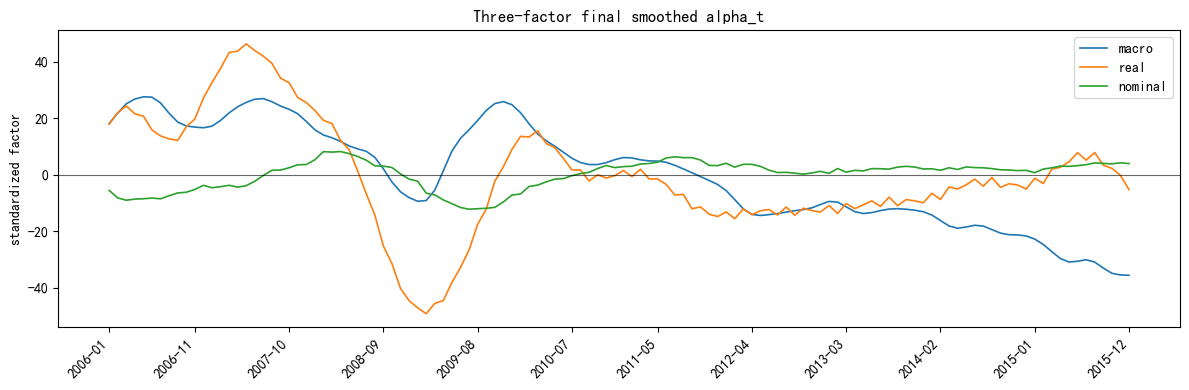

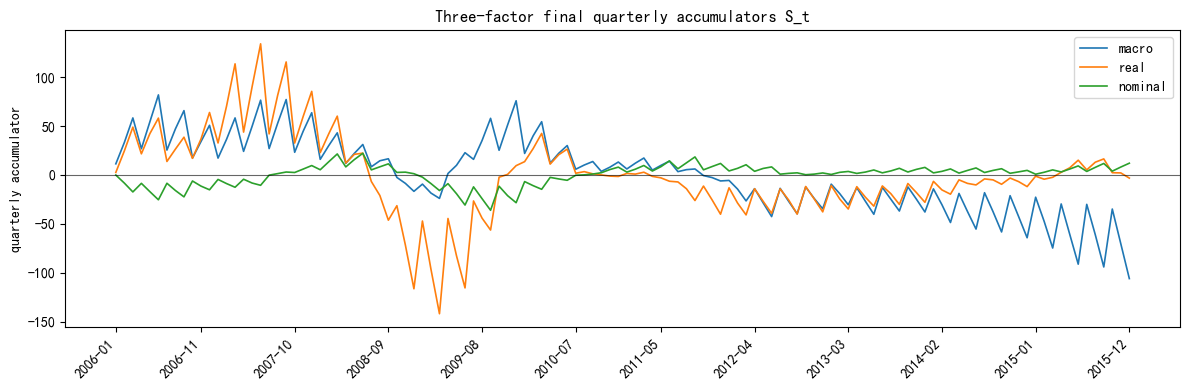

Final smoothed alpha_t annual mean:


,macro,real,nominal
year,,,
2006,21.950447,18.726401,-7.164276
2007,22.951669,37.392292,-0.896861
2008,6.156092,-6.701451,4.671335
2009,11.036028,-25.381758,-9.291178
2010,9.274522,5.696772,-0.948651
2011,2.603423,-5.849232,4.505966
2012,-11.974306,-13.172946,1.889592
2013,-12.146482,-10.424861,1.916819
2014,-18.897898,-4.291329,2.014898


In [42]:
paths={
 'ar':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_ar.csv',
 'loading':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_loading.csv',
 'h':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_h.csv',
 'state':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_state.csv',
 'history':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_history.csv',
 'meta':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_meta.json',
}


def _em_cache_meta() -> dict:
    return {
        'train_start': str(TRAIN_START),
        'train_end': str(TRAIN_END),
        'factor_ar_order': int(FACTOR_AR_ORDER),
        'min_h': float(MIN_H),
        'factors': list(FACTOR_NAMES),
        'model_cols': list(model_cols),
        'model_cols_valid': list(model_cols_valid),
        'allowed_factor_by_variable': allowed,
        'em_to_qn_relative_loglike_tol': float(EM_TO_QN_REL_LOGLIKE_TOL),
        'relative_loglike_tol': float(TOL),
    }


def _em_cache_matches(meta: dict) -> bool:
    expected = _em_cache_meta()
    return all(meta.get(k) == v for k, v in expected.items())


def _load_em_cache_if_available():
    required = [paths['ar'], paths['loading'], paths['h'], paths['state'], paths['history'], paths['meta']]
    if not LOAD_EM_FROM_CACHE or not all(path.exists() for path in required):
        return None
    try:
        with open(paths['meta'], 'r', encoding='utf-8') as f:
            meta = json.load(f)
        if not _em_cache_matches(meta):
            print('EM cache exists but configuration does not match; recomputing EM.')
            return None
        print('Loading EM result from cache.')
        ar_cached = pd.read_csv(paths['ar'], index_col=0, encoding='utf-8-sig').reindex(index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)]).fillna(0.0)
        loading_cached = pd.read_csv(paths['loading'], index_col=0, encoding='utf-8-sig').reindex(index=model_cols, columns=FACTOR_NAMES).fillna(0.0)
        h_cached = pd.read_csv(paths['h'], index_col=0, encoding='utf-8-sig').iloc[:, 0].reindex(model_cols).fillna(1.0).clip(lower=MIN_H)
        hist_cached = pd.read_csv(paths['history'], encoding='utf-8-sig')
        st_cached = pd.read_csv(paths['state'], index_col=0, encoding='utf-8-sig')
        st_cached.index = pd.PeriodIndex(st_cached.index, freq='M')
        a1_cached = pd.Series(meta.get('a1', {}), dtype=float).reindex(STATE_NAMES).fillna(0.0)
        panel_cache = _build_fast_panel_cache(z.loc[TRAIN_START:TRAIN_END, model_cols_valid])
        fr_cached = kfilter_fast_arr(panel_cache, _ar_array(ar_cached), _loading_array(loading_cached), _h_array(h_cached), a1=a1_cached.to_numpy(dtype=float), P1=None)
        return {
            'ar': ar_cached,
            'loading': loading_cached,
            'h': h_cached,
            'a1': a1_cached,
            'history': hist_cached,
            'filter': fr_cached,
            'smoother': {'state': st_cached, 'cov': {}},
            'loaded_from_cache': True,
        }
    except Exception as exc:
        print(f'EM cache load failed; recomputing EM: {exc}')
        return None

profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'EM']
res = _load_em_cache_if_available()
if res is None:
    em_start_time = time.perf_counter()
    res=run_em(z.loc[TRAIN_START:TRAIN_END,model_cols_valid],ar,L,h)
    em_runtime_seconds = time.perf_counter() - em_start_time
    profiling_records.append({'phase': 'EM', 'runtime_seconds': em_runtime_seconds})
    print(f'EM runtime: {em_runtime_seconds:.2f} seconds ({em_runtime_seconds / 60:.2f} minutes)')
    st=res['smoother']['state']; hist=res['history']
    res['ar'].to_csv(paths['ar'],encoding='utf-8-sig'); res['loading'].to_csv(paths['loading'],encoding='utf-8-sig'); res['h'].rename('h').to_csv(paths['h'],encoding='utf-8-sig'); st.to_csv(paths['state'],encoding='utf-8-sig'); hist.to_csv(paths['history'],encoding='utf-8-sig',index=False)
    meta_out={'model':'three_factor_block_loading','train_start':str(TRAIN_START),'train_end':str(TRAIN_END),'factor_ar_order':FACTOR_AR_ORDER,'factors':FACTOR_NAMES,'real_activity_cols':REAL_COLS,'nominal_cols':NOMINAL_COLS,'macro_cols':MACRO_COLS,'allowed_factor_by_variable':allowed,'final_loglike':float(res['filter']['loglike']),'iterations':int(hist['iteration'].max()) if not hist.empty else 0,'a1':res['a1'].to_dict(),'model_cols':list(model_cols),'model_cols_valid':list(model_cols_valid),'implementation':'fast_numpy_loop','history_has_timing':True,'em_runtime_seconds':float(em_runtime_seconds),'max_iter':None,'min_h':float(MIN_H),'relative_loglike_tol':float(TOL),'paper_relative_loglike_tol':float(RELATIVE_LOGLIKE_TOL),'em_to_qn_relative_loglike_tol':float(EM_TO_QN_REL_LOGLIKE_TOL)}
    with open(paths['meta'],'w',encoding='utf-8') as f: json.dump(meta_out,f,ensure_ascii=False,indent=2)
else:
    em_runtime_seconds = 0.0
    profiling_records.append({'phase': 'EM', 'runtime_seconds': em_runtime_seconds, 'loaded_from_cache': True})
    st=res['smoother']['state']; hist=res['history']

for pth in paths.values(): print(pth)

print('Final loading:')
display(res['loading'])
print('Final observation error variance H:')
display(res['h'].to_frame())
print('Recent EM history:')
display(hist.tail())
if {'filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds'}.issubset(hist.columns):
    timing_summary=hist[['filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds']].agg(['mean','max','sum']).T
    timing_summary['share_of_iteration_sum']=timing_summary['sum']/timing_summary.loc['iteration_seconds','sum']
    print('EM timing breakdown:')
    display(timing_summary)

factor_cols=[f'{f}_alpha_t' for f in FACTOR_NAMES]
factor_path=st[factor_cols].copy(); factor_path.columns=FACTOR_NAMES
factor_summary=factor_path.agg(['mean','std','min','max']).T
factor_summary.insert(0,'start',str(factor_path.index.min()))
factor_summary.insert(1,'end',str(factor_path.index.max()))
print('Final smoothed alpha_t factor summary:')
display(factor_summary)

fig,ax=plt.subplots(figsize=(12,4))
plot_factor=factor_path.copy(); plot_factor.index=plot_factor.index.astype(str)
plot_factor.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_factor.index)-1,min(12,len(plot_factor.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_factor.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('Three-factor final smoothed alpha_t')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

s_cols=[s_name(f) for f in FACTOR_NAMES]
s_path=st[s_cols].copy(); s_path.columns=FACTOR_NAMES
fig,ax=plt.subplots(figsize=(12,4))
plot_s=s_path.copy(); plot_s.index=plot_s.index.astype(str)
plot_s.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_s.index)-1,min(12,len(plot_s.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_s.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('Three-factor final quarterly accumulators S_t')
ax.set_ylabel('quarterly accumulator')
fig.tight_layout(); plt.show()

factor_by_year=factor_path.copy(); factor_by_year['year']=factor_by_year.index.year
factor_by_year=factor_by_year.groupby('year')[FACTOR_NAMES].mean()
print('Final smoothed alpha_t annual mean:')
display(factor_by_year)

em_results = {'ar_params': res['ar'], 'loading': res['loading'], 'h': res['h'], 'history': hist, 'filter_results': res['filter'], 'smoother_results': {'smoothed_state': st, 'smoothed_cov': res['smoother'].get('cov', {})}, 'a1': res['a1']}


### 14.5 Quasi-Newton refinement

This section keeps the same position and workflow as the single-factor QN notebook: EM first, then L-BFGS-B refinement on the same Kalman log likelihood.

The three-factor QN step now refines only the three AR(`FACTOR_AR_ORDER`) blocks; block-loading-constrained loadings, diagonal H, and the initial state vector stay fixed at the EM estimates.


In [43]:
RUN_QUASI_NEWTON = globals().get("RUN_QUASI_NEWTON", True)


def relative_loglike_change(loglike: float, previous_loglike: float | None) -> float:
    if previous_loglike is None or not np.isfinite(previous_loglike):
        return np.nan
    denom = max(1.0, abs(float(previous_loglike)))
    return abs(float(loglike) - float(previous_loglike)) / denom


def aitken_loglike_gap(loglikes: list[float]) -> tuple[float, float]:
    if len(loglikes) < 3:
        return np.nan, np.nan
    l0, l1, l2 = [float(x) for x in loglikes[-3:]]
    denom = l0 - 2.0 * l1 + l2
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return np.nan, np.nan
    limit = l2 - ((l2 - l1) ** 2) / denom
    if not np.isfinite(limit):
        return np.nan, np.nan
    gap = abs(limit - l2) / max(1.0, abs(l2))
    return float(limit), float(gap)


class QNEarlyStop(Exception):
    pass


QN_AR_COLUMNS = [f"rho_{i}" for i in range(1, FACTOR_AR_ORDER + 1)]
QN_OPTIMIZED_PARAMETERS = "AR only; loading, H, and initial state are fixed at EM estimates"

qn_paths = {
    "ar": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_ar.csv",
    "loading": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_loading.csv",
    "h": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_h.csv",
    "state": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_state.csv",
    "trace": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_trace.csv",
    "meta": ESTIMATION_RESULT_DIR / f"{QN_RESULT_PREFIX}_meta.json",
}


def _qn_cache_meta() -> dict:
    return {
        "train_start": str(TRAIN_START),
        "train_end": str(TRAIN_END),
        "factor_ar_order": int(FACTOR_AR_ORDER),
        "min_h": float(MIN_H),
        "factors": list(FACTOR_NAMES),
        "model_cols": list(model_cols),
        "model_cols_valid": list(model_cols_valid),
        "allowed_factor_by_variable": allowed,
        "optimized_parameters": QN_OPTIMIZED_PARAMETERS,
        "qn_ftol": float(QN_FTOL),
        "qn_stop_rel_change": float(QN_STOP_REL_CHANGE),
        "qn_stop_patience": int(QN_STOP_PATIENCE),
        "qn_aitken_relative_gap_tol": float(QN_AITKEN_RELATIVE_GAP_TOL),
    }


def _qn_cache_matches(meta: dict) -> bool:
    expected = _qn_cache_meta()
    return all(meta.get(k) == v for k, v in expected.items())


def _pack_qn_ar_arr(ar_arr: np.ndarray) -> np.ndarray:
    return np.asarray(ar_arr, dtype=float).reshape(-1)


def _unpack_qn_ar_arr(theta: np.ndarray) -> np.ndarray:
    return np.asarray(theta, dtype=float).reshape(len(FACTOR_NAMES), FACTOR_AR_ORDER)


def _ar_frame_from_arr(ar_arr: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame(ar_arr, index=FACTOR_NAMES, columns=QN_AR_COLUMNS)


def _load_qn_cache_if_available(em_results: dict, y_panel: pd.DataFrame, start: pd.Period, end: pd.Period):
    if not LOAD_QN_FROM_CACHE:
        return None
    required = [qn_paths["ar"], qn_paths["loading"], qn_paths["h"], qn_paths["state"], qn_paths["meta"]]
    if not all(path.exists() for path in required):
        return None
    try:
        with open(qn_paths["meta"], "r", encoding="utf-8") as f:
            qn_meta = json.load(f)
    except Exception as exc:
        print(f"QN cache meta cannot be read; recomputing QN: {exc}")
        return None
    if not _qn_cache_matches(qn_meta):
        print("QN cache exists but configuration does not match; recomputing QN.")
        return None
    print("Loading QN result from cache.")
    ar_cached = pd.read_csv(qn_paths["ar"], index_col=0, encoding="utf-8-sig").reindex(index=FACTOR_NAMES, columns=QN_AR_COLUMNS).fillna(0.0)
    loading_cached = pd.read_csv(qn_paths["loading"], index_col=0, encoding="utf-8-sig").reindex(index=model_cols, columns=FACTOR_NAMES).fillna(0.0)
    h_cached = pd.read_csv(qn_paths["h"], index_col=0, encoding="utf-8-sig").iloc[:, 0].reindex(model_cols).fillna(1.0).clip(lower=MIN_H)
    state_cached = pd.read_csv(qn_paths["state"], index_col=0, encoding="utf-8-sig")
    state_cached.index = pd.PeriodIndex(state_cached.index, freq="M")
    trace_cached = pd.read_csv(qn_paths["trace"], encoding="utf-8-sig") if qn_paths["trace"].exists() else pd.DataFrame()

    panel_cache = _build_fast_panel_cache(y_panel.loc[start:end, model_cols_valid].copy())
    a1_cached = em_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES].copy()
    final_filter = kfilter_fast_arr(
        panel_cache,
        _ar_array(ar_cached),
        _loading_array(loading_cached),
        _h_array(h_cached),
        a1=a1_cached.to_numpy(dtype=float),
        P1=None,
    )
    qn_result = {
        "success": True,
        "message": "loaded_from_cache",
        "early_stop": False,
        "stop_reason": "loaded_from_cache",
        "optimized_parameters": QN_OPTIMIZED_PARAMETERS,
        "start_loglike": float(em_results["filter_results"]["loglike"]),
        "best_loglike": float(final_filter["loglike"]),
        "improvement": float(final_filter["loglike"] - em_results["filter_results"]["loglike"]),
        "eval_count": 0,
        "qn_iterations": int(len(trace_cached)),
    }
    refined = dict(em_results)
    refined.update({
        "ar_params": ar_cached,
        "rho": ar_cached,
        "loading": loading_cached,
        "h": h_cached,
        "H": build_H_from_diag(h_cached),
        "a1": a1_cached,
        "filter_results": final_filter,
        "smoother_results": {"smoothed_state": state_cached, "smoothed_cov": {}},
        "qn_result": qn_result,
        "qn_trace": trace_cached,
    })
    return refined


def run_quasi_newton_refinement(
    em_results: dict,
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    max_iter: int | None = None,
):
    """Refine EM AR parameters by maximizing the Kalman log likelihood with L-BFGS-B."""
    if not RUN_QUASI_NEWTON:
        print("Quasi-Newton skipped because RUN_QUASI_NEWTON=False.")
        return em_results
    cached = _load_qn_cache_if_available(em_results, y_panel, start, end)
    if cached is not None:
        return cached
    try:
        from scipy.optimize import minimize
    except Exception as exc:
        print(f"Quasi-Newton skipped: scipy.optimize is unavailable ({exc}).")
        return em_results

    y_train = y_panel.loc[start:end, model_cols_valid].copy()
    panel_cache = _build_fast_panel_cache(y_train)
    fixed_loading_arr = _loading_array(em_results["loading"])
    fixed_h_arr = _h_array(em_results["h"].clip(lower=MIN_H))
    fixed_a1_arr = em_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES].to_numpy(dtype=float)
    theta0 = _pack_qn_ar_arr(_ar_array(em_results["ar_params"]))
    start_loglike = float(em_results["filter_results"]["loglike"])
    eval_count = 0
    best_loglike = start_loglike
    best_theta = theta0.copy()
    qn_trace = []
    qn_loglikes = []
    qn_stop_reason = ""
    last_iter_loglike = start_loglike
    small_change_streak = 0
    early_stop = False
    early_stop_message = ""

    def objective(theta: np.ndarray) -> float:
        nonlocal eval_count, best_loglike, best_theta
        eval_count += 1
        ar_arr = _unpack_qn_ar_arr(theta)
        try:
            filt = kfilter_fast_arr(panel_cache, ar_arr, fixed_loading_arr, fixed_h_arr, a1=fixed_a1_arr, P1=None)
            loglike = float(filt["loglike"])
            if not np.isfinite(loglike):
                return 1e12
            if loglike > best_loglike:
                best_loglike = loglike
                best_theta = theta.copy()
            if eval_count == 1 or eval_count % 20 == 0:
                print(
                    f"QN eval {eval_count}: loglike={loglike:.6f}, "
                    f"best={best_loglike:.6f}, improvement={best_loglike - start_loglike:.6f}, "
                    f"min_h={float(np.nanmin(fixed_h_arr)):.3g}"
                )
            return -loglike
        except Exception as exc:
            if eval_count == 1 or eval_count % 20 == 0:
                print(f"QN eval {eval_count}: failed objective evaluation: {exc}")
            return 1e12

    qn_iter = 0

    def callback(theta: np.ndarray):
        nonlocal qn_iter, last_iter_loglike, small_change_streak, early_stop, early_stop_message, qn_stop_reason
        qn_iter += 1
        ar_arr = _unpack_qn_ar_arr(theta)
        filt = kfilter_fast_arr(panel_cache, ar_arr, fixed_loading_arr, fixed_h_arr, a1=fixed_a1_arr, P1=None)
        loglike = float(filt["loglike"])
        rel_loglike_change = relative_loglike_change(loglike, last_iter_loglike)
        qn_loglikes.append(loglike)
        aitken_loglike_limit, aitken_relative_gap = aitken_loglike_gap(qn_loglikes)
        if np.isfinite(rel_loglike_change) and rel_loglike_change < QN_STOP_REL_CHANGE:
            small_change_streak += 1
        else:
            small_change_streak = 0
        radius = max(ar_spectral_radius_values(ar_arr[FACTOR_POS[factor]]) for factor in FACTOR_NAMES)
        row = {
            "qn_iter": qn_iter,
            "eval_count": eval_count,
            "loglike": loglike,
            "best_loglike": best_loglike,
            "improvement": loglike - start_loglike,
            "best_improvement": best_loglike - start_loglike,
            "relative_loglike_change": rel_loglike_change,
            "aitken_loglike_limit": aitken_loglike_limit,
            "aitken_relative_gap": aitken_relative_gap,
            "small_change_streak": small_change_streak,
            "max_ar_spectral_radius": float(radius),
            "min_h": float(np.nanmin(fixed_h_arr)),
            "max_h": float(np.nanmax(fixed_h_arr)),
        }
        qn_trace.append(row)
        print(
            f"QN stop-check: rel_change={rel_loglike_change:.3e}, "
            f"aitken_gap={aitken_relative_gap:.3e}, "
            f"streak={small_change_streak}/{QN_STOP_PATIENCE}, "
            f"rel_threshold={QN_STOP_REL_CHANGE:g}, aitken_threshold={QN_AITKEN_RELATIVE_GAP_TOL:g}, "
            f"loglike={loglike:.6f}, best={best_loglike:.6f}, evals={eval_count}"
        )
        last_iter_loglike = loglike
        if small_change_streak >= QN_STOP_PATIENCE:
            qn_stop_reason = "relative_loglike_change"
            early_stop = True
            early_stop_message = (
                f"Stopped after {QN_STOP_PATIENCE} consecutive QN stop-checks with "
                f"relative_loglike_change < {QN_STOP_REL_CHANGE:g}."
            )
            raise QNEarlyStop(early_stop_message)
        if np.isfinite(aitken_relative_gap) and aitken_relative_gap < QN_AITKEN_RELATIVE_GAP_TOL:
            qn_stop_reason = "aitken_relative_gap"
            early_stop = True
            early_stop_message = (
                f"Stopped by QN Aitken gap {aitken_relative_gap:.3e} "
                f"< {QN_AITKEN_RELATIVE_GAP_TOL:g}."
            )
            raise QNEarlyStop(early_stop_message)

    bounds = [(None, None)] * len(theta0)
    options = {"ftol": QN_FTOL, "maxls": 20}
    if max_iter is not None:
        options["maxiter"] = int(max_iter)
    qn_max_fun = QN_MAX_FUN
    if qn_max_fun is not None:
        options["maxfun"] = int(qn_max_fun)

    print(
        f"Quasi-Newton start: method=L-BFGS-B, params={len(theta0)} ({QN_OPTIMIZED_PARAMETERS}), "
        f"max_iter={options.get('maxiter', 'unset')}, ftol={QN_FTOL:g}, "
        f"maxfun={options.get('maxfun', 'unset')}, "
        f"early_stop_rel_change={QN_STOP_REL_CHANGE:g}, patience={QN_STOP_PATIENCE}, "
        f"aitken_gap_tol={QN_AITKEN_RELATIVE_GAP_TOL:g}, start_loglike={start_loglike:.6f}"
    )
    opt = None
    try:
        opt = minimize(objective, theta0, method="L-BFGS-B", bounds=bounds, callback=callback, options=options)
    except QNEarlyStop as exc:
        print(str(exc))

    if opt is not None and not opt.success:
        print(f"QN optimizer stopped without success: {opt.message}")

    if not qn_stop_reason:
        if opt is None:
            qn_stop_reason = "unknown"
        elif opt.success:
            qn_stop_reason = "scipy_optimizer_success"
        else:
            qn_stop_reason = "scipy_optimizer_stopped_without_success"

    final_ar_arr = _unpack_qn_ar_arr(best_theta)
    final_filter = kfilter_fast_arr(panel_cache, final_ar_arr, fixed_loading_arr, fixed_h_arr, a1=fixed_a1_arr, P1=None)
    final_smoother = smooth_fast(final_filter, return_frames=True)
    ar_final = _ar_frame_from_arr(final_ar_arr)
    loading_final = em_results["loading"].copy()
    h_final = em_results["h"].clip(lower=MIN_H).copy()
    a1_final = pd.Series(fixed_a1_arr, index=STATE_NAMES)

    qn_result = {
        "success": bool(opt.success) if opt is not None else bool(early_stop),
        "message": str(opt.message) if opt is not None else early_stop_message,
        "early_stop": bool(early_stop),
        "stop_reason": qn_stop_reason,
        "qn_aitken_relative_gap_tol": float(QN_AITKEN_RELATIVE_GAP_TOL),
        "optimized_parameters": QN_OPTIMIZED_PARAMETERS,
        "start_loglike": float(start_loglike),
        "best_loglike": float(best_loglike),
        "improvement": float(best_loglike - start_loglike),
        "eval_count": int(eval_count),
        "qn_iterations": int(qn_iter),
    }

    refined = dict(em_results)
    refined.update({
        "ar_params": ar_final,
        "rho": ar_final,
        "loading": loading_final,
        "h": h_final,
        "H": build_H_from_diag(h_final),
        "a1": a1_final,
        "filter_results": final_filter,
        "smoother_results": {
            "smoothed_state": final_smoother["state"],
            "smoothed_cov": final_smoother["cov"],
        },
        "qn_result": qn_result,
        "qn_trace": pd.DataFrame(qn_trace),
    })
    return refined


if RUN_QUASI_NEWTON:
    profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'QN']
    qn_start_time = time.perf_counter()
    em_results = run_quasi_newton_refinement(
        em_results=em_results,
        y_panel=z,
        start=TRAIN_START,
        end=TRAIN_END,
        max_iter=QN_MAX_ITER,
    )
    qn_runtime_seconds = time.perf_counter() - qn_start_time
    profiling_records.append({'phase': 'QN', 'runtime_seconds': qn_runtime_seconds})
    em_results.setdefault('qn_result', {})['qn_runtime_seconds'] = float(qn_runtime_seconds)
    print(f'QN runtime: {qn_runtime_seconds:.2f} seconds ({qn_runtime_seconds / 60:.2f} minutes)')
    print('QN stop summary:')
    qn_summary = pd.Series(em_results.get('qn_result', {}), name='value')
    display(qn_summary.to_frame())
    if not em_results.get('qn_trace', pd.DataFrame()).empty:
        qn_tail_cols = [
            'qn_iter', 'eval_count', 'loglike', 'best_loglike', 'improvement',
            'relative_loglike_change', 'aitken_relative_gap', 'small_change_streak',
            'max_ar_spectral_radius', 'min_h', 'max_h',
        ]
        qn_tail_cols = [col for col in qn_tail_cols if col in em_results['qn_trace'].columns]
        print('Last QN trace rows:')
        display(em_results['qn_trace'][qn_tail_cols].tail(10))
    res = {
        "ar": em_results["ar_params"],
        "loading": em_results["loading"],
        "h": em_results["h"],
        "a1": em_results["a1"],
        "history": em_results["history"],
        "filter": em_results["filter_results"],
        "smoother": {
            "state": em_results["smoother_results"]["smoothed_state"],
            "cov": em_results["smoother_results"].get("smoothed_cov", {}),
        },
        "qn_trace": em_results.get("qn_trace", pd.DataFrame()),
        "qn_result": em_results.get("qn_result", {}),
    }
    st = em_results["smoother_results"]["smoothed_state"]

    em_results["ar_params"].to_csv(qn_paths["ar"], encoding="utf-8-sig")
    em_results["loading"].to_csv(qn_paths["loading"], encoding="utf-8-sig")
    em_results["h"].rename("h").to_csv(qn_paths["h"], encoding="utf-8-sig")
    st.to_csv(qn_paths["state"], encoding="utf-8-sig")
    em_results.get("qn_trace", pd.DataFrame()).to_csv(qn_paths["trace"], encoding="utf-8-sig", index=False)
    qn_meta_out = _qn_cache_meta()
    qn_meta_out.update(em_results.get("qn_result", {}))
    with open(qn_paths["meta"], "w", encoding="utf-8") as f:
        json.dump(qn_meta_out, f, ensure_ascii=False, indent=2)
    for path in qn_paths.values():
        print(path)


Quasi-Newton start: method=L-BFGS-B, params=18 (AR only; loading, H, and initial state are fixed at EM estimates), max_iter=7000, ftol=1e-06, maxfun=unset, early_stop_rel_change=1e-06, patience=5, aitken_gap_tol=1e-05, start_loglike=135.756306
QN eval 1: loglike=135.756306, best=135.756306, improvement=0.000000, min_h=0.005
QN eval 20: loglike=-6619.515379, best=135.756307, improvement=0.000000, min_h=0.005
QN eval 40: loglike=135.443621, best=135.756307, improvement=0.000000, min_h=0.005
QN eval 60: loglike=135.783510, best=135.783510, improvement=0.027204, min_h=0.005
QN stop-check: rel_change=2.004e-04, aitken_gap=nan, streak=0/5, rel_threshold=1e-06, aitken_threshold=1e-05, loglike=135.783510, best=135.783510, evals=76
QN eval 80: loglike=135.804477, best=135.804477, improvement=0.048171, min_h=0.005
QN eval 100: loglike=135.874227, best=135.874227, improvement=0.117921, min_h=0.005
QN stop-check: rel_change=6.681e-04, aitken_gap=nan, streak=0/5, rel_threshold=1e-06, aitken_thresho

,value
success,True
message,Stopped by QN Aitken gap 9.707e-06 < 1e-05.
early_stop,True
stop_reason,aitken_relative_gap
qn_aitken_relative_gap_tol,0.00001
optimized_parameters,"AR only; loading, H, and initial state are fix..."
start_loglike,135.756306
best_loglike,150.550726
improvement,14.79442
eval_count,1159


Last QN trace rows:


,qn_iter,eval_count,loglike,best_loglike,improvement,relative_loglike_change,aitken_relative_gap,small_change_streak,max_ar_spectral_radius,min_h,max_h
44,45,988,149.984689,149.984690,14.228383,0.000224,0.000322,0,0.969711,0.005,0.84822
45,46,1007,150.065797,150.065797,14.309491,0.000541,0.000922,0,0.967194,0.005,0.84822
46,47,1026,150.126922,150.126922,14.370616,0.000407,0.001246,0,0.968255,0.005,0.84822
47,48,1045,150.182491,150.182491,14.426185,0.000370,0.003700,0,0.971467,0.005,0.84822
48,49,1064,150.225282,150.225282,14.468976,0.000285,0.000954,0,0.971432,0.005,0.84822
49,50,1083,150.323105,150.323105,14.566799,0.000651,0.001157,0,0.970538,0.005,0.84822
50,51,1102,150.375742,150.375742,14.619436,0.000350,0.000408,0,0.972873,0.005,0.84822
51,52,1121,150.453905,150.453905,14.697599,0.000520,0.001591,0,0.973151,0.005,0.84822
52,53,1140,150.540203,150.540203,14.783897,0.000574,0.006081,0,0.975784,0.005,0.84822
53,54,1159,150.550726,150.550726,14.794420,0.000070,0.000010,0,0.976603,0.005,0.84822


E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_ar.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_loading.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_h.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_state.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_trace.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\8-模型估计结果\2006-2015_qn_meta.json


### 14.6 QN diagnostic checks

This section checks post-QN H boundaries, loading magnitude, AR stability, and the recent QN trace.


In [44]:
print("QN stop summary.")
display(pd.Series(em_results.get("qn_result", {}), name="value").to_frame())

h_check = em_results["h"].sort_values().to_frame("h_final")
h_check["near_lower_bound"] = h_check["h_final"] < MIN_H * 10
print("H boundary check.")
display(h_check)

loading_check = em_results["loading"].abs().stack().rename("abs_loading").sort_values(ascending=False).to_frame()
print("Loading magnitude check.")
display(loading_check.head(30))

ar_radius_check = pd.Series(
    {
        factor: ar_spectral_radius_values(em_results["ar_params"].loc[factor, QN_AR_COLUMNS].to_numpy(dtype=float))
        for factor in FACTOR_NAMES
    },
    name="spectral_radius",
)
print("AR spectral radius check.")
display(ar_radius_check.to_frame())

if "qn_trace" in em_results and not em_results["qn_trace"].empty:
    qn_trace_cols = [
        "qn_iter",
        "eval_count",
        "loglike",
        "best_loglike",
        "improvement",
        "relative_loglike_change",
        "aitken_relative_gap",
        "small_change_streak",
        "max_ar_spectral_radius",
        "min_h",
        "max_h",
    ]
    qn_trace_cols = [col for col in qn_trace_cols if col in em_results["qn_trace"].columns]
    print("Recent QN trace.")
    display(em_results["qn_trace"][qn_trace_cols].tail(10))
else:
    print("No QN trace is available. Run the QN cell first if diagnostics are needed.")


QN stop summary.


,value
success,True
message,Stopped by QN Aitken gap 9.707e-06 < 1e-05.
early_stop,True
stop_reason,aitken_relative_gap
qn_aitken_relative_gap_tol,0.00001
optimized_parameters,"AR only; loading, H, and initial state are fix..."
start_loglike,135.756306
best_loglike,150.550726
improvement,14.79442
eval_count,1159


H boundary check.


,h_final,near_lower_bound
固投累计同比_去季节性,0.005000,True
CPI,0.006621,True
GDP同比,0.014254,True
PPI,0.254151,False
工业增加值,0.316153,False
制造业PMI_去季节性,0.431885,False
银行间7天回购(20-19均值),0.561603,False
社零,0.679888,False
服务业PMI,0.711157,False
逆回购7天(19日),0.848220,False


Loading magnitude check.


,,abs_loading
CPI,nominal,0.228149
PPI,nominal,0.156730
银行间7天回购(20-19均值),nominal,0.124582
固投累计同比_去季节性,macro,0.063314
服务业PMI,real,0.060610
PPI,macro,0.053341
CPI,macro,0.045582
社零,macro,0.036869
工业增加值,macro,0.036801
固投累计同比_去季节性,real,0.026493


AR spectral radius check.


,spectral_radius
macro,0.976603
real,0.942796
nominal,0.923694


Recent QN trace.


,qn_iter,eval_count,loglike,best_loglike,improvement,relative_loglike_change,aitken_relative_gap,small_change_streak,max_ar_spectral_radius,min_h,max_h
44,45,988,149.984689,149.984690,14.228383,0.000224,0.000322,0,0.969711,0.005,0.84822
45,46,1007,150.065797,150.065797,14.309491,0.000541,0.000922,0,0.967194,0.005,0.84822
46,47,1026,150.126922,150.126922,14.370616,0.000407,0.001246,0,0.968255,0.005,0.84822
47,48,1045,150.182491,150.182491,14.426185,0.000370,0.003700,0,0.971467,0.005,0.84822
48,49,1064,150.225282,150.225282,14.468976,0.000285,0.000954,0,0.971432,0.005,0.84822
49,50,1083,150.323105,150.323105,14.566799,0.000651,0.001157,0,0.970538,0.005,0.84822
50,51,1102,150.375742,150.375742,14.619436,0.000350,0.000408,0,0.972873,0.005,0.84822
51,52,1121,150.453905,150.453905,14.697599,0.000520,0.001591,0,0.973151,0.005,0.84822
52,53,1140,150.540203,150.540203,14.783897,0.000574,0.006081,0,0.975784,0.005,0.84822
53,54,1159,150.550726,150.550726,14.794420,0.000070,0.000010,0,0.976603,0.005,0.84822


## 15. GDP 月度读数设定

本节直接使用模型在实时 nowcast 时点生成的 `model_loading_gdp_raw` 作为 GDP 月度读数。
后续训练期诊断和样本外回测都沿用这一主线口径，不再额外插入其他映射步骤。


In [45]:
GDP_READING_DIR = INTERMEDIATE_DIR / "15-GDP月度读数设定"
GDP_READING_DIR.mkdir(parents=True, exist_ok=True)

if "em_results" in globals():
    active_results = em_results
else:
    active_results = {
        "ar_params": res["ar"],
        "loading": res["loading"],
        "h": res["h"],
        "a1": res.get("a1", pd.Series(0.0, index=STATE_NAMES)),
        "filter_results": res["filter"],
        "smoother_results": {
            "smoothed_state": res["smoother"]["state"],
            "smoothed_cov": res["smoother"].get("cov"),
        },
    }

active_ar = active_results["ar_params"]
active_loading = active_results["loading"].loc[model_cols_valid, FACTOR_NAMES]
active_h = active_results["h"].loc[model_cols_valid].clip(lower=MIN_H)
active_a1 = active_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES]
active_ar_arr = _ar_array(active_ar)
active_loading_arr = _loading_array(active_loading)
active_h_arr = _h_array(active_h)
active_a1_arr = active_a1.to_numpy(dtype=float)
gdp_loading_arr = active_results["loading"].loc[GDP_COL, FACTOR_NAMES].to_numpy(dtype=float)
gdp_s_pos_arr = np.array([pos[s_name(f)] for f in FACTOR_NAMES], dtype=int)


def gdp_from_state_arr(state_vec: np.ndarray) -> float:
    return float(gdp_loading_arr @ np.asarray(state_vec, dtype=float)[gdp_s_pos_arr])


def inverse_standardize_gdp(gdp_std_value: float) -> float:
    return gdp_std_value * float(params.loc[GDP_COL, "std_train"]) + float(params.loc[GDP_COL, "mean_train"])


def inverse_standardize_gdp_array(values) -> np.ndarray:
    return np.array([inverse_standardize_gdp(float(v)) for v in np.asarray(values, dtype=float)], dtype=float)


def quarter_end_month(m: pd.Period) -> pd.Period:
    q_end_month = ((m.month - 1) // 3 + 1) * 3
    return pd.Period(f"{m.year}-{q_end_month:02d}", freq="M")


def project_state_to_month_arr(state_vec: np.ndarray, from_month: pd.Period, target_month: pd.Period, ar_arr: np.ndarray) -> np.ndarray:
    out = np.asarray(state_vec, dtype=float).copy()
    cur = from_month
    while cur < target_month:
        nxt = cur + 1
        out = _transition_array(q_start(nxt), ar_arr) @ out
        cur = nxt
    return out


def gdp_actual_raw_at(m: pd.Period) -> float:
    return float(raw.loc[m, GDP_COL]) if m in raw.index and pd.notna(raw.loc[m, GDP_COL]) else np.nan


def gdp_actual_std_at(m: pd.Period) -> float:
    return float(z_reference.loc[m, GDP_COL]) if m in z_reference.index and pd.notna(z_reference.loc[m, GDP_COL]) else np.nan


def make_period_axis(ax, labels, max_ticks=18, rotation=60):
    if len(labels) == 0:
        return
    tick_idx = np.linspace(0, len(labels) - 1, min(max_ticks, len(labels)), dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=rotation, ha="right")


def build_realtime_filter_cache(info_start: pd.Period, info_end: pd.Period) -> dict:
    """Run one real-time Kalman filter path through info_end."""
    panel = z_model.loc[TRAIN_START:info_end, model_cols_valid].copy()
    panel_cache = _build_fast_panel_cache(panel)
    filt = kfilter_fast_arr(
        panel_cache,
        active_ar_arr,
        active_loading_arr,
        active_h_arr,
        a1=active_a1_arr,
        P1=None,
    )
    months = list(filt["months"])
    month_pos = {m: i for i, m in enumerate(months)}

    monthly_cols_present = [c for c in monthly_model_cols if c in panel.columns]
    monthly_any = panel[monthly_cols_present].notna().any(axis=1) if monthly_cols_present else pd.Series(False, index=panel.index)
    gdp_any = panel[GDP_COL].notna() if GDP_COL in panel.columns else pd.Series(False, index=panel.index)

    latest_monthly = {}
    latest_gdp = {}
    last_monthly = pd.NaT
    last_gdp = pd.NaT
    for m in panel.index:
        if bool(monthly_any.loc[m]):
            last_monthly = m
        if bool(gdp_any.loc[m]):
            last_gdp = m
        latest_monthly[m] = last_monthly
        latest_gdp[m] = last_gdp

    return {
        "filter": filt,
        "month_pos": month_pos,
        "latest_monthly": latest_monthly,
        "latest_gdp": latest_gdp,
    }


def build_realtime_nowcast(info_start: pd.Period, info_end: pd.Period, label: str) -> pd.DataFrame:
    rows = []
    realtime_cache = build_realtime_filter_cache(info_start, info_end)
    filt = realtime_cache["filter"]
    month_pos = realtime_cache["month_pos"]
    latest_monthly = realtime_cache["latest_monthly"]
    latest_gdp = realtime_cache["latest_gdp"]

    for m in pd.period_range(info_start, info_end, freq="M"):
        if m not in month_pos:
            continue
        target_q_end = quarter_end_month(m)
        if target_q_end not in raw.index:
            continue
        information_date = information_timestamp(m)
        state_vec = filt["af"][month_pos[m]]
        projected_vec = project_state_to_month_arr(state_vec, m, target_q_end, active_ar_arr)
        nowcast_std = gdp_from_state_arr(projected_vec)
        nowcast_raw = inverse_standardize_gdp(nowcast_std)
        actual_raw = gdp_actual_raw_at(target_q_end)
        actual_std = gdp_actual_std_at(target_q_end)
        latest_released_monthly = latest_monthly.get(m, pd.NaT)
        latest_released_gdp = latest_gdp.get(m, pd.NaT)
        target_gdp_released = gdp_release_timestamp(target_q_end) <= information_date
        rows.append({
            TIME_COL: str(m),
            "sample": label,
            "information_date": str(information_date.date()),
            "release_calendar_mode": RELEASE_CALENDAR_MODE,
            "target_quarter_end": str(target_q_end),
            "target_gdp_release_date": str(gdp_release_timestamp(target_q_end).date()),
            "target_gdp_released_by_information_date": bool(target_gdp_released),
            "monthly_release_lag_days": int(MONTHLY_RELEASE_LAG_DAYS),
            "gdp_release_lag_days": int(GDP_RELEASE_LAG_DAYS),
            "latest_released_monthly_period": "" if pd.isna(latest_released_monthly) else str(latest_released_monthly),
            "latest_released_gdp_quarter_end": "" if pd.isna(latest_released_gdp) else str(latest_released_gdp),
            "is_information_month_quarter_end": bool(q_end(m)),
            "months_before_quarter_end": int(target_q_end.month - m.month),
            "model_loading_gdp_std": float(nowcast_std),
            "model_loading_gdp_raw": float(nowcast_raw),
            "actual_gdp_raw": actual_raw,
            "actual_gdp_std": actual_std,
            **{f"{f}_S_target_nowcast": float(projected_vec[pos[s_name(f)]]) for f in FACTOR_NAMES},
        })
    return pd.DataFrame(rows)


GDP_READING_FEATURE_COLS = ["macro_S_target_nowcast", "real_S_target_nowcast"]
GDP_READING_METHOD = "model_loading_direct"

gdp_reading_training_sample = pd.DataFrame(columns=["model_loading_gdp_std", "actual_gdp_std"])
selected_gdp_intercept = np.nan
selected_gdp_beta = np.array([np.nan, np.nan], dtype=float)
selected_gdp_factors = ["macro", "real"]
selected_gdp_s_pos_arr = np.array([pos[s_name(f)] for f in selected_gdp_factors], dtype=int)

gdp_reading_meta_df = pd.DataFrame([
    {
        "reading_method": GDP_READING_METHOD,
        "intercept_std": np.nan,
        "macro_coef": np.nan,
        "real_coef": np.nan,
        "train_start": str(TRAIN_START),
        "train_end": str(TRAIN_END),
        "n_training_months": int(len(pd.period_range(TRAIN_START, TRAIN_END, freq="M"))),
        "note": "GDP nowcast uses model_loading_gdp_raw directly.",
    }
])

gdp_reading_meta_path = GDP_READING_DIR / f"{WINDOW_LABEL}_gdp_reading_meta.csv"
gdp_reading_meta_df.to_csv(gdp_reading_meta_path, index=False, encoding="utf-8-sig")

print("15. GDP monthly reading metadata:")
display(gdp_reading_meta_df)
print(gdp_reading_meta_path)


15. GDP monthly reading metadata:


,reading_method,intercept_std,macro_coef,real_coef,train_start,train_end,n_training_months,note
0,model_loading_direct,NaN,NaN,NaN,2006-01,2015-12,120,GDP nowcast uses model_loading_gdp_raw directly.


E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\15-GDP月度读数设定\2006-2015_gdp_reading_meta.csv


# Stage 3: 拟合优度检测


## 16. 训练期 GDP 拟合诊断

本节直接检查训练期实时 nowcast 的 `model_loading_gdp_raw` 与实际 GDP 的关系。
目标是先看模型原始月度 GDP 读数在训练期是否更稳、更少出现系统性放大。


In [46]:
TRAIN_FIT_DIR = INTERMEDIATE_DIR / "16-训练期GDP拟合诊断"
TRAIN_FIT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_RESULT_TAG = f"{WINDOW_LABEL}_train"

def fit_metrics(df: pd.DataFrame, pred_col: str, actual_col: str = "actual_gdp_raw", error_col: str = "error_raw") -> pd.Series:
    valid = df[[pred_col, actual_col, error_col]].dropna()
    if valid.empty:
        return pd.Series({
            "n": 0,
            "mean_error_raw": np.nan,
            "mae_raw": np.nan,
            "rmse_raw": np.nan,
            "max_abs_error_raw": np.nan,
            "corr_raw": np.nan,
        })
    return pd.Series({
        "n": int(len(valid)),
        "mean_error_raw": float(valid[error_col].mean()),
        "mae_raw": float(valid[error_col].abs().mean()),
        "rmse_raw": float(np.sqrt((valid[error_col] ** 2).mean())),
        "max_abs_error_raw": float(valid[error_col].abs().max()),
        "corr_raw": float(valid[[pred_col, actual_col]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })

def add_train_nowcast_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["nowcast_gdp_std"] = out["model_loading_gdp_std"]
    out["nowcast_gdp_raw"] = out["model_loading_gdp_raw"]
    out["nowcast_error_raw"] = out["nowcast_gdp_raw"] - out["actual_gdp_raw"]
    out["abs_error_raw"] = out["nowcast_error_raw"].abs()
    out["squared_error_raw"] = out["nowcast_error_raw"] ** 2
    return out

def train_nowcast_metrics(df: pd.DataFrame) -> pd.Series:
    valid = df.dropna(subset=["nowcast_gdp_raw", "actual_gdp_raw", "nowcast_error_raw"]).copy()
    if valid.empty:
        return pd.Series({"n_months": 0, "mean_error_raw": np.nan, "mae_raw": np.nan, "rmse_raw": np.nan, "corr_raw": np.nan})
    return pd.Series({
        "n_months": int(len(valid)),
        "mean_error_raw": float(valid["nowcast_error_raw"].mean()),
        "mae_raw": float(valid["abs_error_raw"].mean()),
        "rmse_raw": float(np.sqrt(valid["squared_error_raw"].mean())),
        "corr_raw": float(valid[["nowcast_gdp_raw", "actual_gdp_raw"]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })

def plot_train_monthly_nowcast_vs_actual(df: pd.DataFrame, title: str, png_path: Path):
    plot_df = df.dropna(subset=["nowcast_gdp_raw"]).copy().reset_index(drop=True)
    if plot_df.empty:
        return
    plot_df["x"] = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(12, 4.6))
    ax.plot(plot_df["x"], plot_df["nowcast_gdp_raw"], marker="o", markersize=3.5, linewidth=1.2, label="model-loading monthly nowcast")
    if "actual_gdp_raw" in plot_df:
        ax.plot(plot_df["x"], plot_df["actual_gdp_raw"], marker="o", markersize=3.0, linewidth=1.0, label="actual GDP")
    ax.set_title(title)
    ax.set_xlabel("month index")
    ax.set_ylabel("GDP yoy")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

train_nowcast_base = build_realtime_nowcast(TRAIN_START, TRAIN_END, "train_diagnostics")
train_nowcast = add_train_nowcast_columns(train_nowcast_base)
train_metrics = train_nowcast_metrics(train_nowcast)

train_monthly_nowcast_path = TRAIN_FIT_DIR / f"{WINDOW_LABEL}_train_nowcast.csv"
train_monthly_metrics_path = TRAIN_FIT_DIR / f"{WINDOW_LABEL}_train_metrics.csv"

train_nowcast.to_csv(train_monthly_nowcast_path, encoding="utf-8-sig", index=False)
train_metrics.to_frame("value").to_csv(train_monthly_metrics_path, encoding="utf-8-sig")
if SAVE_KEY_PLOTS:
    train_monthly_nowcast_png = TRAIN_FIT_DIR / f"{WINDOW_LABEL}_train_nowcast.png"
    plot_train_monthly_nowcast_vs_actual(
        train_nowcast,
        f"Training-period monthly nowcast vs actual GDP ({TRAIN_START} to {TRAIN_END})",
        train_monthly_nowcast_png,
    )

print("16. Training-period monthly nowcast diagnostics:")
display(train_metrics.to_frame("value"))
display(train_nowcast[[TIME_COL, "target_quarter_end", "model_loading_gdp_raw", "nowcast_gdp_raw", "actual_gdp_raw", "nowcast_error_raw"]])
print(train_monthly_nowcast_path)
print(train_monthly_metrics_path)
if SAVE_KEY_PLOTS:
    print(train_monthly_nowcast_png)


16. Training-period monthly nowcast diagnostics:


,value
n_months,120.000000
mean_error_raw,0.021795
mae_raw,0.581934
rmse_raw,0.728984
corr_raw,0.953457


,month,target_quarter_end,model_loading_gdp_raw,nowcast_gdp_raw,actual_gdp_raw,nowcast_error_raw
0,2006-01,2006-03,12.202261,12.202261,12.4,-0.197739
1,2006-02,2006-03,11.819017,11.819017,12.4,-0.580983
2,2006-03,2006-03,12.443698,12.443698,12.4,0.043698
3,2006-04,2006-06,13.584839,13.584839,13.6,-0.015161
4,2006-05,2006-06,13.378527,13.378527,13.6,-0.221473
...,...,...,...,...,...,...
115,2015-08,2015-09,7.439632,7.439632,7.0,0.439632
116,2015-09,2015-09,7.019614,7.019614,7.0,0.019614
117,2015-10,2015-12,6.261121,6.261121,6.9,-0.638879
118,2015-11,2015-12,6.392246,6.392246,6.9,-0.507754


E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\16-训练期GDP拟合诊断\2006-2015_train_nowcast.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\16-训练期GDP拟合诊断\2006-2015_train_metrics.csv


## 17. 训练窗口后一年的实时 nowcasting 回测

本节保留最终样本外回测，GDP 读数直接使用模型输出的 `model_loading_gdp_raw`。
输出仍保留整体误差、季度内不同月份误差，以及最终 nowcast 图，方便逐窗口对比。


In [47]:
FINAL_BACKTEST_DIR = INTERMEDIATE_DIR / "17-样本外实时nowcast回测"
FINAL_BACKTEST_DIR.mkdir(parents=True, exist_ok=True)
BACKTEST_RESULT_TAG = f"{WINDOW_LABEL}_backtest"

def add_nowcast_columns(df: pd.DataFrame, pred_prefix: str = "nowcast") -> pd.DataFrame:
    out = df.copy()
    out[f"{pred_prefix}_gdp_std"] = out["model_loading_gdp_std"]
    out[f"{pred_prefix}_gdp_raw"] = out["model_loading_gdp_raw"]
    out[f"{pred_prefix}_error_raw"] = out[f"{pred_prefix}_gdp_raw"] - out["actual_gdp_raw"]
    out["abs_error_raw"] = out[f"{pred_prefix}_error_raw"].abs()
    out["squared_error_raw"] = out[f"{pred_prefix}_error_raw"] ** 2
    return out

def nowcast_metrics(df: pd.DataFrame, pred_prefix: str = "nowcast") -> pd.Series:
    pred_col = f"{pred_prefix}_gdp_raw"
    err_col = f"{pred_prefix}_error_raw"
    valid = df.dropna(subset=[pred_col, "actual_gdp_raw", err_col]).copy()
    if valid.empty:
        return pd.Series({"n_months": 0, "mean_error_raw": np.nan, "mae_raw": np.nan, "rmse_raw": np.nan, "corr_raw": np.nan})
    return pd.Series({
        "n_months": int(len(valid)),
        "mean_error_raw": float(valid[err_col].mean()),
        "mae_raw": float(valid["abs_error_raw"].mean()),
        "rmse_raw": float(np.sqrt(valid["squared_error_raw"].mean())),
        "corr_raw": float(valid[[pred_col, "actual_gdp_raw"]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })

def nowcast_metrics_by_horizon(df: pd.DataFrame, pred_prefix: str = "nowcast") -> pd.DataFrame:
    pred_col = f"{pred_prefix}_gdp_raw"
    err_col = f"{pred_prefix}_error_raw"
    rows = []
    for horizon, group in df.dropna(subset=[pred_col, "actual_gdp_raw", err_col]).groupby("months_before_quarter_end", sort=True):
        rows.append({
            "months_before_quarter_end": int(horizon),
            "n_months": int(len(group)),
            "mean_error_raw": float(group[err_col].mean()),
            "mae_raw": float(group["abs_error_raw"].mean()),
            "rmse_raw": float(np.sqrt(group["squared_error_raw"].mean())),
            "corr_raw": float(group[[pred_col, "actual_gdp_raw"]].corr().iloc[0, 1]) if len(group) >= 2 else np.nan,
        })
    return pd.DataFrame(rows)

def plot_monthly_nowcast_vs_actual(df: pd.DataFrame, title: str, png_path: Path, pred_prefix: str = "nowcast"):
    pred_col = f"{pred_prefix}_gdp_raw"
    plot_df = df.dropna(subset=[pred_col]).copy().reset_index(drop=True)
    if plot_df.empty:
        return
    plot_df["x"] = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(12, 4.6))
    ax.plot(plot_df["x"], plot_df[pred_col], marker="o", markersize=3.5, linewidth=1.2, label="model-loading monthly nowcast")
    if "actual_gdp_raw" in plot_df:
        ax.plot(plot_df["x"], plot_df["actual_gdp_raw"], marker="o", markersize=3.0, linewidth=1.0, label="actual GDP")
    ax.set_title(title)
    ax.set_xlabel("month index")
    ax.set_ylabel("GDP yoy")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

FORECAST_START = TRAIN_END + 1
FORECAST_END = TRAIN_END + 12
future_nowcast_base = build_realtime_nowcast(FORECAST_START, FORECAST_END, "post_train_1y")
future_nowcast = add_nowcast_columns(future_nowcast_base, pred_prefix="nowcast")
future_nowcast_metrics = nowcast_metrics(future_nowcast, pred_prefix="nowcast")
future_nowcast_by_horizon = nowcast_metrics_by_horizon(future_nowcast, pred_prefix="nowcast")

future_output_cols = [
    TIME_COL, "sample", "information_date",
    "target_quarter_end", "target_gdp_release_date", "target_gdp_released_by_information_date",
    "monthly_release_lag_days", "gdp_release_lag_days",
    "latest_released_monthly_period", "latest_released_gdp_quarter_end",
    "is_information_month_quarter_end", "months_before_quarter_end",
    "model_loading_gdp_raw", "nowcast_gdp_raw", "actual_gdp_raw",
    "nowcast_error_raw", "abs_error_raw", "squared_error_raw",
    "macro_S_target_nowcast", "real_S_target_nowcast", "nominal_S_target_nowcast",
]

future_nowcast_path = FINAL_BACKTEST_DIR / f"{WINDOW_LABEL}_backtest_nowcast.csv"
future_nowcast_metrics_path = FINAL_BACKTEST_DIR / f"{WINDOW_LABEL}_backtest_metrics.csv"
future_nowcast_by_horizon_path = FINAL_BACKTEST_DIR / f"{WINDOW_LABEL}_backtest_horizon.csv"

future_nowcast[future_output_cols].to_csv(future_nowcast_path, encoding="utf-8-sig", index=False)
future_nowcast_metrics.to_frame("value").to_csv(future_nowcast_metrics_path, encoding="utf-8-sig")
future_nowcast_by_horizon.to_csv(future_nowcast_by_horizon_path, encoding="utf-8-sig", index=False)
if SAVE_KEY_PLOTS:
    future_nowcast_png = FINAL_BACKTEST_DIR / f"{WINDOW_LABEL}_backtest_nowcast.png"
    plot_monthly_nowcast_vs_actual(
        future_nowcast,
        f"Post-training one-year realtime nowcast ({FORECAST_START} to {FORECAST_END})",
        future_nowcast_png,
        pred_prefix="nowcast",
    )

print("17. Final post-training realtime nowcast backtest:")
display(future_nowcast_metrics.to_frame("value"))
print("Intra-quarter metrics:")
display(future_nowcast_by_horizon)
display(future_nowcast[future_output_cols])
print(future_nowcast_path)
print(future_nowcast_metrics_path)
print(future_nowcast_by_horizon_path)
if SAVE_KEY_PLOTS:
    print(future_nowcast_png)


17. Final post-training realtime nowcast backtest:


,value
n_months,12.000000
mean_error_raw,-0.116632
mae_raw,0.168583
rmse_raw,0.237064
corr_raw,0.778703


Intra-quarter metrics:


,months_before_quarter_end,n_months,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,0,4,-0.161626,0.162888,0.195590,0.838641
1,1,4,-0.028447,0.105157,0.125383,0.928307
2,2,4,-0.159822,0.237706,0.338559,0.847111


,month,sample,information_date,target_quarter_end,target_gdp_release_date,target_gdp_released_by_information_date,monthly_release_lag_days,gdp_release_lag_days,latest_released_monthly_period,latest_released_gdp_quarter_end,is_information_month_quarter_end,months_before_quarter_end,model_loading_gdp_raw,nowcast_gdp_raw,actual_gdp_raw,nowcast_error_raw,abs_error_raw,squared_error_raw,macro_S_target_nowcast,real_S_target_nowcast,nominal_S_target_nowcast
0,2016-01,post_train_1y,2016-01-19,2016-03,2016-04-19,False,19,19,2016-01,2016-01,False,2,6.863958,6.863958,6.8,0.063958,0.063958,4.090647e-03,-90.157120,8.585402,9.723707
1,2016-02,post_train_1y,2016-02-19,2016-03,2016-04-19,False,19,19,2016-02,2016-01,False,1,6.799936,6.799936,6.8,-0.000064,0.000064,4.079231e-09,-90.044426,4.865518,11.707262
2,2016-03,post_train_1y,2016-03-19,2016-03,2016-04-19,False,19,19,2016-03,2016-01,True,0,6.623569,6.623569,6.8,-0.176431,0.176431,3.112805e-02,-95.182371,4.301387,14.377302
3,2016-04,post_train_1y,2016-04-19,2016-06,2016-07-19,False,19,19,2016-04,2016-04,False,2,6.047607,6.047607,6.7,-0.652393,0.652393,4.256164e-01,-117.449782,12.213743,16.215304
4,2016-05,post_train_1y,2016-05-19,2016-06,2016-07-19,False,19,19,2016-05,2016-04,False,1,6.523631,6.523631,6.7,-0.176369,0.176369,3.110589e-02,-100.326242,7.949523,16.751780
5,2016-06,post_train_1y,2016-06-19,2016-06,2016-07-19,False,19,19,2016-06,2016-04,True,0,6.392239,6.392239,6.7,-0.307761,0.307761,9.471676e-02,-108.163655,14.655636,16.392295
6,2016-07,post_train_1y,2016-07-19,2016-09,2016-10-19,False,19,19,2016-07,2016-07,False,2,6.557337,6.557337,6.7,-0.142663,0.142663,2.035264e-02,-110.955518,28.693814,13.235997
7,2016-08,post_train_1y,2016-08-19,2016-09,2016-10-19,False,19,19,2016-08,2016-07,False,1,6.609225,6.609225,6.7,-0.090775,0.090775,8.240058e-03,-109.263431,28.539005,14.304615
8,2016-09,post_train_1y,2016-09-19,2016-09,2016-10-19,False,19,19,2016-09,2016-07,True,0,6.535164,6.535164,6.7,-0.164836,0.164836,2.717093e-02,-110.619277,26.877239,13.647605
9,2016-10,post_train_1y,2016-10-19,2016-12,2017-01-19,False,19,19,2016-10,2016-10,False,2,6.891809,6.891809,6.8,0.091809,0.091809,8.428970e-03,-102.235984,31.584170,12.703118


E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\17-样本外实时nowcast回测\2006-2015_backtest_nowcast.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\17-样本外实时nowcast回测\2006-2015_backtest_metrics.csv
E:\财遇见你\大四\申万实习\动态因子模型 git\outputs\pipeline_artifacts\17-样本外实时nowcast回测\2006-2015_backtest_horizon.csv
